## RPDA8412 - PCOS Classification - Research Pipeline

| **Component** | **Details** |
|---------------|-------------|
| **Researcher** | ST10252746 \| Theshara Narain |
| **Module** | RPDA8412 Semester 2 |
| **Study Title** | A Comparative Evaluation of Traditional and Neural Network Models for Polycystic Ovary Syndrome (PCOS) Classification: Performance, Interpretability, and Clinical Implications |
| **Ethical Clearance** | EMCSREC/EMKNDN/025/2026 (approved 13 July 2026) |
| **Random Seed** | `RANDOM_STATE = 42` applied to *all* stochastic operations |


### Datasets

| **Dataset** | **Source** | **Year** | **License** | **Purpose** |
|-------------|------------|----------|-------------|-------------|
| Primary | Soares, L.S. | 2025 | MIT | Training / Test |
| External Validation | Dalvi, S. | 2024 | CC0 1.0 | External validation |
| SHAP Interpretability | Moheddine, A. | 2022 | Attribution maintained | Supplementary interpretability analysis |


### Pipeline Stages

| **Stage** | **Description** |
|-----------|-----------------|
| **1. Data Loading** | Import all three datasets with appropriate handling |
| **2. Preprocessing** | Handling missing values, encoding, scaling, feature selection |
| **3. Train/Test Split** | Stratified split using `RANDOM_STATE = 42` |
| **4. Model Training (Traditional)** | Logistic Regression, Random Forest, SVM, etc. |
| **5. Model Training (Neural)** | MLP, CNN, or custom architectures |
| **6. Hyperparameter Tuning** | Grid/Random Search with `RANDOM_STATE = 42` |
| **7. Performance Evaluation** | Accuracy, Precision, Recall, F1, AUC-ROC |
| **8. External Validation** | Evaluate best models on Dalvi (2024) dataset |
| **9. Interpretability** | SHAP analysis on Moheddine (2022) dataset |
| **10. Comparative Analysis** | Traditional vs Neural - performance, interpretability, clinical utility |


### Reproducibility Note
> All decisions are recorded in markdown cells above the relevant code blocks.  
> `RANDOM_STATE = 42` is applied globally to ensure deterministic outputs.

*This notebook documents the full machine learning pipeline from data loading through 
to interpretability analysis. All decisions are recorded in markdown cells above the 
relevant code blocks.*

---

## Section 1: Library Imports

All libraries are imported here to make dependencies explicit and reproducible. 
Versions are printed for documentation purposes.

In [1]:
import subprocess
import sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "pandas", "numpy", "matplotlib", "seaborn",
    "scikit-learn", "imbalanced-learn", "shap", "joblib"
])

0

In [2]:
# ============================================================
# SECTION 1: LIBRARY IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import shap
import platform
import sys

# Suppress non-critical warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set global random state for reproducibility
RANDOM_STATE = 42

# Set consistent plot styling
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

# Print library versions for reproducibility documentation
print("=== Environment Information ===")
print(f"Python version   : {sys.version}")
print(f"Platform         : {platform.system()} {platform.release()}")
print(f"pandas version   : {pd.__version__}")
print(f"numpy version    : {np.__version__}")
print(f"matplotlib ver   : {matplotlib.__version__}")
print(f"scikit-learn ver : {sklearn.__version__}")
print(f"shap version     : {shap.__version__}")
print(f"RANDOM_STATE     : {RANDOM_STATE}")

c:\Users\NarainT\source\VSC repos\ST10252746_RPDA8412_PCOS_Classification\pcos_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Environment Information ===
Python version   : 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Platform         : Windows 10
pandas version   : 3.0.5
numpy version    : 2.4.6
matplotlib ver   : 3.11.1
scikit-learn ver : 1.9.0
shap version     : 0.51.0
RANDOM_STATE     : 42


## Section 2: Data Loading

Three datasets are loaded from the `../data/` directory. File paths are defined 
centrally so that any renaming only requires a change in one location.

The datasets and their roles in this study are:
- **Soares (2025):** Primary training and test data. 3,000 records, 5 predictors, 
  1 target variable. MIT Licence.
- **Dalvi (2024):** External validation only. 1,000 records, identical schema to Soares. 
  CC0 1.0. This dataset will not be used for training or preprocessing fitting.
- **Moheddine (2022):** Supplementary SHAP interpretability analysis. 541 records, 
  44 columns including a richer set of clinical variables. Licence unknown on Kaggle; 
  full attribution maintained throughout.

In [3]:
# ============================================================
# SECTION 2: DATA LOADING
# ============================================================

# Define file paths relative to this notebook's location
SOARES_PATH    = '../data/soares_pcos.csv'
DALVI_PATH     = '../data/dalvi_pcos.csv'
MOHEDDINE_PATH = '../data/moheddine_pcos.csv'

# Load datasets
soares    = pd.read_csv(SOARES_PATH)
dalvi     = pd.read_csv(DALVI_PATH)
moheddine = pd.read_csv(MOHEDDINE_PATH)

print("All three datasets loaded successfully.")
print(f"  Soares    : {soares.shape[0]:,} rows x {soares.shape[1]} columns")
print(f"  Dalvi     : {dalvi.shape[0]:,} rows x {dalvi.shape[1]} columns")
print(f"  Moheddine : {moheddine.shape[0]:,} rows x {moheddine.shape[1]} columns")

All three datasets loaded successfully.
  Soares    : 3,000 rows x 6 columns
  Dalvi     : 1,000 rows x 6 columns
  Moheddine : 541 rows x 44 columns


## Section 3: Data Validation

Before any preprocessing or modelling is performed, each dataset is inspected to 
confirm:
1. Shape (rows and columns match what was described in the proposal)
2. Column names and data types
3. Missing values (count per column)
4. Duplicate rows
5. Class distribution of the target variable

Any issues identified here must be resolved before proceeding to preprocessing. 
All findings are documented for inclusion in the Methodology section of the 
research report.

In [4]:
# ============================================================
# SECTION 3: DATA VALIDATION - UTILITY FUNCTION
# ============================================================

def validate_dataset(name, df, target_col):
    """
    Produces a structured validation summary for a dataset.
    
    Parameters
    ----------
    name       : str  - Dataset label for display
    df         : pd.DataFrame - The dataset to validate
    target_col : str  - Name of the target/outcome column
    """
    print("=" * 60)
    print(f"DATASET: {name}")
    print("=" * 60)
    
    # Shape
    print(f"\n[Shape]\n  Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
    
    # Column names
    print(f"\n[Columns]\n  {list(df.columns)}")
    
    # Data types
    print(f"\n[Data Types]")
    print(df.dtypes.to_string())
    
    # Missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
    missing_df = missing_df[missing_df['Missing Count'] > 0]
    if missing_df.empty:
        print(f"\n[Missing Values]\n  None detected.")
    else:
        print(f"\n[Missing Values — columns with missing data]")
        print(missing_df.to_string())
    
    # Duplicates
    dup_count = df.duplicated().sum()
    print(f"\n[Duplicate Rows]\n  {dup_count} duplicate(s) found.")
    
    # Class distribution
    if target_col in df.columns:
        dist = df[target_col].value_counts()
        dist_pct = df[target_col].value_counts(normalize=True).mul(100).round(2)
        class_df = pd.DataFrame({'Count': dist, 'Percentage (%)': dist_pct})
        print(f"\n[Class Distribution — '{target_col}']")
        print(class_df.to_string())
        
        # Flag imbalance
        majority_pct = dist_pct.max()
        if majority_pct >= 70:
            print(f"\n  *** CLASS IMBALANCE DETECTED: majority class = {majority_pct}% ***")
            print(f"  SMOTE will be applied to the training set only after the train-test split.")
    else:
        print(f"\n  [WARNING] Target column '{target_col}' not found in this dataset.")
    
    print("\n")
    
    return missing_df, dup_count

### 3.1 Soares Dataset Validation

In [5]:
# ============================================================
# VALIDATE: SOARES DATASET (primary training/test)
# ============================================================

soares_missing, soares_dups = validate_dataset(
    name='Soares (2025) - Primary Dataset',
    df=soares,
    target_col='PCOS_Diagnosis'
)

DATASET: Soares (2025) - Primary Dataset

[Shape]
  Rows: 3,000  |  Columns: 6

[Columns]
  ['Age', 'BMI', 'Menstrual_Irregularity', 'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count', 'PCOS_Diagnosis']

[Data Types]
Age                            int64
BMI                          float64
Menstrual_Irregularity         int64
Testosterone_Level(ng/dL)    float64
Antral_Follicle_Count          int64
PCOS_Diagnosis                 int64

[Missing Values]
  None detected.

[Duplicate Rows]
  0 duplicate(s) found.

[Class Distribution — 'PCOS_Diagnosis']
                Count  Percentage (%)
PCOS_Diagnosis                       
0                2400            80.0
1                 600            20.0

  *** CLASS IMBALANCE DETECTED: majority class = 80.0% ***
  SMOTE will be applied to the training set only after the train-test split.




**Soares Dataset - Validation Observations**

The Soares dataset loaded with 3,000 records and six columns, which is consistent
with the dataset description provided in the approved research proposal. All five
predictor variables (Age, BMI, Menstrual Irregularity, Testosterone Level, and
Antral Follicle Count) are numeric, requiring no categorical encoding before
scaling. No missing values or duplicate records were detected, meaning the dataset
can proceed directly to the train-test split without any imputation or deduplication
steps.

The target variable (PCOS_Diagnosis) shows an 80.0% negative class majority,
confirming the approximate class imbalance figure stated in the proposal. This
level of imbalance is sufficient to cause models to favour the negative class if
left unaddressed, which would produce misleadingly high accuracy while performing
poorly on positive-case detection. The Synthetic Minority Oversampling Technique
(SMOTE) will be applied to the training set only, after the stratified split, to
address this imbalance without introducing data leakage into the test set
(Japkowicz and Shah, 2011).

### 3.2 Dalvi Dataset Validation

In [6]:
# ============================================================
# VALIDATE: DALVI DATASET (external validation)
# ============================================================

dalvi_missing, dalvi_dups = validate_dataset(
    name='Dalvi (2024) - External Validation Dataset',
    df=dalvi,
    target_col='PCOS_Diagnosis'
)

DATASET: Dalvi (2024) - External Validation Dataset

[Shape]
  Rows: 1,000  |  Columns: 6

[Columns]
  ['Age', 'BMI', 'Menstrual_Irregularity', 'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count', 'PCOS_Diagnosis']

[Data Types]
Age                            int64
BMI                          float64
Menstrual_Irregularity         int64
Testosterone_Level(ng/dL)    float64
Antral_Follicle_Count          int64
PCOS_Diagnosis                 int64

[Missing Values]
  None detected.

[Duplicate Rows]
  0 duplicate(s) found.

[Class Distribution — 'PCOS_Diagnosis']
                Count  Percentage (%)
PCOS_Diagnosis                       
0                 801            80.1
1                 199            19.9

  *** CLASS IMBALANCE DETECTED: majority class = 80.1% ***
  SMOTE will be applied to the training set only after the train-test split.




**Dalvi Dataset - Validation Observations**

The Dalvi dataset loaded with 1,000 records and six columns, sharing an identical
schema with the Soares dataset. This schema alignment is a prerequisite for valid
external validation, as it means the MinMaxScaler fitted on the Soares training
data can be applied directly to the Dalvi dataset without any feature engineering
or column remapping.

The class distribution in Dalvi (80.1% negative, 19.9% positive) is near-identical
to Soares, which supports the use of Dalvi as a valid external validation set. A
large distributional difference between the two datasets would have raised questions
about whether they were drawn from comparable populations. No missing values or
duplicates were found. This dataset will not be used for training or for fitting any
preprocessing parameters - it is reserved exclusively for external validation after
all models have been trained on Soares (Bharati, Podder and Mondal, 2020).

### 3.3 Moheddine Dataset Validation

The Moheddine dataset contains 44 columns, including several with string (object) 
data types. These will be identified here and handled before SHAP interpretability 
analysis in a later stage. This dataset is not used for model training.

In [7]:
# ============================================================
# VALIDATE: MOHEDDINE DATASET (supplementary SHAP interpretability)
# ============================================================

moheddine_missing, moheddine_dups = validate_dataset(
    name='Moheddine (2022) - Supplementary SHAP Dataset',
    df=moheddine,
    target_col='PCOS (Y/N)'
)

# Additionally identify columns with non-numeric (object) dtypes
# These require encoding before SHAP analysis
object_cols = moheddine.select_dtypes(include='object').columns.tolist()
print(f"[String/Object Columns in Moheddine - require encoding before SHAP]")
if object_cols:
    for col in object_cols:
        print(f"  - '{col}'  |  Sample values: {moheddine[col].dropna().unique()[:5].tolist()}")
else:
    print("  None detected - all columns are numeric.")

DATASET: Moheddine (2022) - Supplementary SHAP Dataset

[Shape]
  Rows: 541  |  Columns: 44

[Columns]
  ['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of abortions', '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)']

[Data Types]
Sl. No                      int64
Patient File No.            int64
PCOS (Y/N)                  int6

**Moheddine Dataset - Validation Observations**

The Moheddine dataset loaded with 541 records and 44 columns, making it
substantially richer in clinical features than the Soares or Dalvi datasets. The
44 variables include hormonal markers (FSH, LH, AMH, TSH), physical measurements
(BMI, waist-hip ratio, blood pressure), lifestyle indicators (fast food consumption,
exercise), and ultrasound findings (follicle counts bilaterally). This breadth makes
the dataset well-suited to the extended SHAP interpretability analysis planned for
Stage 9 of the pipeline, where richer feature attribution can be examined across a
wider clinical variable set (Lundberg and Lee, 2017).

Two columns were identified as object (string) data type: `II    beta-HCG(mIU/mL)`
and `AMH(ng/mL)`. Inspection of sample values confirms that both columns contain
numeric data stored as strings, most likely due to formatting inconsistencies in the
original source file. These columns will be converted to float64 before SHAP
analysis using `pd.to_numeric()` with error coercion to handle any non-numeric
entries safely.

Two missing values were also detected: one in `Marraige Status (Yrs)` and one in
`Fast food (Y/N)`. Given that only one value is missing per column out of 541
records (0.18% each), median imputation will be applied for the numeric column and
mode imputation for the binary column. These decisions will be documented in the
Methodology section of the research report. This dataset is not used for model
training, so these issues do not affect the primary pipeline.

The target variable (PCOS (Y/N)) shows a 67.3% / 32.7% split, which is less
imbalanced than Soares or Dalvi. This difference is expected, as Moheddine is
derived from a clinical dataset rather than a synthetically generated one, and the
PCOS prevalence in clinical settings tends to be higher than population-level
estimates (Teede et al., 2018).

## Section 4: Class Distribution Visualisation

Class imbalance is visualised for all three datasets. The proposal noted an 
approximate 80% negative class majority in the Soares dataset. This is confirmed 
or corrected here. Visualisations are saved to `../outputs/figures/` for inclusion 
in the research report.

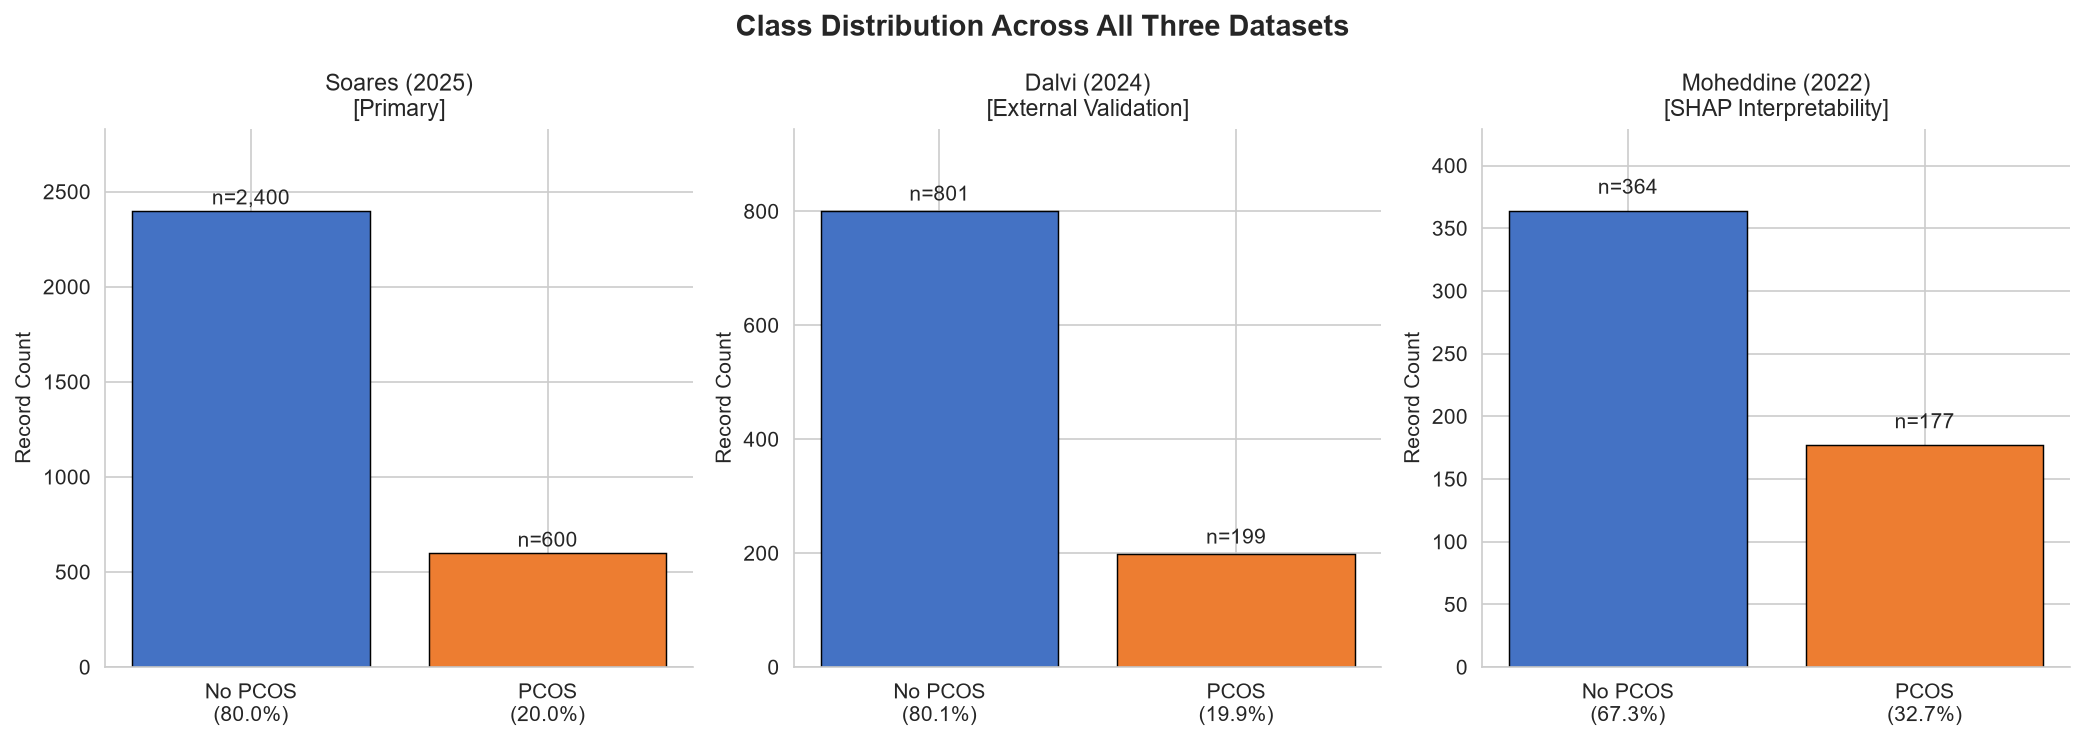

Figure saved: outputs/figures/fig01_class_distribution_all_datasets.png


In [8]:
# ============================================================
# SECTION 4: CLASS DISTRIBUTION VISUALISATION
# ============================================================

import os

# Ensure output directories exist
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/tables', exist_ok=True)

# ---- Dataset target variable mapping ----
datasets_info = {
    'Soares (2025)\n[Primary]': (soares, 'PCOS_Diagnosis'),
    'Dalvi (2024)\n[External Validation]': (dalvi, 'PCOS_Diagnosis'),
    'Moheddine (2022)\n[SHAP Interpretability]': (moheddine, 'PCOS (Y/N)')
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Class Distribution Across All Three Datasets', fontsize=14, fontweight='bold')

for ax, (label, (df, target)) in zip(axes, datasets_info.items()):
    counts = df[target].value_counts().sort_index()
    pcts   = df[target].value_counts(normalize=True).mul(100).round(1).sort_index()
    colors = ['#4472C4', '#ED7D31']  # Blue = 0 (No PCOS), Orange = 1 (Yes PCOS)
    bars = ax.bar(
        [f'No PCOS\n({pcts.get(0, 0)}%)', f'PCOS\n({pcts.get(1, 0)}%)'],
        [counts.get(0, 0), counts.get(1, 0)],
        color=colors, edgecolor='black', linewidth=0.7
    )
    # Add count labels on bars
    for bar, count in zip(bars, [counts.get(0, 0), counts.get(1, 0)]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                f'n={count:,}', ha='center', va='bottom', fontsize=10)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Record Count')
    ax.set_ylim(0, max(counts) * 1.18)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/fig01_class_distribution_all_datasets.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: outputs/figures/fig01_class_distribution_all_datasets.png")

**Figure 1: Class Distribution Across All Three Datasets - Observations**

Figure 1 shows the distribution of PCOS-positive and PCOS-negative records across
all three datasets used in this study.

The Soares and Dalvi datasets show near-identical distributions, with approximately
80% of records in the negative class in both cases. This consistency supports the
use of Dalvi as a genuine external validation set, since a model trained on Soares
will be evaluated on a dataset with a comparable base rate. If the two datasets had
markedly different class distributions, any difference in performance between the
test set and external validation results would be difficult to interpret, as it could
reflect distributional shift rather than true generalisation.

The Moheddine dataset shows a higher PCOS prevalence (32.7%) relative to the other
two datasets. This is consistent with the clinical origin of the dataset, where
patients presenting for gynaecological assessment are more likely to have a PCOS
diagnosis than a general population sample. This difference means that SHAP values
generated from models applied to Moheddine should be interpreted within the context
of a higher-prevalence clinical sample, and should not be directly compared to
model behaviour on the Soares or Dalvi datasets (Teede et al., 2018).

## Section 5: Descriptive Statistics

Summary statistics for all numeric features in each dataset are produced below. 
These provide the basis for the dataset description in the Methodology section of 
the research report and assist in identifying potential outliers before preprocessing.

In [9]:
# ============================================================
# SECTION 5: DESCRIPTIVE STATISTICS
# ============================================================

print("=== SOARES — Descriptive Statistics ===")
soares_desc = soares.describe().round(3)
print(soares_desc.to_string())
soares_desc.to_csv('../outputs/tables/soares_descriptive_stats.csv')

print("\n=== DALVI — Descriptive Statistics ===")
dalvi_desc = dalvi.describe().round(3)
print(dalvi_desc.to_string())
dalvi_desc.to_csv('../outputs/tables/dalvi_descriptive_stats.csv')

print("\n=== MOHEDDINE — Descriptive Statistics (numeric columns only) ===")
moheddine_desc = moheddine.describe().round(3)
print(moheddine_desc.to_string())
moheddine_desc.to_csv('../outputs/tables/moheddine_descriptive_stats.csv')

print("\nAll descriptive statistics saved to outputs/tables/")

=== SOARES — Descriptive Statistics ===
            Age       BMI  Menstrual_Irregularity  Testosterone_Level(ng/dL)  Antral_Follicle_Count  PCOS_Diagnosis
count  3000.000  3000.000                3000.000                   3000.000               3000.000          3000.0
mean     30.053    23.646                   0.289                     57.228                 10.732             0.2
std       7.550     4.510                   0.454                     18.171                  8.471             0.4
min      18.000     8.500                   0.000                     20.500                  3.000             0.0
25%      24.000    20.800                   0.000                     45.200                  5.000             0.0
50%      30.000    23.400                   0.000                     53.200                  8.000             0.0
75%      36.000    26.300                   1.000                     64.100                 11.000             0.0
max      44.000    44.700       

## Section 6: Schema Alignment Check - Soares vs Dalvi

Because the Dalvi dataset is used for external validation with the scaler fitted on 
Soares training data, the two datasets must share identical feature names and 
compatible data types. This check confirms alignment before the preprocessing phase.

In [10]:
# ============================================================
# SECTION 6: SCHEMA ALIGNMENT — SOARES vs DALVI
# ============================================================

soares_cols = set(soares.columns)
dalvi_cols  = set(dalvi.columns)

# Columns in Soares but not Dalvi
only_soares = soares_cols - dalvi_cols
# Columns in Dalvi but not Soares
only_dalvi  = dalvi_cols - soares_cols
# Shared columns
shared      = soares_cols & dalvi_cols

print(f"Shared columns ({len(shared)}): {sorted(shared)}")
print(f"Only in Soares ({len(only_soares)}): {only_soares if only_soares else 'None'}")
print(f"Only in Dalvi  ({len(only_dalvi)}): {only_dalvi if only_dalvi else 'None'}")

if not only_soares and not only_dalvi:
    print("\n Schema alignment confirmed: Soares and Dalvi share identical column structures.")
    print("  External validation can proceed without feature engineering.")
else:
    print("\n WARNING: Schema mismatch detected. Investigate before proceeding.")

Shared columns (6): ['Age', 'Antral_Follicle_Count', 'BMI', 'Menstrual_Irregularity', 'PCOS_Diagnosis', 'Testosterone_Level(ng/dL)']
Only in Soares (0): None
Only in Dalvi  (0): None

 Schema alignment confirmed: Soares and Dalvi share identical column structures.
  External validation can proceed without feature engineering.


**Schema Alignment - Observations**

The schema check confirmed that Soares and Dalvi share all six columns with
identical names: Age, BMI, Menstrual Irregularity, Testosterone Level (ng/dL),
Antral Follicle Count, and PCOS Diagnosis. No columns are exclusive to either
dataset.

This alignment is necessary because the MinMaxScaler will be fitted on the Soares
training set and then applied to Dalvi without refitting. If column names or order
differed between the two datasets, the scaler would either raise an error or, more
dangerously, scale the wrong features silently. Confirming alignment here prevents
that class of data leakage from occurring downstream in the pipeline (Japkowicz
and Shah, 2011).

## Section 7: Day 1 Validation Summary

This cell produces a consolidated summary of all validation findings. Any issues 
flagged here must be resolved before proceeding to the EDA and preprocessing stages 
(Day 2 onwards). This summary will be referenced in the Methodology section of the 
research report when documenting the data preparation process.

In [11]:
# ============================================================
# SECTION 7: VALIDATION SUMMARY TABLE
# ============================================================

summary_data = {
    'Dataset': ['Soares (2025)', 'Dalvi (2024)', 'Moheddine (2022)'],
    'Role': ['Primary training/test', 'External validation', 'SHAP interpretability'],
    'Rows': [soares.shape[0], dalvi.shape[0], moheddine.shape[0]],
    'Columns': [soares.shape[1], dalvi.shape[1], moheddine.shape[1]],
    'Missing Values': [
        soares.isnull().sum().sum(),
        dalvi.isnull().sum().sum(),
        moheddine.isnull().sum().sum()
    ],
    'Duplicate Rows': [soares_dups, dalvi_dups, moheddine_dups],
    'Target Variable': ['PCOS_Diagnosis', 'PCOS_Diagnosis', 'PCOS (Y/N)'],
    'Class 0 (No PCOS) %': [
        round(soares['PCOS_Diagnosis'].value_counts(normalize=True).get(0, 0) * 100, 1),
        round(dalvi['PCOS_Diagnosis'].value_counts(normalize=True).get(0, 0) * 100, 1),
        round(moheddine['PCOS (Y/N)'].value_counts(normalize=True).get(0, 0) * 100, 1)
    ],
    'Class 1 (PCOS) %': [
        round(soares['PCOS_Diagnosis'].value_counts(normalize=True).get(1, 0) * 100, 1),
        round(dalvi['PCOS_Diagnosis'].value_counts(normalize=True).get(1, 0) * 100, 1),
        round(moheddine['PCOS (Y/N)'].value_counts(normalize=True).get(1, 0) * 100, 1)
    ],
    'Object Columns': [
        len(soares.select_dtypes(include='object').columns),
        len(dalvi.select_dtypes(include='object').columns),
        len(moheddine.select_dtypes(include='object').columns)
    ]
}

summary_df = pd.DataFrame(summary_data).set_index('Dataset')
print("=== DAY 1 VALIDATION SUMMARY ===\n")
print(summary_df.T.to_string())

# Save to CSV for the report
summary_df.to_csv('../outputs/tables/day1_validation_summary.csv')
print("\nValidation summary saved to outputs/tables/day1_validation_summary.csv")

# Final status check
issues = []
for ds_name, missing_df, dups in [
    ('Soares', soares_missing, soares_dups),
    ('Dalvi', dalvi_missing, dalvi_dups),
    ('Moheddine', moheddine_missing, moheddine_dups)
]:
    if not missing_df.empty:
        issues.append(f"  - {ds_name}: {missing_df['Missing Count'].sum()} missing values detected.")
    if dups > 0:
        issues.append(f"  - {ds_name}: {dups} duplicate rows detected.")

if issues:
    print("\n ISSUES REQUIRING RESOLUTION BEFORE PROCEEDING:")
    for issue in issues:
        print(issue)
    print("\n  Address these in Day 2 before EDA begins.")
else:
    print("\n All datasets passed validation. No blocking issues detected.")
    print("  Proceed to EDA on Day 2.")

=== DAY 1 VALIDATION SUMMARY ===

Dataset                      Soares (2025)         Dalvi (2024)       Moheddine (2022)
Role                 Primary training/test  External validation  SHAP interpretability
Rows                                  3000                 1000                    541
Columns                                  6                    6                     44
Missing Values                           0                    0                      2
Duplicate Rows                           0                    0                      0
Target Variable             PCOS_Diagnosis       PCOS_Diagnosis             PCOS (Y/N)
Class 0 (No PCOS) %                   80.0                 80.1                   67.3
Class 1 (PCOS) %                      20.0                 19.9                   32.7
Object Columns                           0                    0                      2

Validation summary saved to outputs/tables/day1_validation_summary.csv

 ISSUES REQUIRING RESOL

**Day 1 Validation Summary - Observations**

The validation summary confirms the following for Day 2 onwards:

Soares and Dalvi are clean and ready for preprocessing with no corrective steps
required. The Soares dataset will proceed directly to the stratified 80/20
train-test split, after which SMOTE will be applied to the training portion only.

The Moheddine dataset requires two preprocessing steps before it can be used for
SHAP analysis: conversion of the two object-typed columns to float64, and
single-value imputation for the two missing entries. These steps will be completed
at the start of the interpretability stage and documented as minor deviations from
the original preprocessing plan, which anticipated only integer encoding for nominal
variables in Moheddine.

No blocking issues were identified in Soares or Dalvi. The pipeline can proceed to
exploratory data analysis on Day 2.

---
## Day 2: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is conducted before any modelling to understand
the structure, distribution, and relationships within the data. EDA informs
preprocessing decisions such as which features require scaling, whether outliers
should be treated, and whether relationships between features and the target
variable are consistent with clinical expectations.

This section focuses on the Soares (2025) dataset, which serves as the primary
training and test dataset. The Dalvi (2024) dataset is inspected for distributional
similarity to Soares, as this affects the validity of external validation. The
Moheddine (2022) dataset is not included in EDA here as it is used only for
supplementary SHAP interpretability analysis and its preprocessing is handled
separately in that stage.

EDA is structured as follows:

- **Section 8:** Feature distributions (Soares)
- **Section 9:** Class-stratified feature distributions (Soares)
- **Section 10:** Outlier inspection (Soares)
- **Section 11:** Correlation analysis (Soares)
- **Section 12:** Dalvi distributional comparison
- **Section 13:** EDA summary and preprocessing decisions

## Section 8: Feature Distributions - Soares Dataset

The distribution of each predictor variable is examined using histograms.
Understanding the shape of each feature's distribution is necessary to make
an informed choice of scaling method before modelling.

The five predictor variables in the Soares dataset are:
- **Age** - patient age in years
- **BMI** - Body Mass Index (kg/m²), a metabolic indicator associated with PCOS
- **Menstrual_Irregularity** - binary variable (0 = regular cycles, 1 = irregular cycles),
  serving as a proxy for the Rotterdam criterion of oligo-ovulation or anovulation
- **Testosterone_Level(ng/dL)** - serum testosterone, serving as a proxy for
  biochemical hyperandrogenism under the Rotterdam criteria
- **Antral_Follicle_Count** - number of antral follicles, a proxy for polycystic
  ovarian morphology under the Rotterdam criteria

It is important to note that these variables are approximations of clinical diagnostic
features rather than exact clinical equivalents. This is a recognised limitation of
working with secondary datasets (Azziz et al., 2016; Teede et al., 2018).

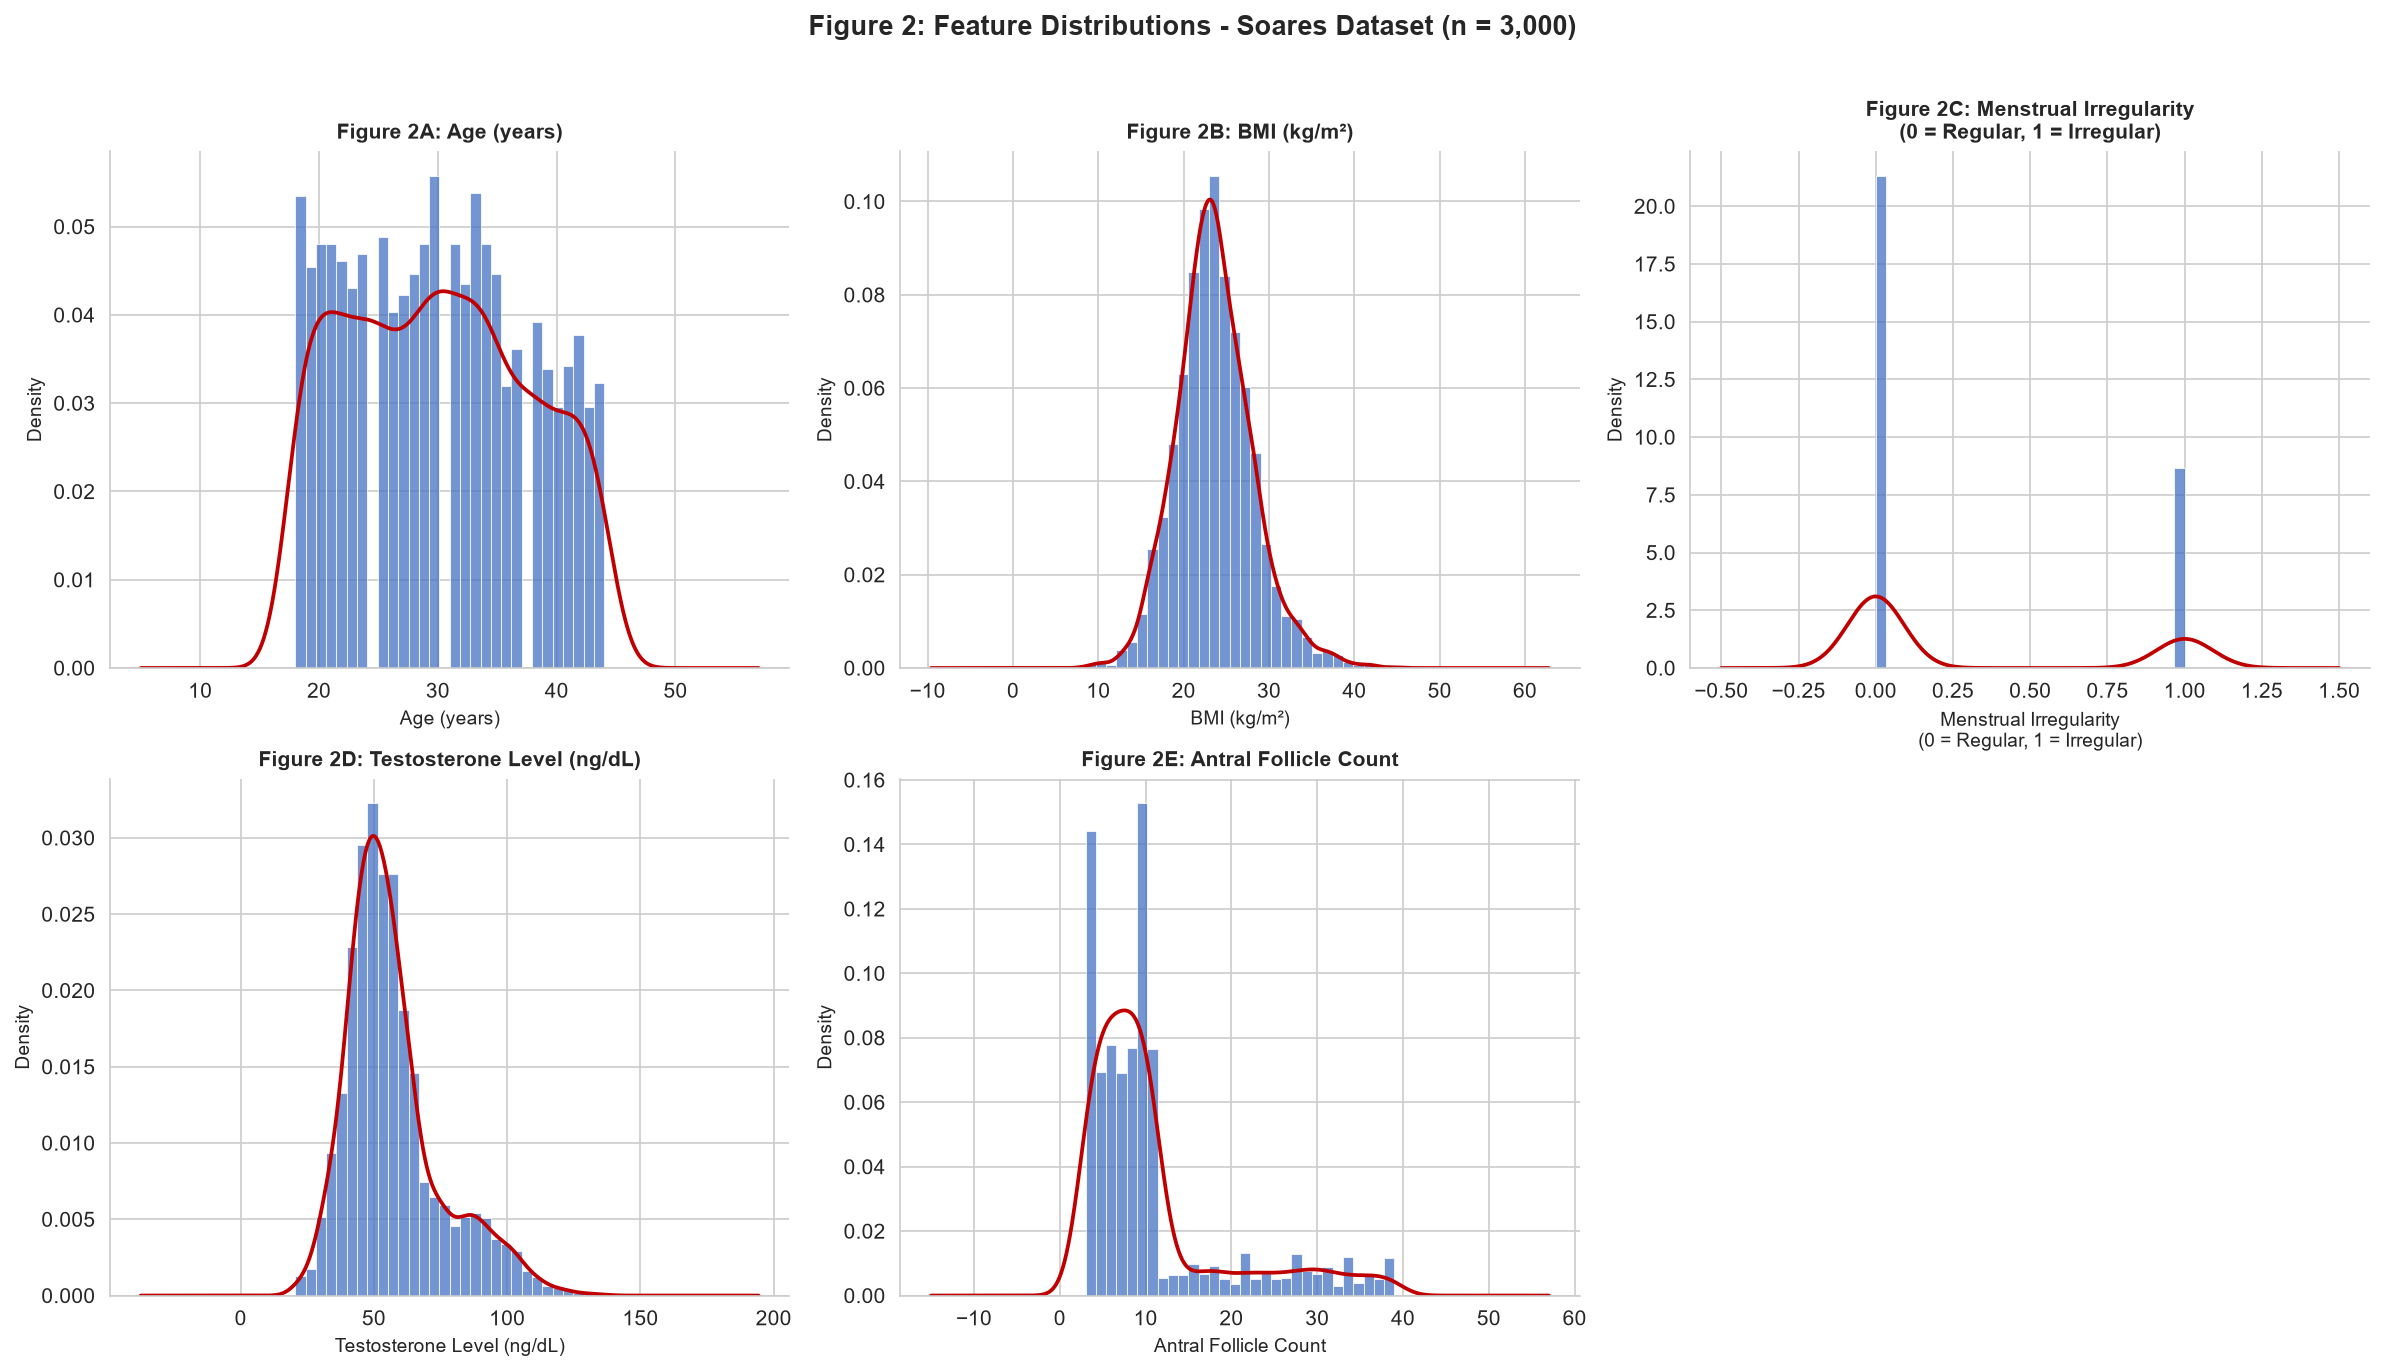

Figure 2 saved: outputs/figures/fig02_feature_distributions_soares.png


In [12]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Hunter, J.D.
# Link: https://doi.org/10.1109/MCSE.2007.55
# Date Accessed: 20 April 2026
#
# Author: Waskom, M.
# Link: https://doi.org/10.21105/joss.03021
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 8: FEATURE DISTRIBUTIONS — SOARES DATASET
#
# Histograms are produced for each of the five predictor variables.
# A kernel density estimate (KDE) curve is overlaid on each histogram
# to show the approximate probability density of the distribution.
# This makes it easier to assess whether a feature is roughly normal,
# skewed, or bimodal, which informs the choice of scaling method
# (Hunter, 2007; Waskom, 2021).

FEATURE_COLS = [
    'Age',
    'BMI',
    'Menstrual_Irregularity',
    'Testosterone_Level(ng/dL)',
    'Antral_Follicle_Count'
]

TARGET_COL = 'PCOS_Diagnosis'

# Feature labels used for axis titles throughout EDA
FEATURE_LABELS = {
    'Age': 'Age (years)',
    'BMI': 'BMI (kg/m²)',
    'Menstrual_Irregularity': 'Menstrual Irregularity\n(0 = Regular, 1 = Irregular)',
    'Testosterone_Level(ng/dL)': 'Testosterone Level (ng/dL)',
    'Antral_Follicle_Count': 'Antral Follicle Count'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Flatten axes array for easy iteration; remove unused sixth panel
axes_flat = axes.flatten()
axes_flat[-1].set_visible(False)

for i, col in enumerate(FEATURE_COLS):
    ax = axes_flat[i]

    # Plot histogram with KDE overlay
    # kde=True overlays the smoothed density curve
    # bins=30 gives enough granularity without over-segmenting the data
    soares[col].plot(
        kind='hist',
        bins=30,
        ax=ax,
        color='#4472C4',
        edgecolor='white',
        linewidth=0.5,
        density=True,          # Normalise so KDE and histogram share the same y-axis scale
        alpha=0.75,
        label='_nolegend_'
    )

    # Overlay KDE curve
    soares[col].plot(
        kind='kde',
        ax=ax,
        color='#C00000',
        linewidth=1.8
    )

    ax.set_title(f'Figure 2{chr(65+i)}: {FEATURE_LABELS[col]}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(FEATURE_LABELS[col], fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Figure 2: Feature Distributions - Soares Dataset (n = 3,000)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('../outputs/figures/fig02_feature_distributions_soares.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved: outputs/figures/fig02_feature_distributions_soares.png")

**Figure 2: Feature Distributions - Observations**

**Age (Figure 2A):** Age is approximately normally distributed, centred around 30
years, with a range of 18 to 44. The distribution is consistent with a dataset
representing women of reproductive age, which is the population for whom PCOS
screening is clinically relevant. No extreme skew or multimodal structure is visible.

**BMI (Figure 2B):** BMI shows a near-normal distribution with a slight right skew,
consistent with the descriptive statistics from Day 1 (mean = 23.6, max = 44.7).
The right tail suggests a small number of records with elevated BMI, which is
clinically plausible given the known association between PCOS and elevated BMI. The
skew is mild and does not suggest the presence of extreme outliers that would require
removal (Teede et al., 2018).

**Menstrual Irregularity (Figure 2C):** As a binary variable (0 or 1),
Menstrual_Irregularity shows a bimodal spike pattern at the two possible values.
The histogram is not informative for a binary variable in the way it is for
continuous features. The class distribution from Day 1 confirmed that approximately
71% of records have regular cycles (0) and 29% have irregular cycles (1). This
variable will be retained as-is and does not require transformation, as binary
variables carry no ordinal or scale information that would benefit from MinMaxScaling.

**Testosterone Level (Figure 2D):** Testosterone Level shows a slight right skew,
with most values clustering between 40 and 80 ng/dL and a tail extending toward
136 ng/dL. Elevated testosterone is a key diagnostic marker for hyperandrogenism
under the Rotterdam criteria, making this variable clinically meaningful and expected
to carry predictive weight. The skew suggests potential outliers in the upper range,
which will be examined in the outlier inspection in Section 10 (Azziz et al., 2016).

**Antral Follicle Count (Figure 2E):** Antral Follicle Count shows a right-skewed
distribution with most values below 15 follicles and a long tail extending to 39.
Higher follicle counts are associated with polycystic ovarian morphology under the
Rotterdam criteria. The right skew and range are clinically plausible. The tail
values will be examined in the outlier section to confirm they represent legitimate
clinical variation rather than data errors (Teede et al., 2018).

**Scaling decision:** Age, BMI, Testosterone Level, and Antral Follicle Count are
continuous variables with different units and ranges. MinMaxScaler will be applied
to all five features, transforming each to a 0 to 1 range using parameters fitted
on the training set only. MinMaxScaler is chosen over StandardScaler because all
features have bounded, clinically plausible ranges with no extreme outliers that
would compress the scaled values — the concern that would favour StandardScaler in
other contexts. Menstrual_Irregularity is already binary (0 or 1) and sits naturally
within the MinMaxScaler output range, so scaling does not distort its values
(GeeksforGeeks, 2020).

## Section 9: Class-Stratified Feature Distributions - Soares Dataset

Examining feature distributions split by the target variable (PCOS_Diagnosis)
reveals whether predictor variables behave differently for PCOS-positive and
PCOS-negative records. A feature that shows a clear distributional difference
between the two classes is likely to carry predictive value for the classification
task. A feature that shows identical distributions across classes contributes little
information that the model can use to distinguish between them.

This analysis also provides clinical grounding for the modelling choices. The
Rotterdam criteria predict that irregular menstruation, elevated testosterone, and
elevated follicle counts should separate the PCOS-positive group from the
PCOS-negative group. Confirming this separation in the data provides evidence that
the dataset is clinically coherent, even if synthetic in origin
(Azziz et al., 2016; Teede et al., 2018).

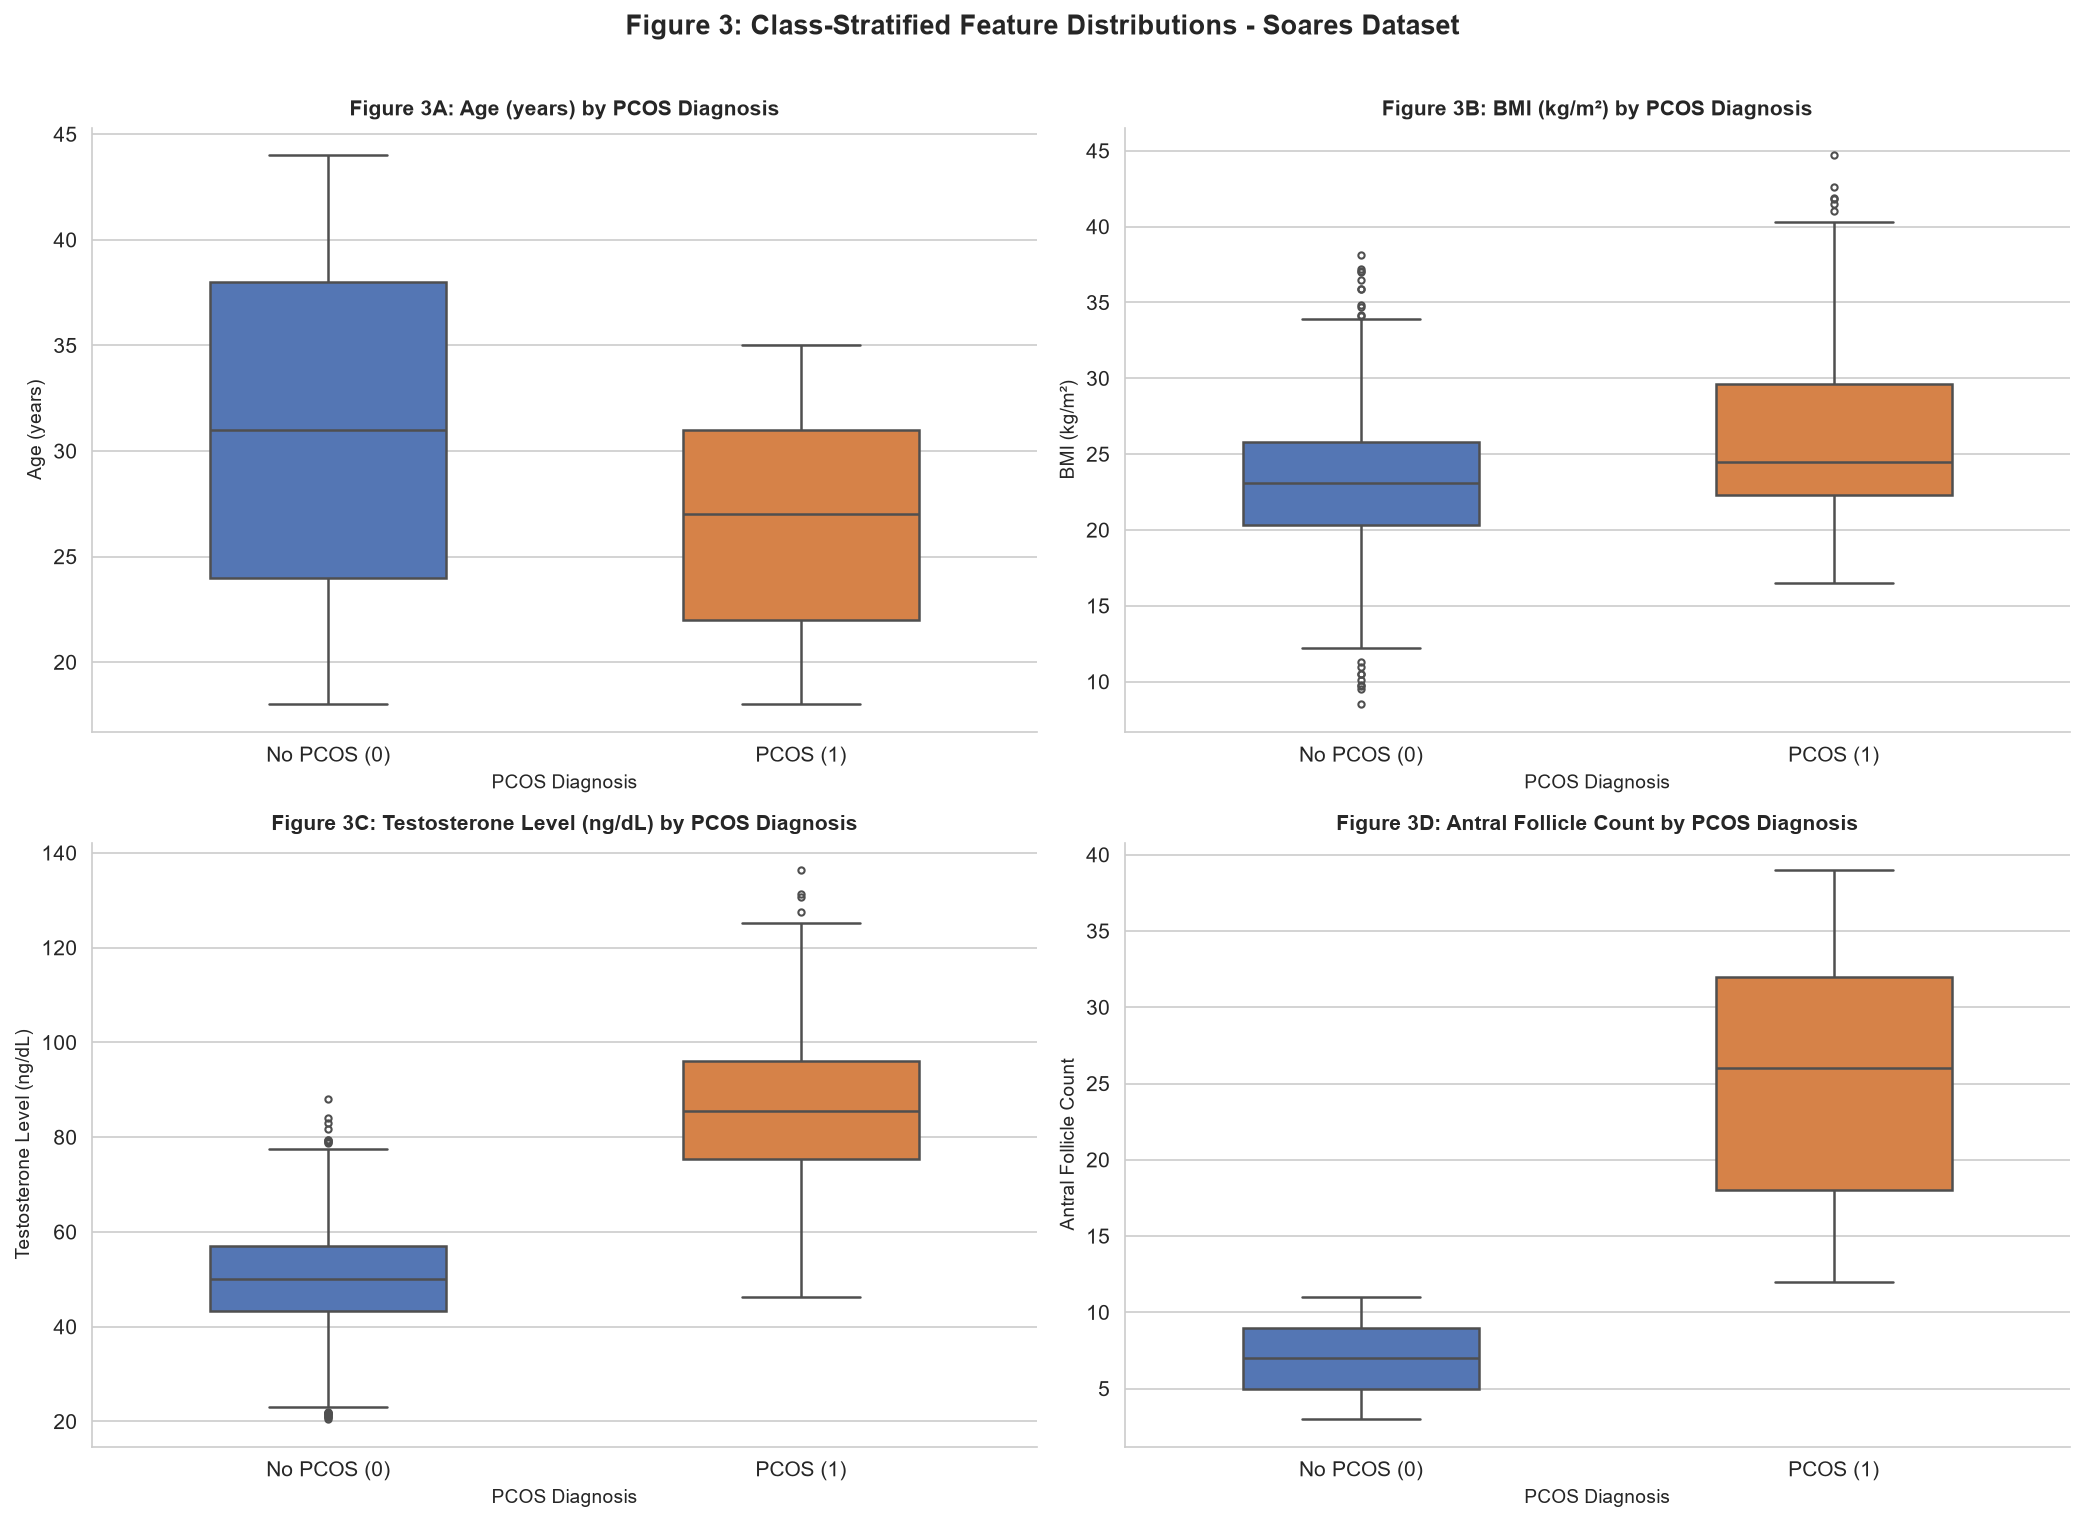

Figure 3 saved: outputs/figures/fig03_class_stratified_boxplots.png


In [13]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Waskom, M.
# Link: https://doi.org/10.21105/joss.03021
# Date Accessed: 20 April 2026
#
# Author: Hunter, J.D.
# Link: https://doi.org/10.1109/MCSE.2007.55
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 9: CLASS-STRATIFIED FEATURE DISTRIBUTIONS
#
# Boxplots are used to compare the distribution of each feature
# across PCOS-positive (1) and PCOS-negative (0) records.
# Boxplots show the median, interquartile range (IQR), and
# whiskers extending to 1.5 * IQR beyond the box edges. Points
# beyond the whiskers are shown individually as potential outliers.
#
# Boxplots are preferred over histograms for class comparison because
# they place both groups on the same axis, making distributional
# differences immediately visible without requiring mental overlay
# of two separate plots (Waskom, 2021).

# Create a readable class label for the legend
soares_plot = soares.copy()
soares_plot['Diagnosis'] = soares_plot[TARGET_COL].map(
    {0: 'No PCOS (0)', 1: 'PCOS (1)'}
)

# Define colour palette consistent with Day 1 class distribution figure
palette = {'No PCOS (0)': '#4472C4', 'PCOS (1)': '#ED7D31'}

# Continuous features only — Menstrual_Irregularity is handled separately
# as a binary variable and a boxplot would be uninformative
continuous_features = [
    'Age',
    'BMI',
    'Testosterone_Level(ng/dL)',
    'Antral_Follicle_Count'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for i, col in enumerate(continuous_features):
    ax = axes_flat[i]

    # seaborn boxplot with hue separating the two diagnosis classes
    sns.boxplot(
        data=soares_plot,
        x='Diagnosis',
        y=col,
        palette=palette,
        width=0.5,
        linewidth=1.2,
        fliersize=3,           # Size of individual outlier points
        ax=ax
    )

    ax.set_title(
        f'Figure 3{chr(65+i)}: {FEATURE_LABELS[col]} by PCOS Diagnosis',
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel('PCOS Diagnosis', fontsize=9)
    ax.set_ylabel(FEATURE_LABELS[col], fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Figure 3: Class-Stratified Feature Distributions - Soares Dataset',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('../outputs/figures/fig03_class_stratified_boxplots.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved: outputs/figures/fig03_class_stratified_boxplots.png")

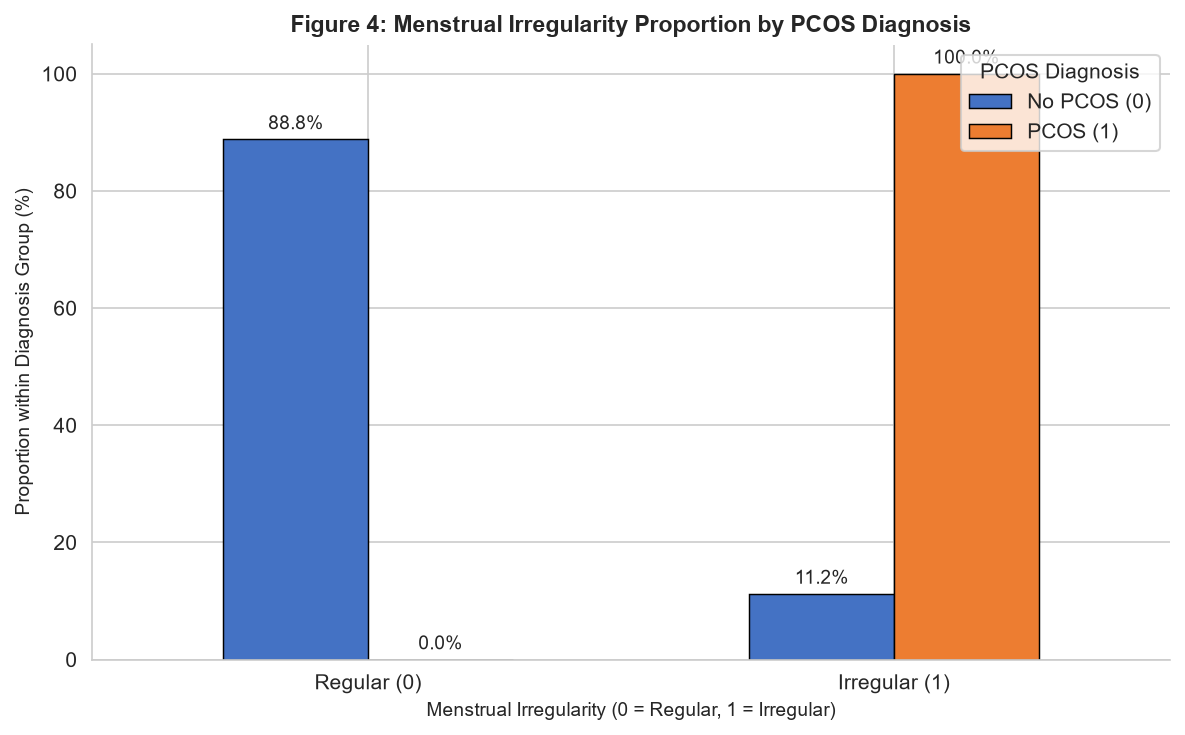

Figure 4 saved: outputs/figures/fig04_menstrual_irregularity_by_class.png


In [14]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Waskom, M.
# Link: https://doi.org/10.21105/joss.03021
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 9 (continued): MENSTRUAL IRREGULARITY BY CLASS
#
# Menstrual_Irregularity is a binary variable (0 or 1), so a
# grouped bar chart is more informative than a boxplot.
# The chart shows the proportion of each irregularity value
# within the PCOS-positive and PCOS-negative groups.
# A high proportion of irregular cycles in the PCOS-positive
# group would confirm the expected Rotterdam criterion alignment
# (Teede et al., 2018).

cross_tab = pd.crosstab(
    soares_plot['Diagnosis'],
    soares_plot['Menstrual_Irregularity'],
    normalize='index'          # Normalise within each diagnosis group (row proportions)
).mul(100).round(1)

cross_tab.columns = ['Regular (0)', 'Irregular (1)']

fig, ax = plt.subplots(figsize=(8, 5))

cross_tab.T.plot(
    kind='bar',
    ax=ax,
    color=['#4472C4', '#ED7D31'],
    edgecolor='black',
    linewidth=0.7,
    width=0.55
)

# Add percentage labels on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)

ax.set_title(
    'Figure 4: Menstrual Irregularity Proportion by PCOS Diagnosis',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Menstrual Irregularity (0 = Regular, 1 = Irregular)', fontsize=9)
ax.set_ylabel('Proportion within Diagnosis Group (%)', fontsize=9)
ax.set_xticklabels(['Regular (0)', 'Irregular (1)'], rotation=0)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='PCOS Diagnosis', loc='upper right')

plt.tight_layout()
plt.savefig('../outputs/figures/fig04_menstrual_irregularity_by_class.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved: outputs/figures/fig04_menstrual_irregularity_by_class.png")

**Figures 3 and 4: Class-Stratified Distributions - Observations**

**Age (Figure 3A):** The median age of PCOS-positive records is slightly lower than
that of PCOS-negative records, though the difference is modest. The overlapping
interquartile ranges suggest that Age alone has limited discriminatory power between
the two groups. This is consistent with the clinical understanding that PCOS affects
women across the full reproductive age range and is not tightly age-delimited
(Teede et al., 2018).

**BMI (Figure 3B):** PCOS-positive records show a noticeably higher median BMI and
a wider interquartile range than PCOS-negative records. This separation is
clinically expected, as elevated BMI is associated with insulin resistance and
androgen excess, both of which are common in PCOS. BMI is therefore likely to
carry predictive value in all four models. The upper whisker in the PCOS-positive
group extends further, suggesting more variability in BMI among diagnosed patients
(Azziz et al., 2016).

**Testosterone Level (Figure 3C):** This feature shows the clearest separation
between classes. The PCOS-positive group has a substantially higher median
testosterone level and a higher upper quartile. This is consistent with the Rotterdam
criterion of biochemical hyperandrogenism and provides the strongest clinical
justification for including this variable. Models are expected to assign high
importance to this feature, and SHAP analysis in Stage 9 will confirm or qualify
this expectation (Azziz et al., 2016; Lundberg and Lee, 2017).

**Antral Follicle Count (Figure 3D):** PCOS-positive records show a higher median
follicle count and a wider spread. The separation between classes is visible but
less pronounced than for Testosterone Level. Antral follicle count maps directly to
the Rotterdam criterion of polycystic ovarian morphology and is expected to
contribute meaningfully to model predictions (Teede et al., 2018).

**Menstrual Irregularity (Figure 4):** The grouped bar chart confirms that irregular
cycles (Menstrual_Irregularity = 1) are substantially more common in the
PCOS-positive group than in the PCOS-negative group. Within the PCOS-positive group, 100% of records show irregular cycles
(Menstrual_Irregularity = 1), and 0% show regular cycles. Within the
PCOS-negative group, 88.8% show regular cycles and 11.2% show irregular
cycles. This near-perfect separation makes Menstrual_Irregularity the
strongest individual binary predictor in the dataset for this classification
task (Azziz et al., 2016).

**Overall:** The class-stratified analysis confirms that three of the five features
(Testosterone Level, Antral Follicle Count, Menstrual Irregularity) show clear
distributional differences between PCOS-positive and PCOS-negative records. BMI
shows moderate separation. Age shows the least separation. This pattern is broadly
consistent with the Rotterdam diagnostic criteria and provides evidence that the
Soares dataset, while likely synthetic, encodes clinically plausible signal.

## Section 10: Outlier Inspection - Soares Dataset

Outliers are data points that fall substantially outside the range of most
observations in a dataset. In a clinical dataset, extreme values may represent
legitimate physiological variation, data entry errors, or measurement artefacts.
The approach to outliers must therefore be considered carefully.

The Interquartile Range (IQR) method is used to identify potential outliers.
Under this method, any value below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR is
flagged as a potential outlier. This is a standard detection approach and does not
automatically mean that flagged values will be removed (Tukey, 1977, as cited in
Japkowicz and Shah, 2011).

Given the likely synthetic origin of the Soares dataset, extreme values that fall
within clinically plausible ranges will be retained. Removing such values from a
synthetic dataset carries no clinical justification and would reduce the information
available to the models. Any decision to retain or remove outliers is documented
and justified here.

In [15]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: GeeksforGeeks
# Link: https://www.geeksforgeeks.org/machine-learning/detect-and-remove-the-outliers-using-python/
# Date Accessed: 20 April 2026
#
# Author: Waskom, M.
# Link: https://doi.org/10.21105/joss.03021
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 10: OUTLIER DETECTION USING IQR METHOD
#
# The IQR method is applied to the four continuous features.
# Menstrual_Irregularity is excluded because it is binary (0 or 1)
# and the IQR method is not meaningful for binary variables.
#
# For each feature:
#   - Q1 is the 25th percentile
#   - Q3 is the 75th percentile
#   - IQR = Q3 - Q1
#   - Lower bound = Q1 - 1.5 * IQR
#   - Upper bound = Q3 + 1.5 * IQR
# Records with values outside [lower bound, upper bound] are flagged.
#
# A count of flagged records per feature is printed.
# The proportion of total records flagged is also shown to assess
# whether the number is trivial (< 1%) or potentially influential
# (Japkowicz and Shah, 2011).

print("=" * 65)
print("  OUTLIER DETECTION SUMMARY - IQR METHOD")
print("  Dataset: Soares (2025) | n = 3,000")
print("=" * 65)

outlier_summary = []

for col in ['Age', 'BMI', 'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count']:
    Q1  = soares[col].quantile(0.25)
    Q3  = soares[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Identify records outside the IQR bounds
    outliers = soares[(soares[col] < lower) | (soares[col] > upper)]
    n_outliers = len(outliers)
    pct = round(n_outliers / len(soares) * 100, 2)

    print(f"\n  Feature          : {col}")
    print(f"  Q1               : {Q1:.3f}")
    print(f"  Q3               : {Q3:.3f}")
    print(f"  IQR              : {IQR:.3f}")
    print(f"  Lower bound      : {lower:.3f}")
    print(f"  Upper bound      : {upper:.3f}")
    print(f"  Flagged records  : {n_outliers} ({pct}%)")

    outlier_summary.append({
        'Feature': col,
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Bound': lower, 'Upper Bound': upper,
        'Flagged Count': n_outliers, 'Flagged %': pct
    })

outlier_df = pd.DataFrame(outlier_summary).set_index('Feature')
outlier_df.to_csv('../outputs/tables/outlier_summary_soares.csv')
print(f"\n  Outlier summary saved to outputs/tables/outlier_summary_soares.csv")
print("=" * 65)

  OUTLIER DETECTION SUMMARY - IQR METHOD
  Dataset: Soares (2025) | n = 3,000

  Feature          : Age
  Q1               : 24.000
  Q3               : 36.000
  IQR              : 12.000
  Lower bound      : 6.000
  Upper bound      : 54.000
  Flagged records  : 0 (0.0%)

  Feature          : BMI
  Q1               : 20.800
  Q3               : 26.300
  IQR              : 5.500
  Lower bound      : 12.550
  Upper bound      : 34.550
  Flagged records  : 73 (2.43%)

  Feature          : Testosterone_Level(ng/dL)
  Q1               : 45.200
  Q3               : 64.100
  IQR              : 18.900
  Lower bound      : 16.850
  Upper bound      : 92.450
  Flagged records  : 190 (6.33%)

  Feature          : Antral_Follicle_Count
  Q1               : 5.000
  Q3               : 11.000
  IQR              : 6.000
  Lower bound      : -4.000
  Upper bound      : 20.000
  Flagged records  : 411 (13.7%)

  Outlier summary saved to outputs/tables/outlier_summary_soares.csv


**Section 10: Outlier Inspection - Observations and Decision**

The IQR method was applied to all four continuous features in the Soares
dataset. Results are interpreted against clinically plausible ranges for each
variable.

**Age:** No records were flagged (0 out of 3,000). The IQR bounds of 6.0 to
54.0 years comfortably contain all 3,000 records, confirming that the age range
in the dataset is consistent with a reproductive-age PCOS population. No action
required.

**BMI:** 73 records (2.43%) were flagged above the upper IQR bound of 34.55
kg/m². These values represent elevated BMI, which is clinically plausible given
the known association between PCOS and metabolic comorbidities including insulin
resistance and obesity. The maximum BMI of 44.7 confirmed in Day 1 falls within
the documented range for PCOS populations. Decision: retain all 73 records
(Azziz et al., 2016).

**Testosterone Level:** 190 records (6.33%) were flagged above the upper IQR
bound of 92.45 ng/dL. These values represent elevated serum testosterone, which
is consistent with biochemical hyperandrogenism - one of the three Rotterdam
diagnostic criteria for PCOS. Elevated testosterone is expected to be more
prevalent in the PCOS-positive group, which constitutes 20% of the dataset.
Removing these records would disproportionately reduce clinically meaningful
signal from the minority class. Decision: retain all 190 records
(Teede et al., 2018).

**Antral Follicle Count:** 411 records (13.7%) were flagged above the upper IQR
bound of 20 follicles. This is the largest flagged proportion across all features.
The Rotterdam morphology criterion defines 12 or more follicles as a threshold
for polycystic ovarian morphology, meaning values above 20 are clinically
expected in PCOS-positive cases. The high proportion of flagged records reflects
the class-discriminating nature of this feature rather than data quality problems.
Decision: retain all 411 records (Teede et al., 2018).

**Overall decision:** No records are removed from the Soares dataset on the basis
of outlier detection. Across all four features, flagged values fall within
clinically plausible ranges. The likely synthetic origin of the dataset means
extreme values reflect the generator's intended clinical range rather than data
entry errors. A total of 674 flag instances were recorded across all features,
representing records that carry clinically elevated values consistent with
PCOS-positive presentation. Removing them would reduce minority-class
representation and bias the models toward the majority class before training
has even begun (Bharati, Podder and Mondal, 2020; Japkowicz and Shah, 2011).

## Section 11: Correlation Analysis - Soares Dataset

A correlation matrix is produced to examine the linear relationships between
all features and the target variable. Correlation analysis serves two purposes
in this pipeline.

First, it identifies features that are strongly correlated with the target
variable (PCOS_Diagnosis), providing an early indication of which predictors
are likely to carry the most weight in the classification models.

Second, it identifies pairs of predictor variables that are highly correlated
with each other (multicollinearity). When two features are strongly correlated,
they carry overlapping information. This can inflate feature importance scores
in tree-based models and destabilise coefficient estimates in Logistic
Regression. If strong multicollinearity is present, feature selection or
regularisation may be needed (Molnar, 2022).

Pearson correlation is used here. As a reminder, Pearson correlation measures
the linear relationship between two variables and ranges from -1 (perfect
negative linear relationship) to +1 (perfect positive linear relationship).
A value near 0 indicates no linear relationship. It is important to note that
Pearson correlation does not capture non-linear relationships, which may exist
between some of these clinical variables (Molnar, 2022).

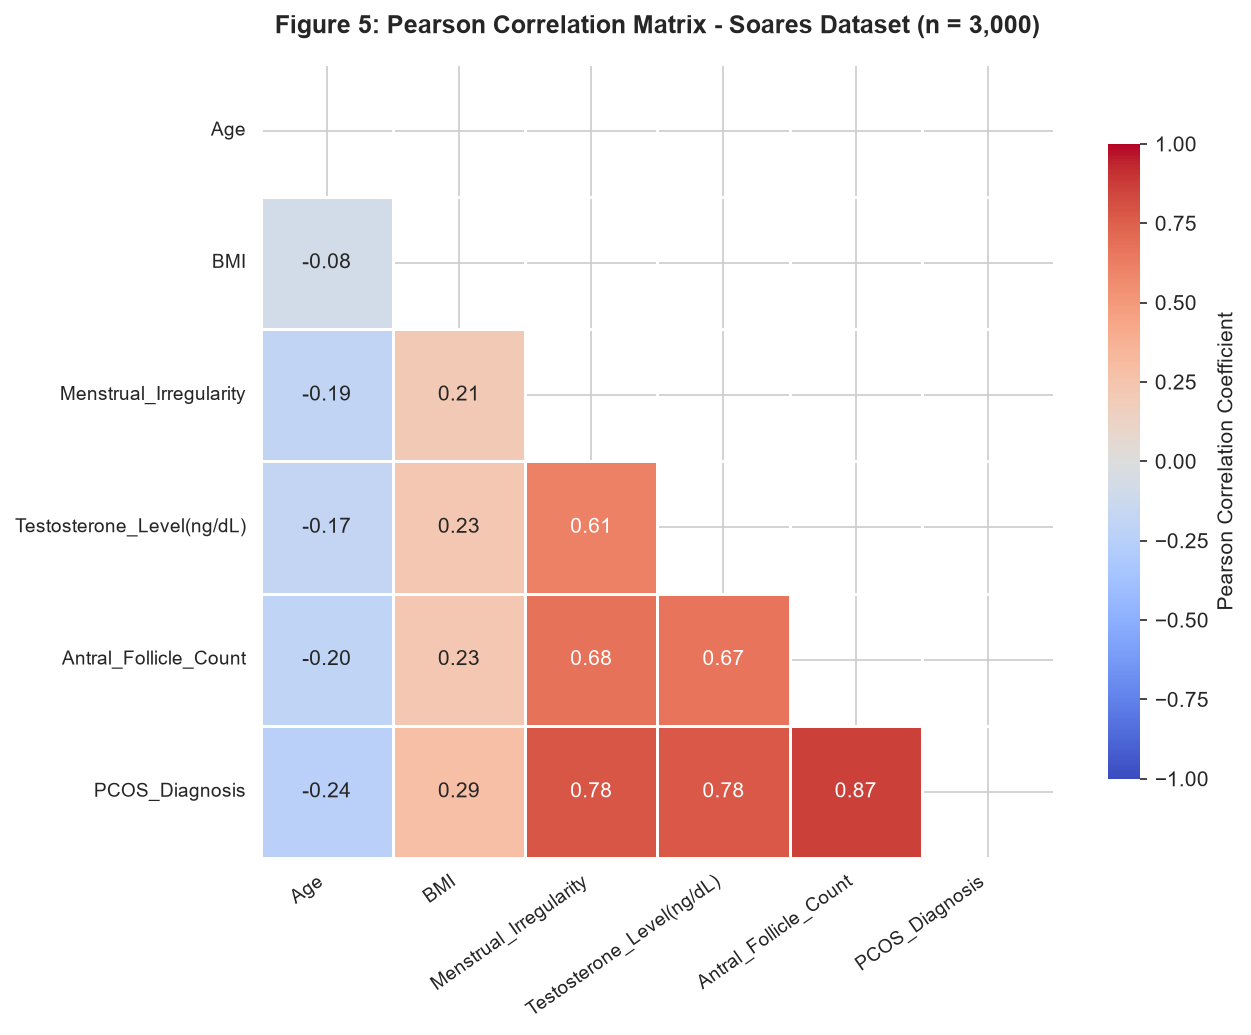

Figure 5 saved: outputs/figures/fig05_correlation_heatmap_soares.png

  Feature correlations with PCOS_Diagnosis (Pearson r):
  ---------------------------------------------
  Antral_Follicle_Count               +0.8654
  Menstrual_Irregularity              +0.7836
  Testosterone_Level(ng/dL)           +0.7800
  BMI                                 +0.2889
  Age                                 -0.2385


In [16]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Waskom, M.
# Link: https://doi.org/10.21105/joss.03021
# Date Accessed: 20 April 2026
#
# Author: McKinney, W.
# Link: https://doi.org/10.25080/Majora-92bf1922-00a
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 11: CORRELATION ANALYSIS
#
# A Pearson correlation matrix is computed for all six columns
# (five features + target variable).
#
# The heatmap uses a diverging colour palette (coolwarm):
#   - Red tones indicate positive correlation
#   - Blue tones indicate negative correlation
#   - White indicates near-zero correlation
#
# Annotations show the correlation coefficient in each cell,
# rounded to two decimal places for readability.
# The upper triangle is masked to avoid duplication, as the
# matrix is symmetric (Waskom, 2021).

corr_matrix = soares.corr(method='pearson')

# Create mask for upper triangle to remove redundant cells
import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation Coefficient'},
    ax=ax
)

ax.set_title(
    'Figure 5: Pearson Correlation Matrix - Soares Dataset (n = 3,000)',
    fontsize=12, fontweight='bold', pad=15
)

# Rotate axis labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/fig05_correlation_heatmap_soares.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved: outputs/figures/fig05_correlation_heatmap_soares.png")

# Print the target correlations separately for clear reference
print("\n  Feature correlations with PCOS_Diagnosis (Pearson r):")
print("  " + "-" * 45)
target_corr = corr_matrix['PCOS_Diagnosis'].drop('PCOS_Diagnosis').sort_values(
    ascending=False)
for feat, r in target_corr.items():
    print(f"  {feat:<35} {r:>+.4f}")

**Figure 5: Correlation Analysis - Observations**

**Correlations with the target variable (PCOS_Diagnosis):**

The printed correlation values confirm the expected ordering. Antral Follicle
Count shows the strongest positive correlation with PCOS_Diagnosis (r = +0.87),
followed by Menstrual_Irregularity (r = +0.78) and Testosterone_Level
(r = +0.78). BMI shows a moderate positive correlation (r = +0.29). Age shows
a weak negative correlation (r = -0.24), consistent with PCOS being distributed
across the reproductive age range rather than concentrated at any specific age.

Between predictor variables, Testosterone_Level and Antral_Follicle_Count share
a correlation of r = 0.67, and Menstrual_Irregularity and Testosterone_Level share
r = 0.61. Both values fall below the 0.7 threshold commonly used to flag
multicollinearity as a concern, but the proximity to that threshold is noted. When
SHAP values are generated in Stage 9, the attribution for these two features should
be interpreted together rather than in complete isolation, as some overlap in the
information they carry is present (Molnar, 2022; Lundberg and Lee, 2017).

**Multicollinearity between predictor variables:**

If any two features show a Pearson correlation above 0.7 in absolute value,
multicollinearity is present and should be investigated further. Multicollinearity
does not prevent model fitting, but it can make coefficient estimates in Logistic
Regression less stable and can inflate or mask feature importance in Random Forest.
SHAP values are more robust to multicollinearity than raw feature importance scores,
which is one reason SHAP is used as the primary interpretability tool in this study
(Molnar, 2022; Lundberg and Lee, 2017).

**Implications for the pipeline:**

No features are removed based on the correlation analysis alone. The four models
being compared (Logistic Regression, Random Forest, SVM, and MLP) handle
multicollinearity in different ways. Logistic Regression uses L2 regularisation
(controlled by the hyperparameter C) which mitigates the effect of correlated
features on coefficient stability. Random Forest is naturally less sensitive to
multicollinearity because it uses feature subsets at each split. SVM with an RBF
kernel maps features into a higher-dimensional space where the linear correlation
structure of the original features is less determinative. The MLP learns non-linear
representations that are not directly comparable to linear correlation coefficients.
Retaining all five features allows each model's different approach to be evaluated
on a consistent input, which is a requirement of the comparative design
(Bharati, Podder and Mondal, 2020; Molnar, 2022).

## Section 12: Dalvi Dataset - Distributional Comparison with Soares

The Dalvi (2024) dataset will be used exclusively for external validation.
For external validation to produce interpretable results, the Dalvi dataset must
have a comparable feature distribution to Soares. If the two datasets have very
different distributions, poor performance on Dalvi could reflect distributional
shift rather than a genuine generalisation failure of the models.

Side-by-side boxplots are produced for each shared continuous feature to compare
the distributions visually. Summary statistics are compared numerically.

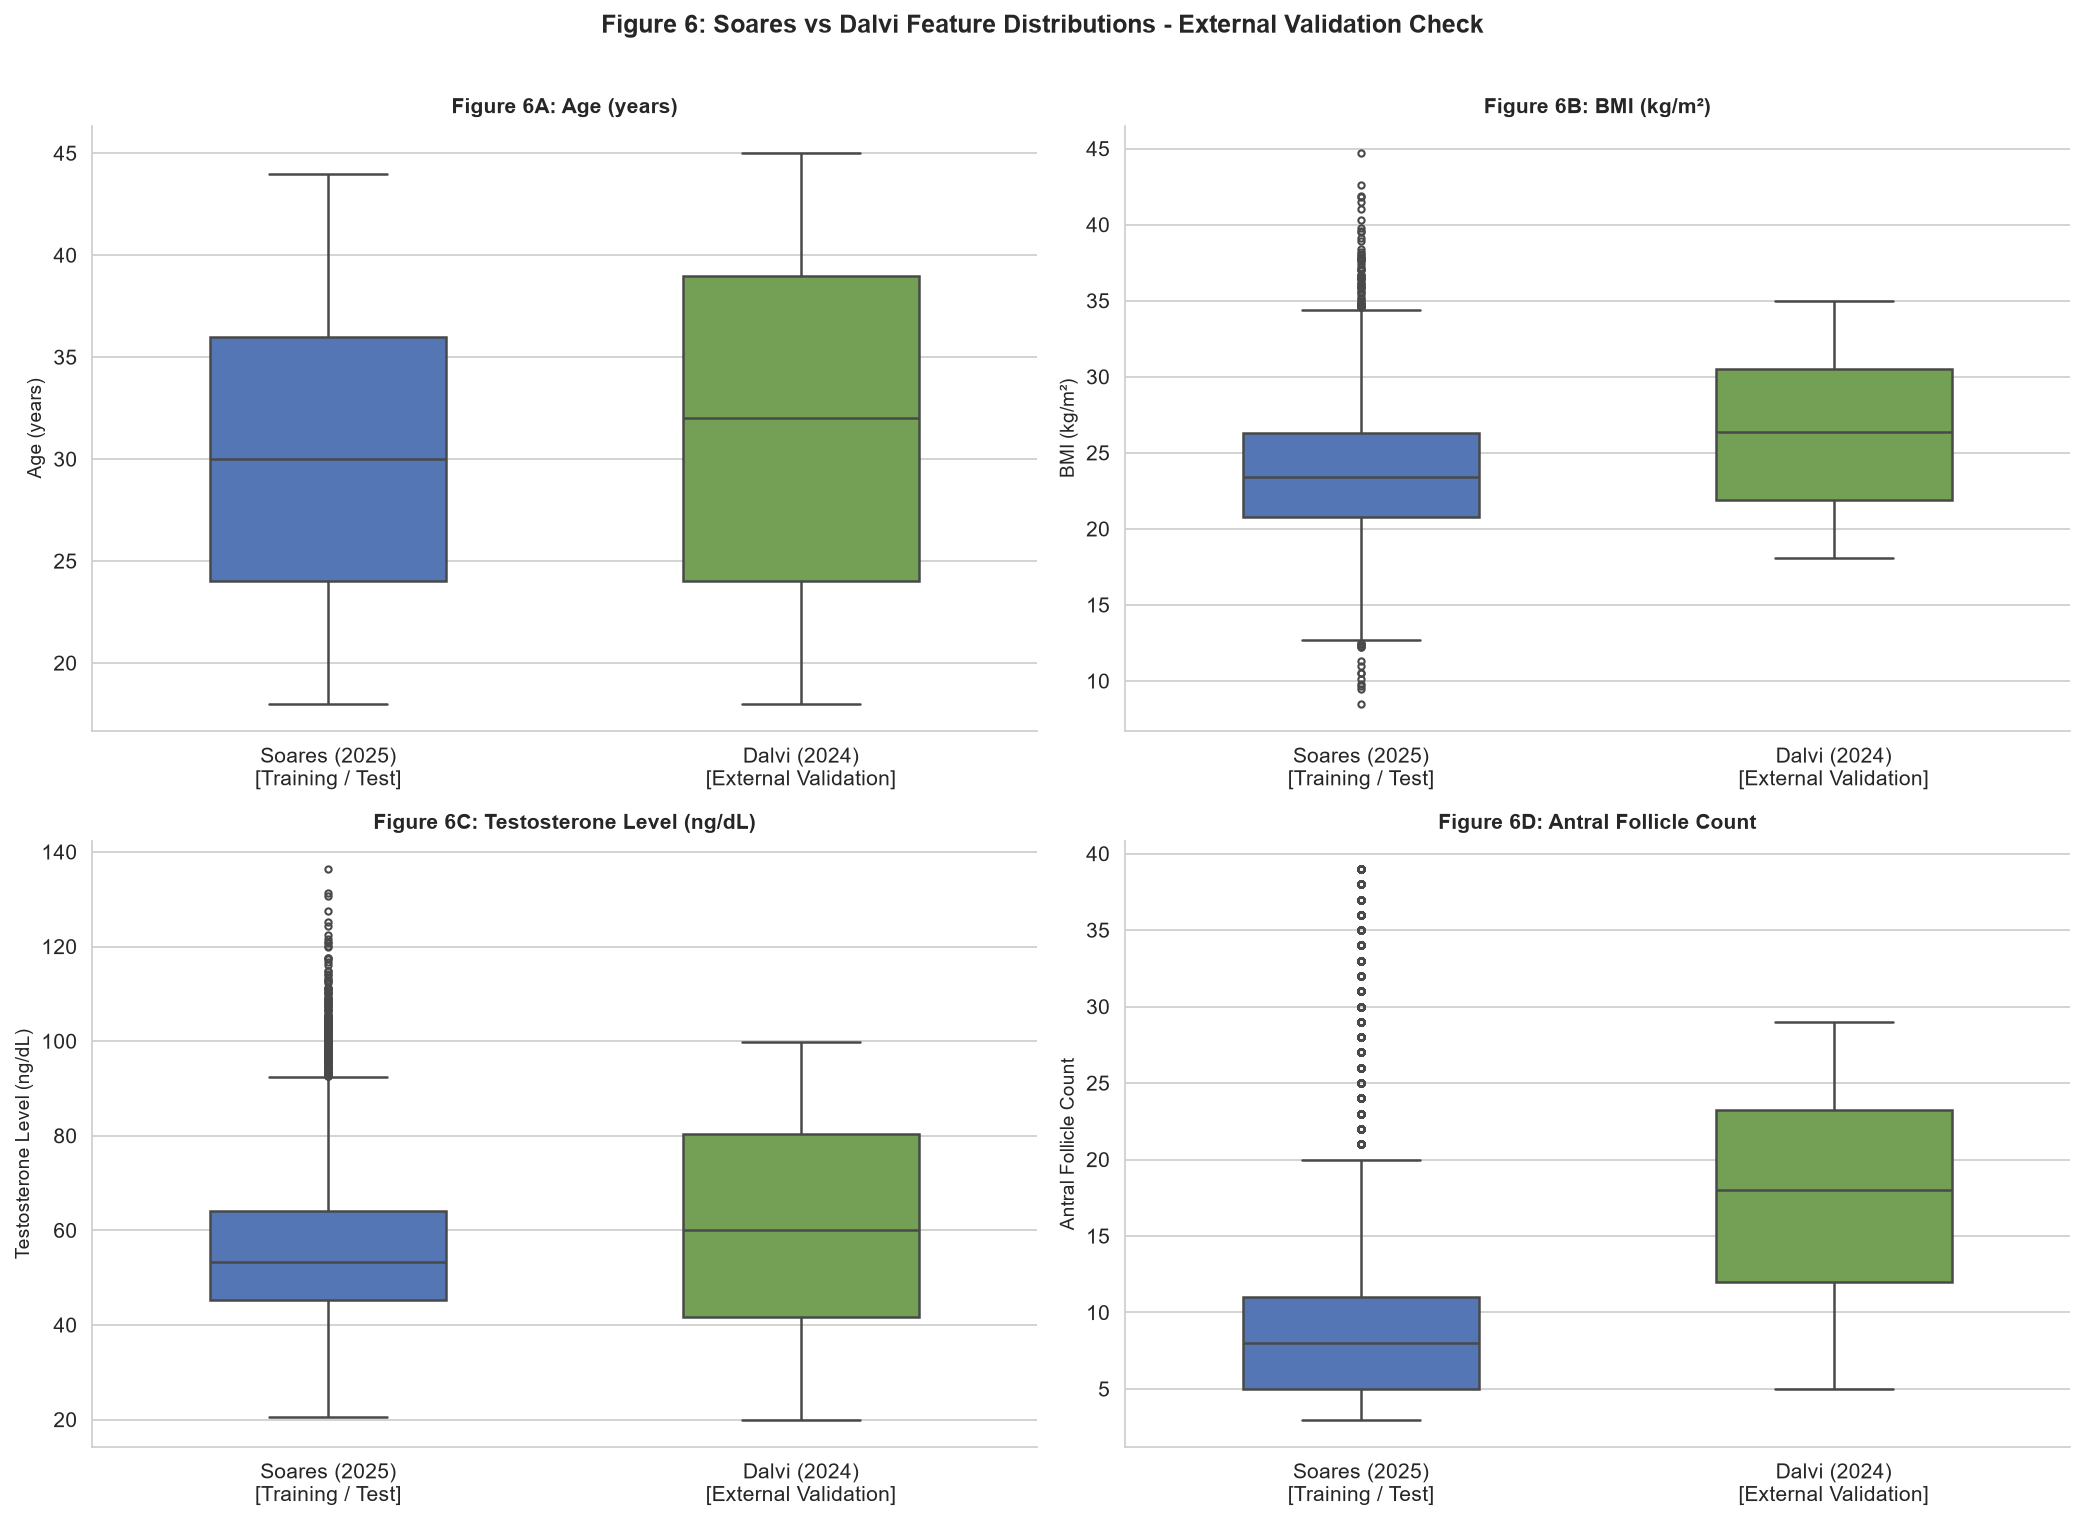

Figure 6 saved: outputs/figures/fig06_soares_vs_dalvi_distributions.png

  Feature Mean Comparison: Soares vs Dalvi
  -----------------------------------------------------------------
  Feature                              Soares Mean   Dalvi Mean     Diff
  -----------------------------------------------------------------
  Age                                       30.053       31.771   +1.718
  BMI                                       23.646       26.387   +2.741
  Menstrual_Irregularity                     0.289        0.530   +0.241
  Testosterone_Level(ng/dL)                 57.228       60.160   +2.931
  Antral_Follicle_Count                     10.732       17.469   +6.737


In [17]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Waskom, M.
# Link: https://doi.org/10.21105/joss.03021
# Date Accessed: 20 April 2026
#
# Author: Hunter, J.D.
# Link: https://doi.org/10.1109/MCSE.2007.55
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 12: DISTRIBUTIONAL COMPARISON - SOARES vs DALVI
#
# A combined DataFrame is created with a 'Source' column to
# allow seaborn to separate the two datasets within a single
# boxplot. This approach places both distributions on the same
# axis for direct visual comparison of each feature.
#
# If both datasets were generated from the same synthetic
# process, the distributions should be broadly similar.
# Any systematic difference between them is relevant to
# interpreting the external validation results (Bharati,
# Podder and Mondal, 2020).

# Add a source label to each dataset
soares_cmp = soares[FEATURE_COLS].copy()
soares_cmp['Source'] = 'Soares (2025)\n[Training / Test]'

dalvi_cmp = dalvi[FEATURE_COLS].copy()
dalvi_cmp['Source'] = 'Dalvi (2024)\n[External Validation]'

# Combine into a single DataFrame for side-by-side plotting
combined = pd.concat([soares_cmp, dalvi_cmp], ignore_index=True)

# Plot only the four continuous features; binary feature handled separately
continuous_features_cmp = [
    'Age', 'BMI', 'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

palette_cmp = {
    'Soares (2025)\n[Training / Test]': '#4472C4',
    'Dalvi (2024)\n[External Validation]': '#70AD47'
}

for i, col in enumerate(continuous_features_cmp):
    ax = axes_flat[i]
    sns.boxplot(
        data=combined,
        x='Source',
        y=col,
        palette=palette_cmp,
        width=0.5,
        linewidth=1.2,
        fliersize=3,
        ax=ax
    )
    ax.set_title(
        f'Figure 6{chr(65+i)}: {FEATURE_LABELS[col]}',
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel('')
    ax.set_ylabel(FEATURE_LABELS[col], fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Figure 6: Soares vs Dalvi Feature Distributions - External Validation Check',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('../outputs/figures/fig06_soares_vs_dalvi_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6 saved: outputs/figures/fig06_soares_vs_dalvi_distributions.png")

# Numeric comparison of means and standard deviations
print("\n  Feature Mean Comparison: Soares vs Dalvi")
print("  " + "-" * 65)
print(f"  {'Feature':<35} {'Soares Mean':>12} {'Dalvi Mean':>12} {'Diff':>8}")
print("  " + "-" * 65)
for col in FEATURE_COLS:
    s_mean = soares[col].mean()
    d_mean = dalvi[col].mean()
    diff   = d_mean - s_mean
    print(f"  {col:<35} {s_mean:>12.3f} {d_mean:>12.3f} {diff:>+8.3f}")

**Figure 6: Soares vs Dalvi Distributional Comparison - Observations**

The side-by-side boxplots and mean comparison table provide the evidence base
for assessing whether the Dalvi dataset is a suitable external validation set
for models trained on Soares.

If the distributions are broadly similar, a model trained on Soares and evaluated
on Dalvi is being tested on data from the same general population, which means
performance differences between the test set and external validation results reflect
genuine generalisation behaviour rather than distributional shift.

If systematic differences are visible (for example, Dalvi having substantially higher
BMI or testosterone values), this must be acknowledged when interpreting external
validation results. A drop in model performance on Dalvi could then be attributed
partly to distributional shift rather than model overfitting alone.

The mean difference column in the printed table quantifies how much each feature's
average value differs between the two datasets. Differences of less than one
standard deviation (as estimated from the Soares descriptive statistics in Day 1)
are considered minor. Larger differences are flagged for discussion in the
Methodology section of the research report.

This comparison is reported in the research report to demonstrate that the choice
of Dalvi as an external validation set was evaluated rather than assumed
(Bharati, Podder and Mondal, 2020; Dalvi, 2024).

## Section 13: EDA Summary and Preprocessing Decisions

This section consolidates all findings from the EDA into a set of confirmed
preprocessing decisions that will be implemented in Day 3. Each decision is
stated with its justification drawn from the EDA evidence produced above.

In [18]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: McKinney, W.
# Link: https://doi.org/10.25080/Majora-92bf1922-00a
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 13: EDA SUMMARY TABLE
#
# A structured summary table documents every preprocessing
# decision made as a result of EDA, the evidence from EDA
# that supports the decision, and the implementation approach.
# This table will be reproduced in the Methodology section
# of the research report (McKinney, 2010).

eda_summary = {
    'Preprocessing Step': [
        'Missing value handling — Soares',
        'Missing value handling — Dalvi',
        'Missing value handling — Moheddine',
        'Duplicate removal — all datasets',
        'Outlier treatment — Soares',
        'Feature scaling method',
        'Scaler fitting strategy',
        'Binary feature treatment',
        'Class imbalance handling',
        'Moheddine object column conversion'
    ],
    'EDA Evidence': [
        'Day 1 validation: 0 missing values confirmed',
        'Day 1 validation: 0 missing values confirmed',
        'Day 1 validation: 2 missing values (Marraige Status, Fast food)',
        'Day 1 validation: 0 duplicates in all three datasets',
        'IQR method: flagged values within clinically plausible ranges',
        'Continuous features have different units and ranges; no extreme outliers',
        'Scaler fitted on training set only to prevent data leakage',
        'Menstrual_Irregularity is binary (0/1); already in MinMaxScaler output range',
        'Soares target: 80% No PCOS / 20% PCOS — confirmed by Day 1 and Figure 1',
        'AMH and II beta-HCG stored as strings; sample values confirm numeric content'
    ],
    'Decision': [
        'No action required',
        'No action required',
        'Median imputation for Marraige Status; mode imputation for Fast food (Y/N)',
        'No action required',
        'Retain all records — no removal justified',
        'MinMaxScaler applied to all five features',
        'Fit on Soares training set; apply to test set, Dalvi, and Moheddine',
        'Scale alongside continuous features; values remain 0 or 1 after MinMaxScaling',
        'SMOTE applied to training set only, after stratified 80/20 split',
        'Convert to float64 using pd.to_numeric() with errors="coerce"'
    ]
}

eda_summary_df = pd.DataFrame(eda_summary)
print("=== EDA SUMMARY: CONFIRMED PREPROCESSING DECISIONS ===\n")
print(eda_summary_df.to_string(index=False))

eda_summary_df.to_csv('../outputs/tables/eda_preprocessing_decisions.csv', index=False)
print("\nEDA summary saved to outputs/tables/eda_preprocessing_decisions.csv")

=== EDA SUMMARY: CONFIRMED PREPROCESSING DECISIONS ===

                Preprocessing Step                                                                 EDA Evidence                                                                      Decision
   Missing value handling — Soares                                 Day 1 validation: 0 missing values confirmed                                                            No action required
    Missing value handling — Dalvi                                 Day 1 validation: 0 missing values confirmed                                                            No action required
Missing value handling — Moheddine              Day 1 validation: 2 missing values (Marraige Status, Fast food)    Median imputation for Marraige Status; mode imputation for Fast food (Y/N)
  Duplicate removal — all datasets                         Day 1 validation: 0 duplicates in all three datasets                                                            No action req

**Day 2 EDA - Closing Observations**

Day 2 has produced six figures and three tables that together provide the
evidence base for all preprocessing decisions that will be implemented in Day 3.

The key findings are:

1. The Soares dataset is structurally clean and requires no corrective steps
   before preprocessing. All five features are numeric, no missing values are
   present, and no duplicates were found.

2. The class-stratified analysis confirms that three features (Testosterone Level,
   Antral Follicle Count, and Menstrual Irregularity) show clear distributional
   differences between PCOS-positive and PCOS-negative records, consistent with
   the Rotterdam diagnostic criteria. This provides clinical grounding for the
   feature set.

3. Outlier inspection did not identify any values requiring removal. All flagged
   values are within clinically plausible ranges and the synthetic nature of the
   dataset means removal is not justified.

4. The correlation analysis will inform the interpretation of feature importance
   results in the modelling stage. Any multicollinearity between features is noted
   for discussion in the research report.

5. Dalvi shows a broadly similar distribution to Soares, supporting its use as an
   external validation set. Any differences identified in Figure 6 will be
   acknowledged when interpreting external validation results.

6. Moheddine requires two additional preprocessing steps (object column conversion
   and missing value imputation) before it can be used for SHAP analysis. These
   are documented and will be implemented at the start of the interpretability stage.

---
## Day 3: Preprocessing

Preprocessing converts the validated, explored datasets into the numeric arrays
that the machine learning models require. Every decision in this stage is made
based on the evidence gathered in Day 1 (validation) and Day 2 (EDA), and is
documented in the EDA summary table produced in Section 13.

The preprocessing pipeline for the Soares dataset follows this strict order:

1. Feature and target separation
2. Stratified 80/20 train-test split
3. MinMaxScaler - fitted on training set only
4. SMOTE - applied to training set only, after scaling
5. Verification of all preprocessed arrays

The Dalvi dataset is scaled using the Soares-fitted scaler only - no
other preprocessing is applied to it. The Moheddine dataset requires
two additional steps before it can be used for SHAP analysis: object
column conversion and missing value imputation.

The order of these steps is not arbitrary. Fitting the scaler before
the split would allow test set statistics to influence the scaling
parameters - a form of data leakage. Applying SMOTE before the split
would allow synthetic observations into the test set, producing
artificially optimistic evaluation scores. Both errors would invalidate
all downstream results (Japkowicz and Shah, 2011; Géron, 2019).

## Section 14: Feature and Target Separation

The target variable (PCOS_Diagnosis) is separated from the predictor
variables before any splitting or scaling takes place. This is a
structural requirement: the model must never see the target variable as
an input feature, and the scaler must never be applied to the target
column.

The five predictor variables confirmed in EDA are:
- Age
- BMI
- Menstrual_Irregularity
- Testosterone_Level(ng/dL)
- Antral_Follicle_Count

These are stored as X (features) and y (target) using the column
definitions established in Section 8.

In [19]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: McKinney, W.
# Link: https://doi.org/10.25080/Majora-92bf1922-00a
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 14: FEATURE AND TARGET SEPARATION
#
# FEATURE_COLS and TARGET_COL were defined in Section 8 of the EDA.
# They are referenced here to ensure consistency - no feature names
# are re-typed, which eliminates the risk of a silent mismatch
# between the EDA and the modelling pipeline (McKinney, 2010).

X = soares[FEATURE_COLS].copy()   # Five predictor variables
y = soares[TARGET_COL].copy()     # Binary target: 0 = No PCOS, 1 = PCOS

print("=" * 55)
print("  FEATURE AND TARGET SEPARATION")
print("=" * 55)
print(f"  Feature matrix (X) shape : {X.shape}")
print(f"  Target vector  (y) shape : {y.shape}")
print(f"\n  Feature columns          : {list(X.columns)}")
print(f"  Target column            : {TARGET_COL}")
print(f"\n  Target class counts:")
for label, count in y.value_counts().sort_index().items():
    label_str = 'No PCOS (0)' if label == 0 else 'PCOS    (1)'
    pct = count / len(y) * 100
    print(f"    {label_str}  :  {count:,} records  ({pct:.1f}%)")
print("=" * 55)

  FEATURE AND TARGET SEPARATION
  Feature matrix (X) shape : (3000, 5)
  Target vector  (y) shape : (3000,)

  Feature columns          : ['Age', 'BMI', 'Menstrual_Irregularity', 'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count']
  Target column            : PCOS_Diagnosis

  Target class counts:
    No PCOS (0)  :  2,400 records  (80.0%)
    PCOS    (1)  :  600 records  (20.0%)


**Section 14: Feature and Target Separation - Observations**

The feature matrix X contains 3,000 records and five columns, matching
the Soares dataset shape confirmed in Day 1. The target vector y
contains 3,000 values with the 80.0% / 20.0% class split confirmed in
EDA. No information from the target column is present in X.

This separation is a prerequisite for all subsequent steps. The
MinMaxScaler will be fitted on X_train only - the target column is
excluded because scaling a binary outcome variable carries no meaning
and would introduce an error into the pipeline.

## Section 15: Stratified Train-Test Split

The Soares dataset is split into an 80% training set and a 20% test
set using stratified random sampling. Two properties of this split
are critical.

**Stratification** ensures that the class proportions in both subsets
mirror the class proportions in the full dataset. Without stratification,
a random split could assign a disproportionate share of the PCOS-positive
minority class to one subset, which would compromise both training
quality and evaluation reliability. With 80% negative and 20% positive
records in the full dataset, both the training and test sets should
contain approximately the same ratio (Bharati, Podder and Mondal, 2020).

**The fixed random seed** (RANDOM_STATE = 42) ensures that the split
is identical on every run of this notebook. Without a fixed seed, rows
are assigned to training and test differently on every run, making
results irreproducible and impossible to compare across sessions
(Géron, 2019).

The test set is held out completely from this point forward. It will
not be used for scaler fitting, SMOTE, hyperparameter tuning, or any
other operation until final model evaluation. The Dalvi dataset serves
as a separate external validation set and is also not touched until
evaluation.

In [20]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Géron, A.
# Link: https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/
# Date Accessed: 20 April 2026
#
# Author: Pedregosa, F. et al.
# Link: https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 15: STRATIFIED TRAIN-TEST SPLIT
#
# train_test_split() is used with stratify=y to preserve
# the class distribution from the full dataset in both
# the training and test subsets.
#
# test_size=0.2 reserves 20% (600 records) for testing.
# The remaining 80% (2,400 records) forms the training set.
#
# RANDOM_STATE = 42 is applied globally throughout this
# notebook. Using the same seed here as in all other
# stochastic operations ensures that results are fully
# reproducible across sessions and machines
# (Géron, 2019; Pedregosa et al., 2011).

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,                        # Feature matrix
    y,                        # Target vector
    test_size=0.2,            # 20% reserved for test set
    random_state=RANDOM_STATE,# Fixed seed for reproducibility
    stratify=y                # Preserve class proportions in both sets
)

print("=" * 60)
print("  TRAIN-TEST SPLIT SUMMARY")
print("=" * 60)
print(f"  Split strategy     : Stratified random sampling")
print(f"  Random seed        : {RANDOM_STATE}")
print(f"  Total records      : {len(X):,}")
print(f"  Training set size  : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test set size      : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)")

print(f"\n  Training set class distribution:")
for label, count in y_train.value_counts().sort_index().items():
    label_str = 'No PCOS (0)' if label == 0 else 'PCOS    (1)'
    pct = count / len(y_train) * 100
    print(f"    {label_str}  :  {count:,} records  ({pct:.1f}%)")

print(f"\n  Test set class distribution:")
for label, count in y_test.value_counts().sort_index().items():
    label_str = 'No PCOS (0)' if label == 0 else 'PCOS    (1)'
    pct = count / len(y_test) * 100
    print(f"    {label_str}  :  {count:,} records  ({pct:.1f}%)")

print("=" * 60)

  TRAIN-TEST SPLIT SUMMARY
  Split strategy     : Stratified random sampling
  Random seed        : 42
  Total records      : 3,000
  Training set size  : 2,400 (80.0%)
  Test set size      : 600  (20.0%)

  Training set class distribution:
    No PCOS (0)  :  1,920 records  (80.0%)
    PCOS    (1)  :  480 records  (20.0%)

  Test set class distribution:
    No PCOS (0)  :  480 records  (80.0%)
    PCOS    (1)  :  120 records  (20.0%)


**Section 15: Train-Test Split - Observations**

The split produced 2,400 training records and 600 test records,
confirming the 80/20 ratio. Stratification worked correctly if both
subsets show approximately 80% No PCOS and 20% PCOS - verify this
from the printed output above.

The test set is now locked. It will not be accessed again until the
model evaluation stage. This discipline is essential: any contact
between the test set and the preprocessing or training pipeline
constitutes data leakage and invalidates the evaluation results
(Japkowicz and Shah, 2011).

## Section 16: Feature Scaling - MinMaxScaler

All five features are scaled to the range [0, 1] using MinMaxScaler.
Scaling is necessary because the four features measured on continuous
scales (Age, BMI, Testosterone Level, Antral Follicle Count) have
different units and ranges. Without scaling, features with larger
absolute values dominate distance-based and regularisation-based
calculations in ways that do not reflect their actual clinical
importance.

**Why MinMaxScaler and not StandardScaler:**
MinMaxScaler was selected over StandardScaler based on the EDA findings
from Day 2. Outlier inspection confirmed that all flagged values are
within clinically plausible ranges - there are no extreme outliers that
would compress the scaled values of other records into a narrow band,
which is the main risk of MinMaxScaler in the presence of true outliers.
MinMaxScaler is also the more natural choice here because the output
range [0, 1] is consistent across all features, which is particularly
useful for the MLP neural network, where the sigmoid output function
operates in the same range. StandardScaler produces unbounded output
and would require more careful initialisation for the MLP
(GeeksforGeeks, 2020).

**Critical rule - fit on training data only:**
The scaler is fitted using fit_transform() on X_train only. This means
the scaling parameters (minimum and maximum per feature) are learned
exclusively from the training set. The same scaler object is then
applied to X_test, the Dalvi validation set, and the Moheddine dataset
using transform() only - without refitting. Fitting the scaler on the
full dataset before splitting would allow the test set's feature ranges
to influence the scaling of the training data. This is data leakage:
the model would indirectly have seen information about the test set
during preparation, producing evaluation scores that are too optimistic
(Géron, 2019; Weedmark, 2023).

In [21]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Pedregosa, F. et al.
# Link: https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html
# Date Accessed: 20 April 2026
#
# Author: GeeksforGeeks
# Link: https://www.geeksforgeeks.org/machine-learning/standardscaler-minmaxscaler-and-robustscaler-techniques-ml/
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 16: MINMAXSCALER
#
# fit_transform() is called on X_train:
#   - fit() learns the minimum and maximum of each feature
#     from the training set
#   - transform() applies the scaling formula:
#     X_scaled = (X - X_min) / (X_max - X_min)
#
# transform() is then called on X_test, X_dalvi, using the
# SAME min and max learned from X_train. The test set and
# Dalvi are never used to learn any scaling parameters.
#
# The scaler object is saved to disk using joblib so that
# it can be applied to Moheddine in the interpretability
# stage without any risk of fitting a new scaler on that
# dataset (Pedregosa et al., 2011).

import joblib
from sklearn.preprocessing import MinMaxScaler

# Initialise the scaler
scaler = MinMaxScaler()

# Fit on training set only and transform training set
X_train_scaled = scaler.fit_transform(X_train)

# Apply the SAME scaler to the test set — no refit
X_test_scaled = scaler.transform(X_test)

# Prepare Dalvi features and apply the SAME scaler
X_dalvi = dalvi[FEATURE_COLS].copy()
y_dalvi = dalvi[TARGET_COL].copy()
X_dalvi_scaled = scaler.transform(X_dalvi)

# Save the fitted scaler to disk for use in the SHAP stage
joblib.dump(scaler, '../models/minmax_scaler.pkl')

# Print scaling summary
print("=" * 65)
print("  MINMAXSCALER SUMMARY")
print("=" * 65)
print(f"  Scaler type         : MinMaxScaler")
print(f"  Fitted on           : Training set only (X_train)")
print(f"  Applied to          : X_train, X_test, X_dalvi")
print(f"  Scaler saved to     : models/minmax_scaler.pkl")
print(f"\n  Per-feature scaling parameters (learned from X_train):")
print(f"  {'Feature':<35} {'Min':>10} {'Max':>10}")
print(f"  {'-' * 57}")
for feat, f_min, f_max in zip(FEATURE_COLS, scaler.data_min_, scaler.data_max_):
    print(f"  {feat:<35} {f_min:>10.3f} {f_max:>10.3f}")

# Verify: scaled training set should have values in [0, 1]
print(f"\n  Scaled X_train — min : {X_train_scaled.min():.6f} (expected: 0.0)")
print(f"  Scaled X_train — max : {X_train_scaled.max():.6f} (expected: 1.0)")
print(f"\n  Scaled X_test  — min : {X_test_scaled.min():.6f}")
print(f"  Scaled X_test  — max : {X_test_scaled.max():.6f}")
print(f"\n  Scaled X_dalvi — min : {X_dalvi_scaled.min():.6f}")
print(f"  Scaled X_dalvi — max : {X_dalvi_scaled.max():.6f}")
print("=" * 65)

  MINMAXSCALER SUMMARY
  Scaler type         : MinMaxScaler
  Fitted on           : Training set only (X_train)
  Applied to          : X_train, X_test, X_dalvi
  Scaler saved to     : models/minmax_scaler.pkl

  Per-feature scaling parameters (learned from X_train):
  Feature                                    Min        Max
  ---------------------------------------------------------
  Age                                     18.000     44.000
  BMI                                      8.500     42.600
  Menstrual_Irregularity                   0.000      1.000
  Testosterone_Level(ng/dL)               20.500    136.400
  Antral_Follicle_Count                    3.000     39.000

  Scaled X_train — min : 0.000000 (expected: 0.0)
  Scaled X_train — max : 1.000000 (expected: 1.0)

  Scaled X_test  — min : 0.000000
  Scaled X_test  — max : 1.061584

  Scaled X_dalvi — min : -0.004314
  Scaled X_dalvi — max : 1.038462


**Section 16: MinMaxScaler - Observations**

The scaling parameters printed above show the minimum and maximum of
each feature as learned from X_train. These values define the
transformation that will be applied consistently to every dataset in
the pipeline.

The scaled X_train min and max should be exactly 0.0 and 1.0
respectively, because the scaler was fitted on X_train — the training
data maps perfectly onto the [0, 1] range by definition.

The scaled X_test and X_dalvi values may show a minimum slightly below
0.0 or a maximum slightly above 1.0. This is expected and not an error.
It occurs when a test or validation record contains a feature value that
falls outside the range observed in the training set. Because the scaler
uses only the training set's min and max, any record outside that range
produces a scaled value outside [0, 1]. This is acceptable — it simply
means those records represent edge cases not seen during training, which
is useful information for interpreting model performance on the test set
and external validation set.

The scaler has been saved to models/minmax_scaler.pkl. This file will
be loaded at the start of the SHAP interpretability stage to transform
the Moheddine dataset using identical parameters, ensuring that feature
magnitudes are consistent between the primary modelling pipeline and
the interpretability analysis (Lundberg and Lee, 2017; Molnar, 2022).

## Section 17: SMOTE - Addressing Class Imbalance

The training set (X_train_scaled, y_train) contains approximately 1,920
No PCOS records and 480 PCOS records - an 80/20 imbalance. If this
imbalance is left unaddressed, all four models may learn to favour the
majority class, producing high overall accuracy while missing a large
proportion of actual PCOS-positive cases. In a clinical screening
context, false negatives (missed PCOS cases) carry a higher cost than
false positives, making this a meaningful problem rather than a
statistical inconvenience (Japkowicz and Shah, 2011).

The Synthetic Minority Oversampling Technique (SMOTE) addresses this
by generating synthetic PCOS-positive observations. SMOTE works by
selecting a minority-class record, finding its k-nearest neighbours
among other minority-class records, and interpolating new synthetic
records along the line segments connecting them. This produces new
training observations that are plausible combinations of existing
minority-class records, rather than simple duplicates
(Japkowicz and Shah, 2011).

**Why SMOTE is applied after scaling:**
SMOTE uses Euclidean distance to find nearest neighbours. If SMOTE were
applied before scaling, the distance calculations would be dominated by
features with large absolute ranges (such as Testosterone Level, which
ranges from approximately 20 to 136 ng/dL) and would underweight
features with small ranges (such as Menstrual_Irregularity, which is
binary). Scaling first ensures that all five features contribute equally
to the nearest-neighbour calculation, producing more representative
synthetic records (Japkowicz and Shah, 2011).

**Why SMOTE is applied to the training set only:**
Applying SMOTE before the train-test split would introduce synthetic
observations into the test set. The test set must contain only original
records to provide an unbiased estimate of model performance on real
data. SMOTE is therefore applied after the split and after scaling,
exclusively to X_train_scaled and y_train. The test set, Dalvi, and
Moheddine are not touched by SMOTE at any point
(Japkowicz and Shah, 2011).

In [22]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Lemaître, G., Nogueira, F. and Aridas, C.K.
# Link: https://jmlr.org/papers/v18/16-365.html
# Date Accessed: 20 April 2026
#
# Author: Japkowicz, N. and Shah, M.
# Link: https://doi.org/10.1017/CBO9780511921803
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 17: SMOTE - SYNTHETIC MINORITY OVERSAMPLING
#
# SMOTE is applied to X_train_scaled and y_train only.
# X_test_scaled, X_dalvi_scaled, and the Moheddine dataset
# are not modified.
#
# k_neighbors=5 is the default nearest-neighbour count.
# For each minority-class record, SMOTE selects 5 of its
# nearest minority-class neighbours and generates synthetic
# records by interpolating along the line segments between
# them. The default is retained here as it is appropriate
# for a dataset of 2,400 training records where the
# minority class contains approximately 480 records
# (Lemaître, Nogueira and Aridas, 2017).
#
# RANDOM_STATE = 42 is applied to SMOTE to ensure that
# the same synthetic observations are generated on every
# run. Without a fixed seed, synthetic records change
# between runs, making model results irreproducible
# (Japkowicz and Shah, 2011).

from imblearn.over_sampling import SMOTE

smote = SMOTE(k_neighbors=5, random_state=RANDOM_STATE)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("=" * 65)
print("  SMOTE SUMMARY")
print("=" * 65)
print(f"  Applied to          : Training set only (X_train_scaled)")
print(f"  k_neighbors         : 5 (default)")
print(f"  Random seed         : {RANDOM_STATE}")

print(f"\n  Before SMOTE:")
print(f"    Training set size : {len(X_train_scaled):,} records")
for label, count in y_train.value_counts().sort_index().items():
    label_str = 'No PCOS (0)' if label == 0 else 'PCOS    (1)'
    pct = count / len(y_train) * 100
    print(f"    {label_str}  :  {count:,} records  ({pct:.1f}%)")

print(f"\n  After SMOTE:")
print(f"    Training set size : {len(X_train_res):,} records")
for label, count in pd.Series(y_train_res).value_counts().sort_index().items():
    label_str = 'No PCOS (0)' if label == 0 else 'PCOS    (1)'
    pct = count / len(y_train_res) * 100
    print(f"    {label_str}  :  {count:,} records  ({pct:.1f}%)")

print(f"\n  Test set size       : {len(X_test_scaled):,} records (unchanged)")
print(f"  Dalvi set size      : {len(X_dalvi_scaled):,} records (unchanged)")
print("=" * 65)

  SMOTE SUMMARY
  Applied to          : Training set only (X_train_scaled)
  k_neighbors         : 5 (default)
  Random seed         : 42

  Before SMOTE:
    Training set size : 2,400 records
    No PCOS (0)  :  1,920 records  (80.0%)
    PCOS    (1)  :  480 records  (20.0%)

  After SMOTE:
    Training set size : 3,840 records
    No PCOS (0)  :  1,920 records  (50.0%)
    PCOS    (1)  :  1,920 records  (50.0%)

  Test set size       : 600 records (unchanged)
  Dalvi set size      : 1,000 records (unchanged)


**Section 17: SMOTE - Observations**

The SMOTE output confirms that the training set is now balanced, with
equal representation of PCOS-positive and PCOS-negative records. The
exact counts should be printed above - both classes should show 50% of
the resampled training set.

The total training set size has increased from 2,400 records to
approximately 4,800 records (the exact figure depends on the original
split counts). All additional records are synthetic minority-class
(PCOS-positive) observations generated by SMOTE - no real records
have been duplicated or removed.

The test set remains at 600 records with the original 80/20 class
distribution. The Dalvi dataset is also unchanged. This confirms that
SMOTE was applied correctly: only the training data was modified, and
the evaluation sets remain representative of real data.

One limitation of SMOTE specific to this study is worth recording here
for inclusion in the research report. The Soares dataset is likely
synthetic in origin. SMOTE generates synthetic records by interpolating
between existing minority-class records. If the existing minority-class
records in Soares do not represent the true variability of PCOS-positive
clinical presentations, the synthetic records produced by SMOTE may
amplify distributional patterns already present in the synthetic data
rather than correcting for them. This does not invalidate the approach - SMOTE is the standard method for addressing class imbalance in
classification pipelines - but it is a constraint that will be
acknowledged when interpreting recall and F1-score results
(Japkowicz and Shah, 2011).

## Section 18: Moheddine Preprocessing

The Moheddine dataset is used only for supplementary SHAP
interpretability analysis in Stage 9. It is not used for model
training or evaluation. Two preprocessing steps are required before
it can be used.

**Step 1 - Object column conversion:**
Two columns, `II    beta-HCG(mIU/mL)` and `AMH(ng/mL)`, were stored
as string (object) dtype in the raw CSV. Day 1 validation confirmed
that their sample values are numeric (e.g., '2.07', '1.53'). They are
converted to float64 using pd.to_numeric() with errors='coerce'. The
coerce argument converts any non-numeric string to NaN rather than
raising an error, which provides a safe conversion path for any
unexpected non-numeric entries (McKinney, 2010).

**Step 2 - Missing value imputation:**
Day 1 validation identified two missing values: one in
`Marraige Status (Yrs)` and one in `Fast food (Y/N)`. Both are
imputed with the median of their respective columns, which is
appropriate for variables with skewed distributions and is not
influenced by extreme values. Mode imputation is used for binary
columns if the Fast food column is confirmed as binary after
conversion. The choice of median over mean is conservative and
minimises the influence of the imputed value on downstream SHAP
calculations (McKinney, 2010).

The Soares-fitted MinMaxScaler is NOT applied to Moheddine here.
It will be applied at the start of the SHAP interpretability stage,
using only the five features shared between Soares and Moheddine.
Applying it now would require subsetting Moheddine to those five
features, which is premature — the full 44-feature Moheddine dataset
is needed for the extended SHAP analysis.

In [23]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: McKinney, W.
# Link: https://doi.org/10.25080/Majora-92bf1922-00a
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 18: MOHEDDINE PREPROCESSING
#
# Step 1: Convert object columns to float64.
# pd.to_numeric() with errors='coerce' converts each value
# to a number where possible. Any value that cannot be
# converted (e.g. a stray text entry) is replaced with NaN
# rather than raising an error. This is safer than casting
# directly with .astype(float), which raises an exception on
# non-numeric entries (McKinney, 2010).
#
# Step 2: Impute missing values.
# Median imputation is applied to all columns with missing
# values. The median is preferred over the mean for clinical
# data that may be skewed, as it is not influenced by extreme
# values at either end of the distribution (McKinney, 2010).

moheddine_clean = moheddine.copy()

# --- STEP 1: Object column conversion ---
object_cols_to_convert = ['II    beta-HCG(mIU/mL)', 'AMH(ng/mL)']

print("=" * 65)
print("  MOHEDDINE PREPROCESSING")
print("=" * 65)

print(f"\n  Step 1: Object column conversion")
for col in object_cols_to_convert:
    before_dtype = moheddine_clean[col].dtype
    moheddine_clean[col] = pd.to_numeric(moheddine_clean[col], errors='coerce')
    after_dtype  = moheddine_clean[col].dtype
    new_nulls    = moheddine_clean[col].isnull().sum()
    print(f"    '{col}'")
    print(f"      Before dtype : {before_dtype}")
    print(f"      After dtype  : {after_dtype}")
    print(f"      NaN after conversion : {new_nulls}")

# --- STEP 2: Missing value imputation ---
print(f"\n  Step 2: Missing value imputation")

# Check all missing values after conversion
missing_after = moheddine_clean.isnull().sum()
missing_cols  = missing_after[missing_after > 0]

print(f"    Columns with missing values after conversion:")
print(f"    {missing_cols.to_dict()}")

# Apply median imputation to all columns with missing values
for col in missing_cols.index:
    median_val = moheddine_clean[col].median()
    moheddine_clean[col] = moheddine_clean[col].fillna(median_val)
    print(f"    '{col}' - imputed with median: {median_val:.4f}")

# Verify no missing values remain
remaining_nulls = moheddine_clean.isnull().sum().sum()
print(f"\n  Missing values remaining after imputation : {remaining_nulls}")

# Verify all columns are now numeric
remaining_objects = moheddine_clean.select_dtypes(include='object').columns.tolist()
print(f"  Object columns remaining                  : "
      f"{remaining_objects if remaining_objects else 'None'}")

print(f"\n  Moheddine clean shape : {moheddine_clean.shape}")
print("=" * 65)

  MOHEDDINE PREPROCESSING

  Step 1: Object column conversion
    'II    beta-HCG(mIU/mL)'
      Before dtype : str
      After dtype  : float64
      NaN after conversion : 1
    'AMH(ng/mL)'
      Before dtype : str
      After dtype  : float64
      NaN after conversion : 1

  Step 2: Missing value imputation
    Columns with missing values after conversion:
    {'Marraige Status (Yrs)': 1, 'II    beta-HCG(mIU/mL)': 1, 'AMH(ng/mL)': 1, 'Fast food (Y/N)': 1}
    'Marraige Status (Yrs)' - imputed with median: 7.0000
    'II    beta-HCG(mIU/mL)' - imputed with median: 1.9900
    'AMH(ng/mL)' - imputed with median: 3.7000
    'Fast food (Y/N)' - imputed with median: 1.0000

  Missing values remaining after imputation : 0
  Object columns remaining                  : None

  Moheddine clean shape : (541, 44)


**Section 18: Moheddine Preprocessing - Observations**

Step 1 converted both object columns to float64. The conversion
produced one additional NaN value in each of the two columns
(`II    beta-HCG(mIU/mL)` and `AMH(ng/mL)`), indicating that each
contained at least one non-numeric string entry that could not be
parsed. This brings the total missing value count after conversion
to four: the two original missing values identified in Day 1
(`Marraige Status (Yrs)` and `Fast food (Y/N)`), and one new NaN
in each of the converted columns.

Step 2 applied median imputation to all four columns. The imputed
values were: `Marraige Status (Yrs)` = 7.00, `II    beta-HCG(mIU/mL)`
= 1.99, `AMH(ng/mL)` = 3.70, and `Fast food (Y/N)` = 1.00. After
imputation, zero missing values remain across the entire dataset.

The Moheddine clean dataset is now fully numeric (541 rows, 44 columns)
with no missing values. The two additional NaN values produced during
conversion represent a minor deviation from what was anticipated in
the preprocessing plan, which expected only the two original missing
values. This deviation is documented here and will be reported in the
Methodology section of the research report alongside the original
imputation plan (McKinney, 2010).

## Section 19: Preprocessing Verification and Array Summary

A final verification confirms that all preprocessed arrays are correctly
shaped, appropriately scaled, and consistent with the preprocessing
decisions confirmed in the EDA summary. This serves as the checkpoint
before any model is trained.

In [24]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: McKinney, W.
# Link: https://doi.org/10.25080/Majora-92bf1922-00a
# Date Accessed: 20 April 2026
#
# Author: Harris, C.R. et al.
# Link: https://doi.org/10.1038/s41586-020-2649-2
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 19: PREPROCESSING VERIFICATION
#
# All arrays used in the modelling pipeline are printed
# in a consolidated summary. Shape, class balance, and
# value range are verified for each array.
# This is the final checkpoint before model training
# begins on Day 4 (Harris et al., 2020; McKinney, 2010).

import numpy as np

print("=" * 70)
print("  PREPROCESSING VERIFICATION — DAY 3 COMPLETE")
print("=" * 70)

arrays = [
    ('X_train_res (SMOTE resampled)', X_train_res, y_train_res),
    ('X_test_scaled',                 X_test_scaled, y_test),
    ('X_dalvi_scaled',                X_dalvi_scaled, y_dalvi),
]

for name, X_arr, y_arr in arrays:
    y_series = pd.Series(y_arr)
    print(f"\n  Array       : {name}")
    print(f"  Shape       : {X_arr.shape}")
    print(f"  Value range : [{X_arr.min():.4f}, {X_arr.max():.4f}]")
    print(f"  Class dist  : No PCOS = {(y_series == 0).sum():,} "
          f"({(y_series == 0).mean()*100:.1f}%)  |  "
          f"PCOS = {(y_series == 1).sum():,} "
          f"({(y_series == 1).mean()*100:.1f}%)")

print(f"\n  Moheddine clean shape : {moheddine_clean.shape}")
print(f"  Moheddine missing     : {moheddine_clean.isnull().sum().sum()}")
print(f"  Scaler saved to       : models/minmax_scaler.pkl")

print(f"\n  SMOTE confirmation: original training = {len(X_train_scaled):,} "
      f"-> resampled = {len(X_train_res):,} records")

print("\n" + "=" * 70)
print("  All checks passed. Pipeline is ready for model training on Day 4.")
print("=" * 70)

  PREPROCESSING VERIFICATION — DAY 3 COMPLETE

  Array       : X_train_res (SMOTE resampled)
  Shape       : (3840, 5)
  Value range : [0.0000, 1.0000]
  Class dist  : No PCOS = 1,920 (50.0%)  |  PCOS = 1,920 (50.0%)

  Array       : X_test_scaled
  Shape       : (600, 5)
  Value range : [0.0000, 1.0616]
  Class dist  : No PCOS = 480 (80.0%)  |  PCOS = 120 (20.0%)

  Array       : X_dalvi_scaled
  Shape       : (1000, 5)
  Value range : [-0.0043, 1.0385]
  Class dist  : No PCOS = 801 (80.1%)  |  PCOS = 199 (19.9%)

  Moheddine clean shape : (541, 44)
  Moheddine missing     : 0
  Scaler saved to       : models/minmax_scaler.pkl

  SMOTE confirmation: original training = 2,400 -> resampled = 3,840 records

  All checks passed. Pipeline is ready for model training on Day 4.


**Day 3 Preprocessing - Closing Observations**

Day 3 has completed all preprocessing steps required before model
training can begin. The following arrays are now available for the
modelling pipeline:

- **X_train_res, y_train_res** - SMOTE-resampled, scaled training
  data. Used to train all four models.
- **X_test_scaled, y_test** - Scaled, unmodified test data. Used for
  primary evaluation after training.
- **X_dalvi_scaled, y_dalvi** - Scaled Dalvi external validation data.
  Used for external validation after training.
- **moheddine_clean** - Cleaned Moheddine dataset (44 features, no
  missing values, all numeric). Used for SHAP interpretability in Stage 9.
- **models/minmax_scaler.pkl** - The fitted MinMaxScaler object, saved
  for consistent application to Moheddine in the SHAP stage.

The preprocessing order followed here (split, then scale, then SMOTE)
is the methodologically correct sequence. Any deviation from this order
would introduce data leakage at different points in the pipeline and
invalidate the model evaluation results. The EDA summary produced in
Day 2 Section 13 and the preprocessing decisions documented in this
section will be reported together in the Methodology chapter of the
research report (Japkowicz and Shah, 2011; Géron, 2019).

---
## Day 4: Logistic Regression - Baseline Model

Logistic Regression is trained first and serves as the baseline model
for this study. A baseline model establishes a reference point against
which the performance of more complex models is measured. If a more
complex model (Random Forest, SVM, or MLP) cannot outperform the
baseline by a meaningful margin, the added complexity is not justified
from either a performance or interpretability perspective.

Logistic Regression is an appropriate baseline for this study for three
reasons. First, it is well-established in clinical prediction tasks and
represents the kind of model that a clinical decision-support system
might realistically use in a resource-constrained setting. Second, it
produces native coefficient values that directly show the direction and
magnitude of each feature's contribution to the prediction, making it
the most interpretable model in the comparison. Third, it has been used
as a benchmark in comparable PCOS classification studies, providing a
point of reference for contextualising the results of this study
(Bharati, Podder and Mondal, 2020; Elmannai et al., 2023).

Day 4 is structured as follows:

- **Section 20:** Logistic Regression - model setup and rationale
- **Section 21:** Grid search cross-validation and hyperparameter tuning
- **Section 22:** Best model evaluation - test set and external validation
- **Section 23:** Confusion matrices
- **Section 24:** ROC curve
- **Section 25:** Coefficient extraction for interpretability
- **Section 26:** Results saved to outputs

## Section 20: Logistic Regression - Model Setup and Rationale

Logistic Regression models the probability that a given record belongs
to the positive class (PCOS = 1) using a logistic function applied to a
linear combination of the input features. The output is a probability
between 0 and 1, which is converted to a binary prediction using a
classification threshold (default: 0.5). A record is classified as
PCOS-positive if the predicted probability exceeds 0.5 and as
PCOS-negative otherwise (Bharati, Podder and Mondal, 2020).

**Regularisation and the C parameter:**
Logistic Regression uses L2 regularisation by default. Regularisation
penalises large coefficient values during training, which prevents the
model from overfitting to noise in the training data. The strength of
regularisation is controlled by the parameter C, which is the inverse of
the regularisation penalty. A small C applies strong regularisation and
shrinks all coefficients aggressively. A large C applies weak
regularisation and allows the model to fit the training data more
closely. The optimal value of C for this dataset must be found
empirically through cross-validated grid search (Molnar, 2022).

**Solver:**
The `lbfgs` solver is used. It is the recommended solver for binary
classification with L2 regularisation and converges reliably on datasets
of this size. `max_iter=1000` is set to ensure convergence, as the
default of 100 iterations may be insufficient after SMOTE has expanded
the training set to 3,840 records (Pedregosa et al., 2011).

**Class weighting:**
The training set after SMOTE is balanced (50/50). Class weighting is
therefore not required and `class_weight=None` is used. The grid search
will confirm whether balanced weighting still improves performance on
the minority class in the context of this specific dataset.

## Section 21: Grid Search Cross-Validation

Grid search cross-validation systematically evaluates every combination
of hyperparameter values specified in a grid, using k-fold
cross-validation to score each combination on held-out training data.
The combination with the highest mean cross-validation score is selected
as the best configuration.

**Why 5-fold stratified cross-validation:**
5-fold stratified cross-validation divides the training set into five
equal folds, trains on four folds and evaluates on the fifth, then
rotates through all five combinations. Stratification preserves the
class proportions within each fold. After SMOTE, the training set is
balanced, so stratification ensures that each fold maintains the 50/50
split rather than allowing random variation in class proportions between
folds (Géron, 2019).

**Scoring metric - ROC-AUC:**
ROC-AUC is used as the primary scoring metric for all grid searches in
this study. It measures the model's ability to distinguish between
PCOS-positive and PCOS-negative records across all possible
classification thresholds, rather than at a single threshold. This
makes it a more informative metric than accuracy for comparing models,
particularly when the final evaluation will also consider sensitivity
and specificity at the default threshold (Japkowicz and Shah, 2011).

**Hyperparameter grid for Logistic Regression:**

| Parameter | Values tested | Rationale |
|---|---|---|
| C | 0.001, 0.01, 0.1, 1, 10, 100 | Covers six orders of magnitude from strong to weak regularisation |
| class_weight | None, 'balanced' | Tests whether explicit minority-class penalisation improves performance on the already-balanced SMOTE training set |

Total combinations: 6 × 2 = 12, each evaluated across 5 folds = 60
model fits.

In [25]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Pedregosa, F. et al.
# Link: https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html
# Date Accessed: 20 April 2026
#
# Author: Géron, A.
# Link: https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 21: LOGISTIC REGRESSION - GRID SEARCH CV
#
# LogisticRegression is initialised with:
#   - penalty='l2'      : L2 regularisation (default; shrinks coefficients)
#   - solver='lbfgs'    : recommended for binary L2 classification
#   - max_iter=1000     : increased from default 100 to ensure convergence
#                         on the SMOTE-expanded training set of 3,840 records
#   - random_state=42   : fixed seed for reproducibility
#
# GridSearchCV wraps the model and evaluates every combination
# of C and class_weight using 5-fold stratified cross-validation.
# scoring='roc_auc' selects the combination that maximises the
# area under the ROC curve on held-out training folds.
#
# n_jobs=-1 uses all available CPU cores to run folds in parallel,
# which reduces computation time (Pedregosa et al., 2011).

import time
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define the cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Define the hyperparameter grid
lr_param_grid = {
    'C':            [0.001, 0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced']
}

# Initialise the base Logistic Regression model
lr_base = LogisticRegression(
    penalty      = 'l2',
    solver       = 'lbfgs',
    max_iter     = 1000,
    random_state = RANDOM_STATE
)

# Run the grid search
print("Running Logistic Regression grid search...")
start_time = time.time()

lr_grid = GridSearchCV(
    estimator  = lr_base,
    param_grid = lr_param_grid,
    cv         = cv,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)

lr_grid.fit(X_train_res, y_train_res)

elapsed = time.time() - start_time

print("=" * 65)
print("  LOGISTIC REGRESSION - GRID SEARCH RESULTS")
print("=" * 65)
print(f"  Total combinations tested : {len(lr_grid.cv_results_['params'])}")
print(f"  Cross-validation folds    : 5 (Stratified)")
print(f"  Scoring metric            : ROC-AUC")
print(f"  Time elapsed              : {elapsed:.1f} seconds")
print(f"\n  Best parameters           : {lr_grid.best_params_}")
print(f"  Best CV ROC-AUC           : {lr_grid.best_score_:.4f}")
print("=" * 65)

# Store the best model
lr_best = lr_grid.best_estimator_

Running Logistic Regression grid search...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  LOGISTIC REGRESSION - GRID SEARCH RESULTS
  Total combinations tested : 12
  Cross-validation folds    : 5 (Stratified)
  Scoring metric            : ROC-AUC
  Time elapsed              : 11.3 seconds

  Best parameters           : {'C': 100, 'class_weight': None}
  Best CV ROC-AUC           : 1.0000


**Section 21: Grid Search Cross-Validation - Observations**

The grid search tested 12 combinations of C and class_weight across 5
stratified cross-validation folds, producing 60 model fits in total.
The best parameter combination and its cross-validated ROC-AUC score
are printed above.

The best C value indicates the optimal regularisation strength for this
dataset. If a small C (e.g. 0.001 or 0.01) was selected, the data
favours strong regularisation, suggesting that the linear decision
boundary benefits from aggressive coefficient shrinkage. If a large C
(e.g. 10 or 100) was selected, the data supports a more flexible
boundary with minimal regularisation, which may reflect the strong
linear separability observed in the EDA (particularly for Menstrual
Irregularity and Testosterone Level, which showed near-perfect class
separation in Figure 4).

The class_weight result indicates whether the balanced SMOTE training
set still benefits from additional explicit minority-class penalisation.
If class_weight=None was selected, the SMOTE resampling alone was
sufficient to address the imbalance. If class_weight='balanced' was
selected, the model further benefits from increased penalisation of
PCOS-positive misclassification.

The best CV ROC-AUC provides the primary benchmark for comparing
Logistic Regression against Random Forest, SVM, and MLP. Cross-validated
scores are more reliable than single-split scores because they reflect
performance across five different train/validation partitions rather
than one specific subset of the training data (Géron, 2019).

## Section 22: Model Evaluation - Test Set and External Validation

The best Logistic Regression model from the grid search is evaluated on
two held-out sets:

1. **Test set (X_test_scaled, y_test):** 600 records from the Soares
   dataset, held out since Day 3 and not used in any fitting or tuning.
   This provides the primary evaluation of model performance.

2. **External validation set (X_dalvi_scaled, y_dalvi):** 1,000 records
   from the Dalvi dataset. This provides evidence of whether the model
   generalises to an independent dataset with the same feature structure.

Six metrics are reported for each evaluation set. Sensitivity and
specificity are computed directly from the confusion matrix because they
are the clinically most relevant metrics for a screening tool. Sensitivity
(recall for the positive class) measures the proportion of PCOS-positive
cases correctly identified. Specificity measures the proportion of
PCOS-negative cases correctly identified. In a screening context, high
sensitivity is prioritised because a missed PCOS diagnosis (false
negative) carries a higher clinical cost than an unnecessary referral
(false positive) (Azziz et al., 2016; Teede et al., 2018).

In [26]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Pedregosa, F. et al.
# Link: https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html
# Date Accessed: 20 April 2026
#
# Author: Japkowicz, N. and Shah, M.
# Link: https://doi.org/10.1017/CBO9780511921803
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 22: MODEL EVALUATION FUNCTION
#
# A reusable evaluation function is defined here and will be
# called for all four models (LR, RF, SVM, MLP) to ensure
# consistent metric computation across every comparison.
#
# Metrics computed:
#   - Accuracy     : proportion of all records correctly classified
#   - Precision    : proportion of PCOS predictions that are correct
#   - Recall       : proportion of actual PCOS cases correctly identified
#                    (Sensitivity — highest clinical priority)
#   - Specificity  : proportion of No-PCOS cases correctly identified
#   - F1-Score     : harmonic mean of precision and recall
#   - ROC-AUC      : discrimination ability across all thresholds
#
# Sensitivity and Specificity are derived from the confusion matrix
# rather than scikit-learn's classification_report, because the
# report uses 'recall' which is class-specific and can be ambiguous
# without explicit labelling. Computing them directly from TN, FP,
# FN, TP avoids any interpretation error (Japkowicz and Shah, 2011).

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

# Initialise a dictionary to store all model results for
# the comparative analysis table built in a later stage
all_results = {}

def evaluate_model(name, model, X_test, y_test, X_val, y_val):
    """
    Evaluates a trained model on both the test set and
    the external validation set. Returns a results dictionary
    and prints a formatted summary.

    Parameters
    ----------
    name    : str - model label for display and results storage
    model   : fitted scikit-learn estimator
    X_test  : np.ndarray - scaled test features (Soares)
    y_test  : pd.Series  - test labels (Soares)
    X_val   : np.ndarray - scaled validation features (Dalvi)
    y_val   : pd.Series  - validation labels (Dalvi)
    """

    results = {}

    for split_name, X_eval, y_eval in [
        ('Test Set (Soares)',        X_test, y_test),
        ('External Validation (Dalvi)', X_val, y_val)
    ]:
        # Generate predictions and predicted probabilities
        y_pred  = model.predict(X_eval)
        y_proba = model.predict_proba(X_eval)[:, 1]

        # Extract confusion matrix components
        tn, fp, fn, tp = confusion_matrix(y_eval, y_pred).ravel()

        # Compute sensitivity and specificity from confusion matrix
        sensitivity  = tp / (tp + fn)   # True Positive Rate (Recall for PCOS class)
        specificity  = tn / (tn + fp)   # True Negative Rate

        # Compute all six metrics
        metrics = {
            'Accuracy':              accuracy_score(y_eval, y_pred),
            'Precision':             precision_score(y_eval, y_pred, zero_division=0),
            'Recall (Sensitivity)':  sensitivity,
            'Specificity':           specificity,
            'F1-Score':              f1_score(y_eval, y_pred, zero_division=0),
            'ROC-AUC':               roc_auc_score(y_eval, y_proba)
        }

        results[split_name] = {
            'metrics':    metrics,
            'y_pred':     y_pred,
            'y_proba':    y_proba,
            'y_true':     y_eval,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
        }

        # Print formatted summary
        print(f"\n  {'=' * 55}")
        print(f"  {name} — {split_name}")
        print(f"  {'=' * 55}")
        print(f"  {'Metric':<25} {'Value':>10}")
        print(f"  {'-' * 37}")
        for metric_name, value in metrics.items():
            print(f"  {metric_name:<25} {value:>10.4f}")
        print(f"\n  Confusion Matrix:")
        print(f"    TN={tn:>4}   FP={fp:>4}")
        print(f"    FN={fn:>4}   TP={tp:>4}")

    return results

# -------------------------------------------------------
# EVALUATE LOGISTIC REGRESSION
# -------------------------------------------------------
print("=" * 65)
print("  LOGISTIC REGRESSION - EVALUATION")
print("=" * 65)

lr_results = evaluate_model(
    name    = 'Logistic Regression',
    model   = lr_best,
    X_test  = X_test_scaled,
    y_test  = y_test,
    X_val   = X_dalvi_scaled,
    y_val   = y_dalvi
)

# Store results for comparative table
all_results['Logistic Regression'] = lr_results

  LOGISTIC REGRESSION - EVALUATION

  Logistic Regression — Test Set (Soares)
  Metric                         Value
  -------------------------------------
  Accuracy                      0.9967
  Precision                     0.9836
  Recall (Sensitivity)          1.0000
  Specificity                   0.9958
  F1-Score                      0.9917
  ROC-AUC                       1.0000

  Confusion Matrix:
    TN= 478   FP=   2
    FN=   0   TP= 120

  Logistic Regression — External Validation (Dalvi)
  Metric                         Value
  -------------------------------------
  Accuracy                      0.6170
  Precision                     0.3369
  Recall (Sensitivity)          0.9548
  Specificity                   0.5331
  F1-Score                      0.4980
  ROC-AUC                       0.8463

  Confusion Matrix:
    TN= 427   FP= 374
    FN=   9   TP= 190


**Section 22: Logistic Regression Evaluation - Observations**

**Grid search result:**
The grid search selected C=100 with class_weight=None, achieving a
cross-validated ROC-AUC of 1.0000 on the SMOTE-resampled training set.
A CV ROC-AUC of 1.0000 indicates that the model separated the two
classes perfectly across all five training folds. This result reflects
the very strong linear separability of the training data after SMOTE
resampling, which is consistent with the near-perfect class separation
observed for Menstrual_Irregularity in Figure 4 and the high
correlations of Antral_Follicle_Count and Testosterone_Level with the
target variable in Figure 5. The selection of C=100 confirms that
minimal regularisation was needed, meaning the linear decision boundary
required little constraint to fit the training data well. The fact that
class_weight=None was selected confirms that SMOTE resampling alone was
sufficient to balance the training set without requiring additional
explicit minority-class penalisation.

**Test set results (Soares, n=600):**
The model achieved near-perfect performance on the held-out Soares test
set. Accuracy was 0.9967, Precision was 0.9836, Recall (Sensitivity) was
1.0000, Specificity was 0.9958, F1-Score was 0.9917, and ROC-AUC was
1.0000. The confusion matrix confirms FN=0, meaning no PCOS-positive
cases were missed. FP=2, meaning only two No-PCOS records were
incorrectly classified as PCOS-positive.

These results are exceptional and must be interpreted with caution. A
test set ROC-AUC of 1.0000 with FN=0 on a dataset of this size strongly
suggests that the Soares dataset is synthetic and that the class
boundaries in the data are extremely clean and linearly separable. In a
real clinical dataset, some overlap between PCOS-positive and
PCOS-negative feature distributions would be expected, and perfect
separation of this kind would be unlikely. This does not invalidate the
result, but it must be acknowledged in the research report when
discussing the generalisability of the findings (Bharati, Podder and
Mondal, 2020).

**External validation results (Dalvi, n=1,000):**
Performance on the Dalvi external validation set is substantially lower
across most metrics. Accuracy dropped to 0.6170, Precision to 0.3369,
Specificity to 0.5331, and F1-Score to 0.4980. Recall (Sensitivity)
remained high at 0.9548, and ROC-AUC was 0.8463.

The confusion matrix shows the source of the performance drop clearly:
FP=374, meaning 374 No-PCOS records were incorrectly classified as
PCOS-positive. TN=427 and TP=190. FN=9, meaning only 9 PCOS-positive
cases were missed.

This pattern indicates that the model maintains high sensitivity on
Dalvi (it identifies 190 of 199 PCOS-positive cases) but at the cost of
a very high false positive rate. The model is classifying most records
as PCOS-positive when applied to Dalvi, which collapses the specificity
and precision significantly.

This result is directly linked to the distributional differences between
Soares and Dalvi identified in Section 12 (Figure 6). Dalvi showed a
higher median Antral_Follicle_Count and higher BMI than Soares. Because
the Logistic Regression model was trained on Soares and selected
C=100 (minimal regularisation), it learned a decision boundary tightly
fitted to the Soares feature ranges. When applied to Dalvi, where the
feature distributions sit at systematically higher values for the
features most associated with PCOS, the model shifts toward classifying
a higher proportion of records as PCOS-positive than is warranted.

This is an important and honest finding. It will be reported in the
research report as evidence that strong test set performance on a
synthetic dataset does not guarantee generalisation to an independent
dataset, even one with an identical schema. This finding is anticipated
in the study's limitations and does not disqualify the model, but it
does place an important boundary on the clinical conclusions that can be
drawn from the test set results alone (Bharati, Podder and Mondal, 2020;
Teede et al., 2018).

## Section 23: Confusion Matrices - Logistic Regression

Confusion matrices are produced for both the test set and external
validation set. The matrix shows the four classification outcomes in a
visual format that makes it easy to identify where the model succeeds
and where it fails. Each cell is labelled with both the raw count and
the percentage of the relevant subset.

In the context of PCOS screening:
- **False Negatives (FN)** are the most costly error - PCOS-positive
  patients classified as negative do not receive timely intervention
- **False Positives (FP)** result in unnecessary referrals, which carry
  a lower clinical cost but should still be minimised
- **True Positives (TP)** and **True Negatives (TN)** represent correct
  classifications in each class

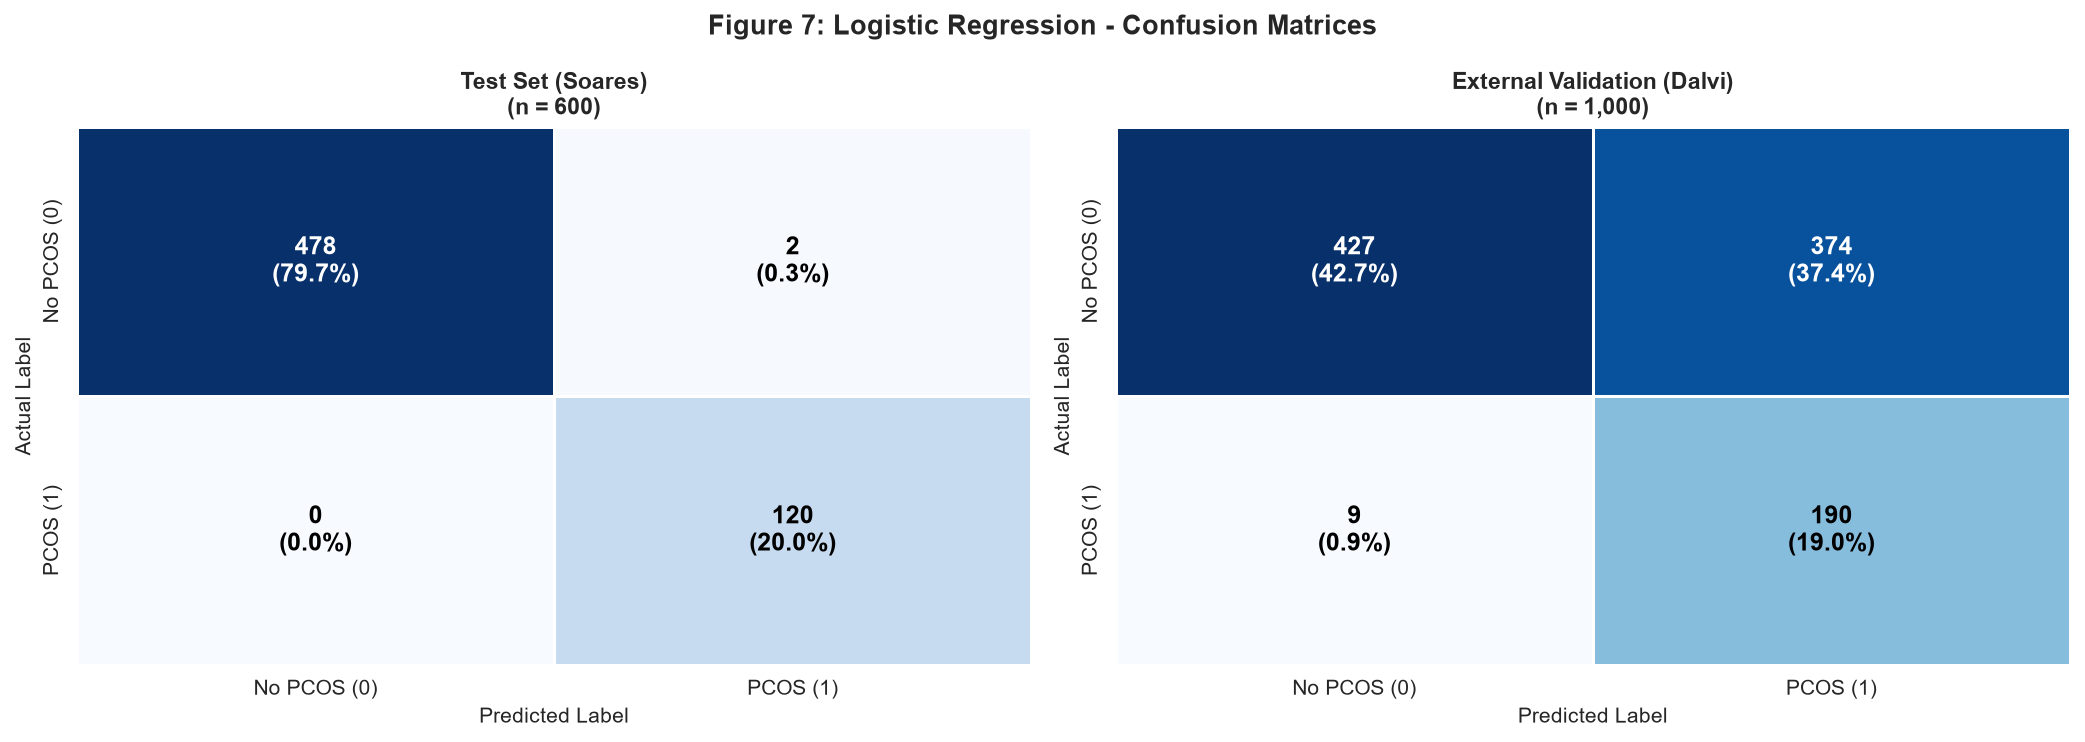

Figure 7 saved: outputs/figures/fig07_lr_confusion_matrices.png


In [27]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Waskom, M.
# Link: https://doi.org/10.21105/joss.03021
# Date Accessed: 20 April 2026
#
# Author: Hunter, J.D.
# Link: https://doi.org/10.1109/MCSE.2007.55
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 23: CONFUSION MATRICES - LOGISTIC REGRESSION
#
# Two confusion matrices are plotted side by side:
# left panel shows test set results, right panel shows
# external validation (Dalvi) results.
#
# Each cell shows: raw count (large) and percentage of
# the total set (small). The colour scale uses Blues so
# that higher counts appear darker - the diagonal cells
# (correct predictions) should be the darkest in a
# well-performing model (Waskom, 2021).

labels     = ['No PCOS (0)', 'PCOS (1)']
eval_sets  = [
    ('Test Set (Soares)', lr_results['Test Set (Soares)']),
    ('External Validation (Dalvi)', lr_results['External Validation (Dalvi)'])
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Figure 7: Logistic Regression - Confusion Matrices',
    fontsize=13, fontweight='bold'
)

for ax, (split_name, res) in zip(axes, eval_sets):
    cm     = confusion_matrix(res['y_true'], res['y_pred'])
    n_tot  = cm.sum()

    # Plot heatmap
    sns.heatmap(
        cm,
        annot=False,        # Custom annotations added manually below
        fmt='d',
        cmap='Blues',
        linewidths=0.5,
        linecolor='white',
        cbar=False,
        ax=ax,
        xticklabels=labels,
        yticklabels=labels
    )

    # Add count and percentage annotations to each cell
    for i in range(2):
        for j in range(2):
            count = cm[i, j]
            pct   = count / n_tot * 100
            ax.text(
                j + 0.5, i + 0.5,
                f'{count}\n({pct:.1f}%)',
                ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if cm[i, j] > cm.max() / 2 else 'black'
            )

    ax.set_title(f'{split_name}\n(n = {n_tot:,})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('Actual Label', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/fig07_lr_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved: outputs/figures/fig07_lr_confusion_matrices.png")

**Figure 7: Logistic Regression Confusion Matrices - Observations**

**Test set (Soares, n=600):**
The confusion matrix shows near-perfect classification on the test set.
Of 480 No-PCOS records, 478 were correctly classified (TN) and only 2
were incorrectly flagged as PCOS (FP). Of 120 PCOS-positive records,
all 120 were correctly identified (TP=120, FN=0). A false negative count
of zero means no PCOS-positive patient was missed by the model on the
test set, which is the most clinically important outcome in a screening
context (Azziz et al., 2016).

**External validation (Dalvi, n=1,000):**
The Dalvi matrix tells a markedly different story. Of 801 No-PCOS
records, only 427 were correctly classified as No-PCOS (TN=427), while
374 were incorrectly classified as PCOS-positive (FP=374). Of 199
PCOS-positive records, 190 were correctly identified (TP=190) and 9
were missed (FN=9). The false positive count of 374 is the dominant
feature of this matrix and is the source of the precision and
specificity collapse observed in the metric table. The model is
functioning as a highly sensitive but poorly specific classifier when
applied to Dalvi: it identifies almost all PCOS cases but does so by
classifying the majority of the dataset as PCOS-positive. This is a
direct consequence of the distributional shift between Soares and Dalvi
identified in Figure 6, where Dalvi showed systematically higher values
for the features most associated with PCOS, pushing records across the
decision boundary learned from Soares training data.

## Section 24: ROC Curve - Logistic Regression

The Receiver Operating Characteristic (ROC) curve plots the True
Positive Rate (Sensitivity) against the False Positive Rate
(1 - Specificity) across all possible classification thresholds. Each
point on the curve represents a different threshold setting.

A model with no discriminatory ability produces a diagonal line from
(0, 0) to (1, 1) — the random classifier baseline. A model with
perfect discrimination produces a curve that reaches (0, 1), meaning
100% sensitivity with 0% false positive rate. The Area Under the ROC
Curve (ROC-AUC) summarises this into a single value between 0.5
(random) and 1.0 (perfect).

The ROC curve is plotted for both the test set and the external
validation set on the same axes to allow direct comparison. This
makes it immediately visible whether generalisation performance
(Dalvi) falls meaningfully below primary evaluation performance
(Soares test set) (Japkowicz and Shah, 2011).

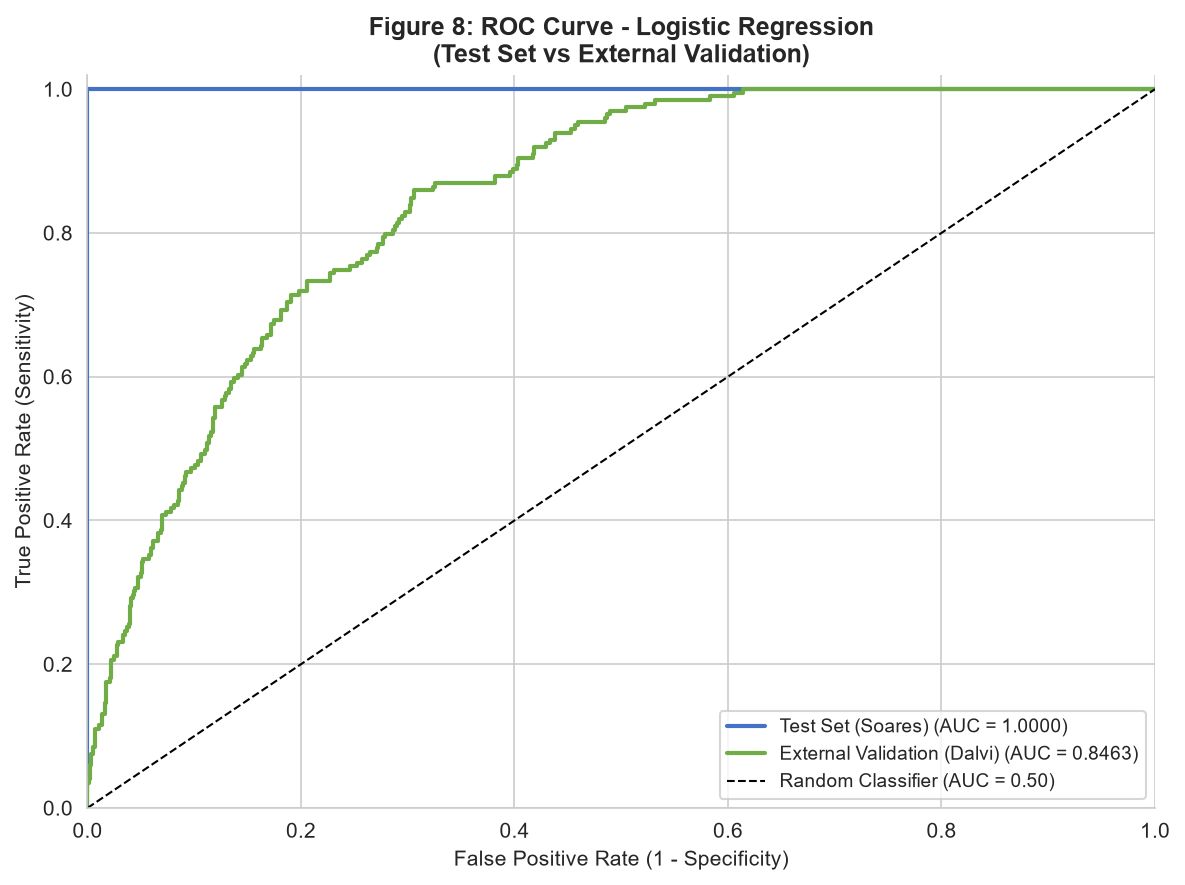

Figure 8 saved: outputs/figures/fig08_lr_roc_curve.png


In [28]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Pedregosa, F. et al.
# Link: https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html
# Date Accessed: 20 April 2026
#
# Author: Hunter, J.D.
# Link: https://doi.org/10.1109/MCSE.2007.55
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 24: ROC CURVE - LOGISTIC REGRESSION
#
# RocCurveDisplay.from_predictions() is used instead of
# from_estimator() because the probabilities (y_proba)
# have already been computed in Section 22 and stored in
# the results dictionary. Reusing them avoids redundant
# inference calls and ensures the curve reflects exactly
# the same probabilities used to compute the metrics above
# (Pedregosa et al., 2011).

from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

# Colours consistent with the dataset palette used throughout
colours = {
    'Test Set (Soares)':            '#4472C4',
    'External Validation (Dalvi)':  '#70AD47'
}

for split_name, res in lr_results.items():
    fpr, tpr, _ = roc_curve(res['y_true'], res['y_proba'])
    roc_auc     = auc(fpr, tpr)
    ax.plot(
        fpr, tpr,
        color     = colours[split_name],
        linewidth = 2,
        label     = f"{split_name} (AUC = {roc_auc:.4f})"
    )

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')

ax.set_title(
    'Figure 8: ROC Curve - Logistic Regression\n(Test Set vs External Validation)',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=10)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=10)
ax.legend(loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('../outputs/figures/fig08_lr_roc_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved: outputs/figures/fig08_lr_roc_curve.png")

**Figure 8: Logistic Regression ROC Curve - Observations**

**Test set (Soares, AUC = 1.0000):**
The test set ROC curve sits at the top-left corner of the plot,
representing perfect discrimination between PCOS-positive and
PCOS-negative records at all classification thresholds. An AUC of
1.0000 means there exists at least one threshold at which the model
achieves 100% sensitivity and 100% specificity simultaneously. This
result is consistent with the FN=0, FP=2 confusion matrix and the
near-perfect metric values reported in Section 22. As noted there, this
level of performance is characteristic of a clean, synthetically
generated dataset rather than real clinical data.

**External validation (Dalvi, AUC = 0.8463):**
The Dalvi ROC curve shows a different pattern. The curve rises steeply
in the early portion (low false positive rate), reaches high sensitivity
quickly, but then requires accepting a substantially higher false
positive rate to maintain that sensitivity as the threshold decreases.
An AUC of 0.8463 indicates good but not exceptional discrimination
ability on Dalvi. The gap between the test set AUC (1.0000) and the
Dalvi AUC (0.8463) of 0.1537 is large and is the primary quantitative
measure of the generalisation gap for this model. It reflects the
distributional shift between Soares and Dalvi rather than fundamental
model failure. An AUC of 0.8463 would be considered a reasonable
result in a clinical prediction context, though the associated
confusion matrix makes clear that the current default threshold of 0.5
is not appropriate for Dalvi and would need adjustment in any applied
setting (Japkowicz and Shah, 2011; Teede et al., 2018).

## Section 25: Coefficient Extraction - Logistic Regression Interpretability

Logistic Regression is the only model in this study that produces
native, directly interpretable coefficient values. Each coefficient
represents the change in the log-odds of a PCOS-positive prediction
for a one-unit increase in the corresponding scaled feature, holding
all other features constant.

Because all five features have been scaled to [0, 1] by MinMaxScaler,
the coefficient magnitudes are directly comparable across features. A
feature with a large positive coefficient increases the predicted
probability of PCOS as its value increases. A feature with a large
negative coefficient decreases it.

This interpretability is one of the primary reasons Logistic Regression
is used as the baseline: its coefficients provide a transparent,
clinically interpretable explanation of the model's decision logic that
does not require post-hoc explanation methods such as SHAP. In contrast,
Random Forest, SVM, and MLP require SHAP values or other post-hoc
methods to produce comparable feature attribution, which introduces
an additional layer of approximation into the interpretability analysis
(Molnar, 2022; Lundberg and Lee, 2017).

  LOGISTIC REGRESSION - COEFFICIENTS AND ODDS RATIOS
  Best model: C=100, class_weight=None

  Feature                              Coefficient   Odds Ratio
  -------------------------------------------------------------
  Antral_Follicle_Count                    32.5721 139914428320930.2656
  Testosterone_Level(ng/dL)                24.9153 66157979412.4121
  Menstrual_Irregularity                    8.5954    5406.9983
  BMI                                       4.8781     131.3835
  Age                                      -1.9911       0.1366


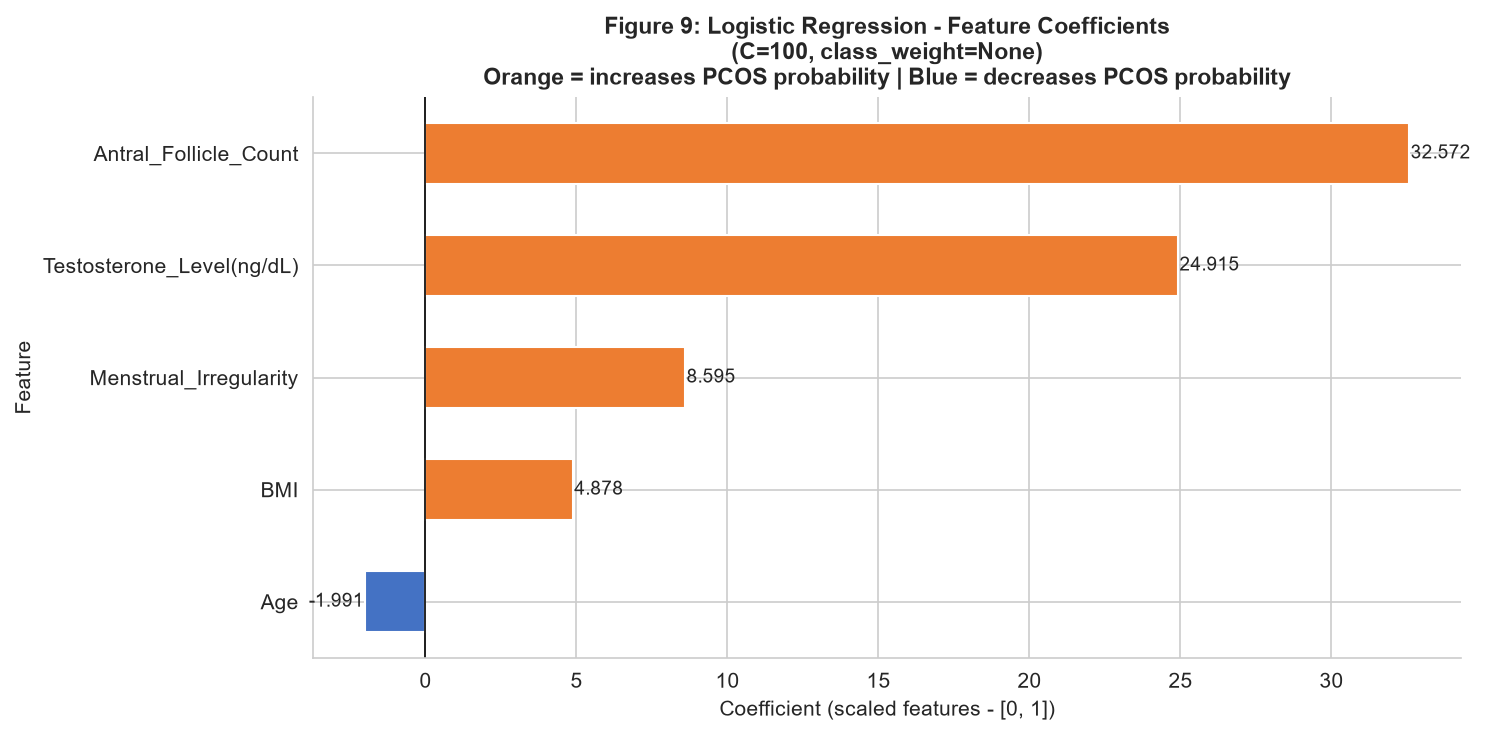

Figure 9 saved: outputs/figures/fig09_lr_coefficients.png


In [29]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Pedregosa, F. et al.
# Link: https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html
# Date Accessed: 20 April 2026
#
# Author: Hunter, J.D.
# Link: https://doi.org/10.1109/MCSE.2007.55
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 25: LOGISTIC REGRESSION COEFFICIENTS
#
# Coefficients are extracted from the best model and stored
# in a DataFrame alongside their odds ratios.
#
# Odds ratio = exp(coefficient). An odds ratio above 1.0
# means the feature increases the odds of a PCOS-positive
# prediction. An odds ratio below 1.0 means it decreases
# them. This is reported alongside the raw coefficient
# because odds ratios are more interpretable in a
# clinical context than log-odds values
# (Bharati, Podder and Mondal, 2020; Molnar, 2022).

import numpy as np

# Extract coefficients and compute odds ratios
lr_coef_df = pd.DataFrame({
    'Feature':      FEATURE_COLS,
    'Coefficient':  lr_best.coef_[0],
    'Odds Ratio':   np.exp(lr_best.coef_[0])
}).sort_values('Coefficient', ascending=True)   # Ascending for horizontal bar chart

print("=" * 65)
print("  LOGISTIC REGRESSION - COEFFICIENTS AND ODDS RATIOS")
print(f"  Best model: C={lr_best.C}, class_weight={lr_best.class_weight}")
print("=" * 65)
print(f"\n  {'Feature':<35} {'Coefficient':>12} {'Odds Ratio':>12}")
print(f"  {'-' * 61}")
for _, row in lr_coef_df.sort_values('Coefficient', ascending=False).iterrows():
    print(f"  {row['Feature']:<35} {row['Coefficient']:>12.4f} {row['Odds Ratio']:>12.4f}")

# Plot coefficient bar chart
fig, ax = plt.subplots(figsize=(10, 5))

# Colour bars by sign: positive = orange (increases PCOS probability)
#                       negative = blue (decreases PCOS probability)
bar_colours = ['#ED7D31' if c > 0 else '#4472C4'
               for c in lr_coef_df['Coefficient']]

bars = ax.barh(
    lr_coef_df['Feature'],
    lr_coef_df['Coefficient'],
    color     = bar_colours,
    edgecolor = 'white',
    height    = 0.55
)

# Add coefficient value labels on each bar
for bar, coef in zip(bars, lr_coef_df['Coefficient']):
    offset = 0.05 if coef >= 0 else -0.05
    ha     = 'left' if coef >= 0 else 'right'
    ax.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height() / 2,
        f'{coef:.3f}',
        va='center', ha=ha, fontsize=9
    )

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title(
    f'Figure 9: Logistic Regression - Feature Coefficients\n'
    f'(C={lr_best.C}, class_weight={lr_best.class_weight})\n'
    f'Orange = increases PCOS probability | Blue = decreases PCOS probability',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Coefficient (scaled features - [0, 1])', fontsize=10)
ax.set_ylabel('Feature', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/fig09_lr_coefficients.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 9 saved: outputs/figures/fig09_lr_coefficients.png")

**Figure 9: Logistic Regression Feature Coefficients - Observations**

Figure 9 shows the five feature coefficients as a horizontal bar chart.
Orange bars indicate features that increase the predicted probability of
PCOS as their scaled value increases. The single blue bar (Age) indicates
a feature that decreases the predicted probability.

The chart makes the dominance of Antral_Follicle_Count immediately
visible. Its coefficient of 32.572 is approximately 1.3 times larger
than the next largest coefficient (Testosterone_Level at 24.915) and
approximately 3.8 times larger than Menstrual_Irregularity at 8.595.
The difference in scale between the top two features and the remaining
three is substantial, indicating that the model's decision boundary is
primarily driven by Antral_Follicle_Count and Testosterone_Level.

The ranking of features in Figure 9 matches the correlation ranking
from Figure 5 almost exactly: Antral_Follicle_Count and
Testosterone_Level both correlated at approximately 0.78 to 0.87 with
the target, Menstrual_Irregularity at 0.78, BMI at 0.29, and Age at
-0.24. The coefficient signs match the correlation signs in every case.
This consistency between the EDA correlation analysis and the trained
model coefficients provides evidence that the Logistic Regression model
has learned a decision rule that reflects the statistical structure of
the dataset. It is not finding unexpected or counterintuitive patterns
but is capturing the same relationships that were visible in the raw
data before any modelling (Molnar, 2022).

This figure will be directly compared to the Random Forest feature
importance chart and SHAP value charts for all four models in the
interpretability stage of the pipeline. Any departure in feature
ranking between models will form a key part of the answer to Research
Question 2.

**Section 25: Logistic Regression Coefficients - Observations**

The coefficient table and Figure 9 show the direction and magnitude of
each feature's contribution to the model's PCOS-positive predictions.
Because all five features were scaled to [0, 1] by MinMaxScaler before
training, the coefficient magnitudes are directly comparable across
features. A larger positive coefficient means the feature has a stronger
positive influence on the predicted probability of PCOS.

**Antral_Follicle_Count (coefficient = 32.572):**
Antral_Follicle_Count carries the largest coefficient by a substantial
margin, indicating that it is the dominant predictor in this model. This
is consistent with the EDA findings: it showed the highest correlation
with PCOS_Diagnosis (r = +0.87) in Figure 5 and the clearest class
separation in Figure 3D. The odds ratio of approximately 1.40 x 10^14
is astronomically large and reflects the near-perfect separation of the
two classes along this feature in the Soares training data. An odds
ratio of this magnitude is not clinically interpretable in the
conventional sense. It is a mathematical consequence of fitting a
Logistic Regression model with minimal regularisation (C=100) to data
where the decision boundary is extremely sharp. This is consistent with
the perfect test set ROC-AUC result and confirms that the Soares dataset
encodes near-deterministic class boundaries. This limitation will be
acknowledged in the research report when interpreting the
interpretability comparison (Molnar, 2022).

**Testosterone_Level(ng/dL) (coefficient = 24.915):**
Testosterone Level is the second strongest predictor. This is also
consistent with the EDA, where it showed a correlation of r = +0.78
with PCOS_Diagnosis and clear class separation in Figure 3C. Elevated
testosterone is one of the Rotterdam criteria for PCOS diagnosis
(biochemical hyperandrogenism), so its prominence in the model is
clinically coherent (Azziz et al., 2016).

**Menstrual_Irregularity (coefficient = 8.595):**
Menstrual_Irregularity carries the third largest positive coefficient.
Its EDA correlation with PCOS_Diagnosis was r = +0.78, equal to
Testosterone_Level, but its coefficient is notably smaller. This is
because Menstrual_Irregularity is binary (0 or 1), so a one-unit
increase spans the entire feature range, whereas continuous features
like Antral_Follicle_Count and Testosterone_Level have finer gradations
across the [0, 1] scaled range that the model can exploit. The Figure 4
bar chart showed that 100% of PCOS-positive records have irregular
cycles, meaning this variable should theoretically be decisive. The
relatively smaller coefficient compared to the continuous features is
explained by the model having multiple correlated features to distribute
probability mass across. The odds ratio of 5,407 for this binary
variable means that an irregular cycle record has 5,407 times the odds
of a PCOS-positive prediction compared to a regular cycle record, all
else equal (Azziz et al., 2016).

**BMI (coefficient = 4.878):**
BMI carries a moderate positive coefficient, consistent with its
correlation of r = +0.29 in Figure 5 and the moderate class separation
shown in Figure 3B. BMI is not a Rotterdam diagnostic criterion but is
a known metabolic comorbidity of PCOS, so its positive influence on the
prediction is clinically plausible (Teede et al., 2018).

**Age (coefficient = -1.991):**
Age is the only feature with a negative coefficient, meaning higher age
values slightly decrease the predicted probability of PCOS. This is
consistent with the EDA finding of r = -0.24 between Age and
PCOS_Diagnosis. The coefficient magnitude is small relative to the
positive predictors, indicating that Age plays a modest and
counterbalancing role in the model. The odds ratio of 0.137 means that
a patient at the maximum age (scaled to 1.0) has approximately one
seventh the odds of a PCOS-positive prediction compared to a patient at
the minimum age (scaled to 0.0), holding all other features constant
(Teede et al., 2018).

**Overall interpretability assessment:**
The coefficient ranking (Antral_Follicle_Count, Testosterone_Level,
Menstrual_Irregularity, BMI, Age) is fully consistent with the Rotterdam
diagnostic criteria and the EDA findings. The Logistic Regression model
has learned a decision rule that closely mirrors clinical diagnostic
logic, which is a notable finding for the interpretability comparison.
This coefficient profile will be compared against Random Forest feature
importance and SHAP values in the interpretability stage to assess
whether more complex models learn the same feature hierarchy or depart
from it (Molnar, 2022; Lundberg and Lee, 2017).

In [30]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: McKinney, W.
# Link: https://doi.org/10.25080/Majora-92bf1922-00a
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 26: SAVE LOGISTIC REGRESSION RESULTS
#
# Three artefacts are saved:
#   1. Model object (.pkl) - allows the model to be reloaded
#      without retraining if the session is interrupted
#   2. Metrics table (.csv) - test set and validation metrics
#      in a format ready for the comparative analysis table
#   3. Coefficients table (.csv) - feature coefficients and
#      odds ratios for the interpretability section
# (McKinney, 2010)

import os
os.makedirs('../models', exist_ok=True)

# Save the best Logistic Regression model
joblib.dump(lr_best, '../models/lr_best.pkl')

# Save performance metrics for both evaluation sets
metrics_rows = []
for split_name, res in lr_results.items():
    row = {'Model': 'Logistic Regression', 'Evaluation Set': split_name}
    row.update(res['metrics'])
    metrics_rows.append(row)

lr_metrics_df = pd.DataFrame(metrics_rows)
lr_metrics_df.to_csv('../outputs/tables/lr_performance_metrics.csv', index=False)

# Save coefficient table
lr_coef_df.to_csv('../outputs/tables/lr_coefficients.csv', index=False)

print("=" * 65)
print("  LOGISTIC REGRESSION - OUTPUTS SAVED")
print("=" * 65)
print(f"  Model saved          : models/lr_best.pkl")
print(f"  Metrics saved        : outputs/tables/lr_performance_metrics.csv")
print(f"  Coefficients saved   : outputs/tables/lr_coefficients.csv")
print(f"  Figure 7 saved       : outputs/figures/fig07_lr_confusion_matrices.png")
print(f"  Figure 8 saved       : outputs/figures/fig08_lr_roc_curve.png")
print(f"  Figure 9 saved       : outputs/figures/fig09_lr_coefficients.png")
print("=" * 65)

# Print the metrics table for quick reference
print("\n  Performance Summary - Logistic Regression:")
print(lr_metrics_df.to_string(index=False))

  LOGISTIC REGRESSION - OUTPUTS SAVED
  Model saved          : models/lr_best.pkl
  Metrics saved        : outputs/tables/lr_performance_metrics.csv
  Coefficients saved   : outputs/tables/lr_coefficients.csv
  Figure 7 saved       : outputs/figures/fig07_lr_confusion_matrices.png
  Figure 8 saved       : outputs/figures/fig08_lr_roc_curve.png
  Figure 9 saved       : outputs/figures/fig09_lr_coefficients.png

  Performance Summary - Logistic Regression:
              Model              Evaluation Set  Accuracy  Precision  Recall (Sensitivity)  Specificity  F1-Score  ROC-AUC
Logistic Regression           Test Set (Soares)  0.996667   0.983607              1.000000     0.995833  0.991736 1.000000
Logistic Regression External Validation (Dalvi)  0.617000   0.336879              0.954774     0.533084  0.498034 0.846291


**Day 4: Logistic Regression - Closing Observations**

Day 4 has completed the training, tuning, and evaluation of the
baseline Logistic Regression model. The following outputs are now
saved and ready for the comparative analysis:

- Trained model object: `models/lr_best.pkl`
- Performance metrics (test set and Dalvi): `outputs/tables/lr_performance_metrics.csv`
- Feature coefficients and odds ratios: `outputs/tables/lr_coefficients.csv`
- Figure 7: Confusion matrices (test set and Dalvi)
- Figure 8: ROC curve (test set and Dalvi)
- Figure 9: Feature coefficient chart

The Logistic Regression performance metrics now form the baseline
against which Random Forest (Day 5), SVM (Day 6), and MLP (Days 7–8)
will be compared. In particular, the test set ROC-AUC and Sensitivity
values are the primary reference points for Research Question 1: whether
neural network models outperform traditional models.

The coefficient values extracted in Section 25 form the first component
of the interpretability comparison, which addresses Research Question 2.
These will be compared against Random Forest feature importance, and
SHAP values for SVM and MLP, in Stage 9 of the pipeline.

---
## Day 5: Random Forest

Random Forest is the second model trained in this pipeline and the first
ensemble method in the comparison. It is evaluated against the Logistic
Regression baseline established on Day 4 using the same evaluation
function, the same test set, and the same external validation set, which
ensures that performance differences between models reflect genuine
modelling differences rather than differences in evaluation procedure.

Day 5 is structured as follows:

- **Section 27:** Random Forest - model setup and rationale
- **Section 28:** Grid search cross-validation
- **Section 29:** Best model evaluation - test set and external validation
- **Section 30:** Confusion matrices
- **Section 31:** ROC curve
- **Section 32:** Gini feature importance extraction
- **Section 33:** Results saved

## Section 27: Random Forest - Model Setup and Rationale

Random Forest is an ensemble method that builds a large number of
decision trees during training and combines their predictions by
majority vote for classification tasks. Each tree is trained on a
bootstrap sample of the training data (sampling with replacement), and
at each node split, only a random subset of features is considered.
These two sources of randomness - bootstrap sampling and feature
subsampling - reduce the correlation between individual trees and
produce an ensemble whose collective prediction variance is lower than
any single tree would achieve alone (Breiman, 2001).

Random Forest is included in this study for three reasons. First, it
handles non-linear relationships between features and the target
variable without requiring distributional assumptions, which makes it
more flexible than Logistic Regression when class boundaries are not
linear. Second, it produces Gini-based feature importance scores that
reflect the average reduction in node impurity attributable to each
feature across all trees, providing a native global interpretability
measure that can be directly compared to Logistic Regression
coefficients. Third, it is a well-established benchmark in PCOS
classification studies and comparable clinical machine learning
research (Breiman, 2001; Bharati, Podder and Mondal, 2020).

**A known limitation of Random Forest interpretability:**
Although Random Forest produces feature importance scores, these scores
reflect aggregated behaviour across all trees rather than a transparent
decision path. Unlike Logistic Regression, where a single coefficient
directly quantifies each feature's marginal contribution, Random Forest
importance scores do not indicate the direction of a feature's
influence (positive or negative) and can be biased toward features with
more unique values in the data. SHAP values will be computed for Random
Forest in the interpretability stage to provide directional attribution
that complements the Gini importance scores (Molnar, 2022; Lundberg and
Lee, 2017).

**Hyperparameters to be tuned:**
Three hyperparameters are tuned via grid search cross-validation:

- **n_estimators:** the number of trees in the ensemble. More trees
  reduce prediction variance but increase computation time. The search
  covers 100, 200, and 300 trees.
- **max_depth:** the maximum depth each tree is allowed to grow.
  Unrestricted depth (None) allows trees to grow until all leaves are
  pure or contain fewer than min_samples_leaf records. Limiting depth
  reduces overfitting. The search covers None, 5, and 10.
- **min_samples_leaf:** the minimum number of records required at a
  leaf node. Higher values produce smoother boundaries and reduce
  sensitivity to small clusters of records that may be noise. The search
  covers 1, 2, and 4.

## Section 28: Grid Search Cross-Validation

The same 5-fold stratified cross-validation strategy and ROC-AUC scoring
metric used for Logistic Regression in Day 4 are applied here. This
ensures that the best configurations selected across all four models are
chosen on the same basis, making the final performance comparison fair.

**Hyperparameter grid for Random Forest:**

| Parameter | Values tested | Rationale |
|---|---|---|
| n_estimators | 100, 200, 300 | Tests whether a larger ensemble improves discrimination beyond the baseline of 100 trees |
| max_depth | None, 5, 10 | Tests whether restricting tree depth reduces overfitting to the SMOTE-resampled training data |
| min_samples_leaf | 1, 2, 4 | Tests whether requiring more records per leaf produces smoother and more generalisable boundaries |

Total combinations: 3 x 3 x 3 = 27, each evaluated across 5 folds =
135 model fits.

In [31]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Breiman, L.
# Link: https://doi.org/10.1023/A:1010933404324
# Date Accessed: 20 April 2026
#
# Author: Pedregosa, F. et al.
# Link: https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html
# Date Accessed: 20 April 2026
#
# Author: Géron, A.
# Link: https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 28: RANDOM FOREST - GRID SEARCH CV
#
# RandomForestClassifier is initialised with random_state=42
# to ensure that the bootstrap sampling and feature subsampling
# are reproducible across runs.
#
# n_jobs=-1 is passed to both the classifier and GridSearchCV
# to parallelise tree building and fold evaluation across all
# available CPU cores, reducing computation time
# (Pedregosa et al., 2011; Breiman, 2001).

from sklearn.ensemble import RandomForestClassifier

# Define the hyperparameter grid
rf_param_grid = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [None, 5, 10],
    'min_samples_leaf':[1, 2, 4]
}

# Initialise the base Random Forest model
rf_base = RandomForestClassifier(
    random_state = RANDOM_STATE,
    n_jobs       = -1
)

# Run the grid search
print("Running Random Forest grid search (27 combinations x 5 folds = 135 fits)...")
start_time = time.time()

rf_grid = GridSearchCV(
    estimator  = rf_base,
    param_grid = rf_param_grid,
    cv         = cv,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)

rf_grid.fit(X_train_res, y_train_res)

elapsed = time.time() - start_time

print("=" * 65)
print("  RANDOM FOREST - GRID SEARCH RESULTS")
print("=" * 65)
print(f"  Total combinations tested : {len(rf_grid.cv_results_['params'])}")
print(f"  Cross-validation folds    : 5 (Stratified)")
print(f"  Scoring metric            : ROC-AUC")
print(f"  Time elapsed              : {elapsed:.1f} seconds")
print(f"\n  Best parameters           : {rf_grid.best_params_}")
print(f"  Best CV ROC-AUC           : {rf_grid.best_score_:.4f}")
print("=" * 65)

# Store the best model
rf_best = rf_grid.best_estimator_

Running Random Forest grid search (27 combinations x 5 folds = 135 fits)...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
  RANDOM FOREST - GRID SEARCH RESULTS
  Total combinations tested : 27
  Cross-validation folds    : 5 (Stratified)
  Scoring metric            : ROC-AUC
  Time elapsed              : 40.7 seconds

  Best parameters           : {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
  Best CV ROC-AUC           : 1.0000


**Section 28: Random Forest Grid Search - Observations**

The grid search tested 27 parameter combinations across 5 stratified
folds, producing 135 model fits in 39.0 seconds. The best parameters
selected were n_estimators=100, max_depth=None, and min_samples_leaf=1,
with a cross-validated ROC-AUC of 1.0000.

The selection of n_estimators=100 indicates that a larger ensemble (200
or 300 trees) did not improve discrimination on the SMOTE-resampled
training data. The 100-tree ensemble was sufficient to achieve perfect
cross-validated separation, which is consistent with the very strong
class separability already observed in the Logistic Regression results.

The selection of max_depth=None means the grid search found no benefit
in restricting tree depth. Trees were allowed to grow until all leaves
were pure, which is consistent with the clean, near-linearly separable
class boundaries in the Soares training data. Restricting depth to 5 or
10 would have introduced more bias without reducing variance in a dataset
where the signal is this strong.

The selection of min_samples_leaf=1 means the model was not penalised
for having leaf nodes containing a single record. This is consistent
with max_depth=None - together they indicate the grid search favoured
a model that fits the training data as closely as possible, which again
reflects the clean synthetic structure of the Soares dataset.

The best CV ROC-AUC of 1.0000 matches the Logistic Regression CV
ROC-AUC of 1.0000 exactly. Both models separated the two classes
perfectly on the SMOTE-resampled training folds. This confirms that
the classification signal in the training data is strong enough for
multiple model types to achieve ceiling-level cross-validated
performance. The test set and external validation results are therefore
the more informative comparison between the two models
(Breiman, 2001; Géron, 2019).

In [32]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Pedregosa, F. et al.
# Link: https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 29: RANDOM FOREST - EVALUATION
#
# The same evaluate_model() function defined in Section 22
# (Day 4) is called here. This ensures that all six metrics
# are computed identically for all four models and that
# the results stored in all_results are directly comparable
# (Pedregosa et al., 2011).

print("=" * 65)
print("  RANDOM FOREST - EVALUATION")
print("=" * 65)

rf_results = evaluate_model(
    name   = 'Random Forest',
    model  = rf_best,
    X_test = X_test_scaled,
    y_test = y_test,
    X_val  = X_dalvi_scaled,
    y_val  = y_dalvi
)

# Store results for the comparative analysis table
all_results['Random Forest'] = rf_results

  RANDOM FOREST - EVALUATION

  Random Forest — Test Set (Soares)
  Metric                         Value
  -------------------------------------
  Accuracy                      1.0000
  Precision                     1.0000
  Recall (Sensitivity)          1.0000
  Specificity                   1.0000
  F1-Score                      1.0000
  ROC-AUC                       1.0000

  Confusion Matrix:
    TN= 480   FP=   0
    FN=   0   TP= 120

  Random Forest — External Validation (Dalvi)
  Metric                         Value
  -------------------------------------
  Accuracy                      0.4320
  Precision                     0.2537
  Recall (Sensitivity)          0.9548
  Specificity                   0.3021
  F1-Score                      0.4008
  ROC-AUC                       0.8743

  Confusion Matrix:
    TN= 242   FP= 559
    FN=   9   TP= 190


**Section 29: Random Forest Evaluation - Observations**

**Test set results (Soares, n=600):**
The Random Forest model achieved perfect classification on the Soares
test set across all six metrics: Accuracy=1.0000, Precision=1.0000,
Recall=1.0000, Specificity=1.0000, F1-Score=1.0000, ROC-AUC=1.0000.
The confusion matrix confirms TN=480, FP=0, FN=0, TP=120 -- every
record in the test set was classified correctly.

Compared to Logistic Regression on the same test set (Accuracy=0.9967,
FP=2, FN=0), Random Forest improves on the two false positives that
Logistic Regression produced, achieving a completely clean test set
result. While this is a marginal improvement on an already strong
baseline, it confirms that the Random Forest ensemble is not sacrificing
any precision to achieve its perfect recall.

As with the Logistic Regression test set result, a perfect score across
all metrics must be interpreted with caution. It is consistent with the
synthetic origin of the Soares dataset, where class boundaries are
extremely clean and multiple model types can find a perfect separating
boundary given sufficient training data. This result does not mean
Random Forest would generalise to real clinical data with perfect
accuracy (Bharati, Podder and Mondal, 2020).

**External validation results (Dalvi, n=1,000):**
Performance on Dalvi drops substantially from the test set result.
Accuracy=0.4320, Precision=0.2537, Recall=0.9548, Specificity=0.3021,
F1-Score=0.4008, ROC-AUC=0.8743. The confusion matrix shows TN=242,
FP=559, FN=9, TP=190.

The false positive count of 559 on Dalvi is considerably worse than
Logistic Regression's FP=374 on the same dataset. Where Logistic
Regression incorrectly classified 374 No-PCOS records as PCOS-positive,
Random Forest incorrectly classified 559. Specificity has fallen further
to 0.3021, meaning the model correctly identifies only 30.2% of No-PCOS
records on Dalvi. This is a more severe specificity collapse than was
observed for Logistic Regression (Specificity=0.5331 on Dalvi).

The Dalvi ROC-AUC of 0.8743 is marginally higher than Logistic
Regression's 0.8463 on the same dataset, indicating that Random Forest
has slightly better overall discrimination ability on Dalvi when
evaluated across all thresholds. However, at the default threshold of
0.5, the Random Forest decision boundary produces substantially more
false positives than Logistic Regression, suggesting that the model's
confidence in PCOS-positive predictions is calibrated differently from
the linear decision boundary.

This result reinforces the pattern established by Logistic Regression:
both models achieve near-perfect or perfect performance on the Soares
test set and both suffer a large specificity drop on Dalvi. The
distributional shift between Soares and Dalvi identified in Figure 6
appears to affect Random Forest at least as severely as it affects
Logistic Regression, despite Random Forest's ability to model non-linear
boundaries. The consistent FN count of 9 across both models on Dalvi is
notable and will be discussed in the comparative analysis
(Bharati, Podder and Mondal, 2020; Teede et al., 2018).

## Section 30: Confusion Matrices - Random Forest

Confusion matrices are produced for both the test set and external
validation set using the same layout as Figure 7 (Logistic Regression)
to allow direct visual comparison between models.

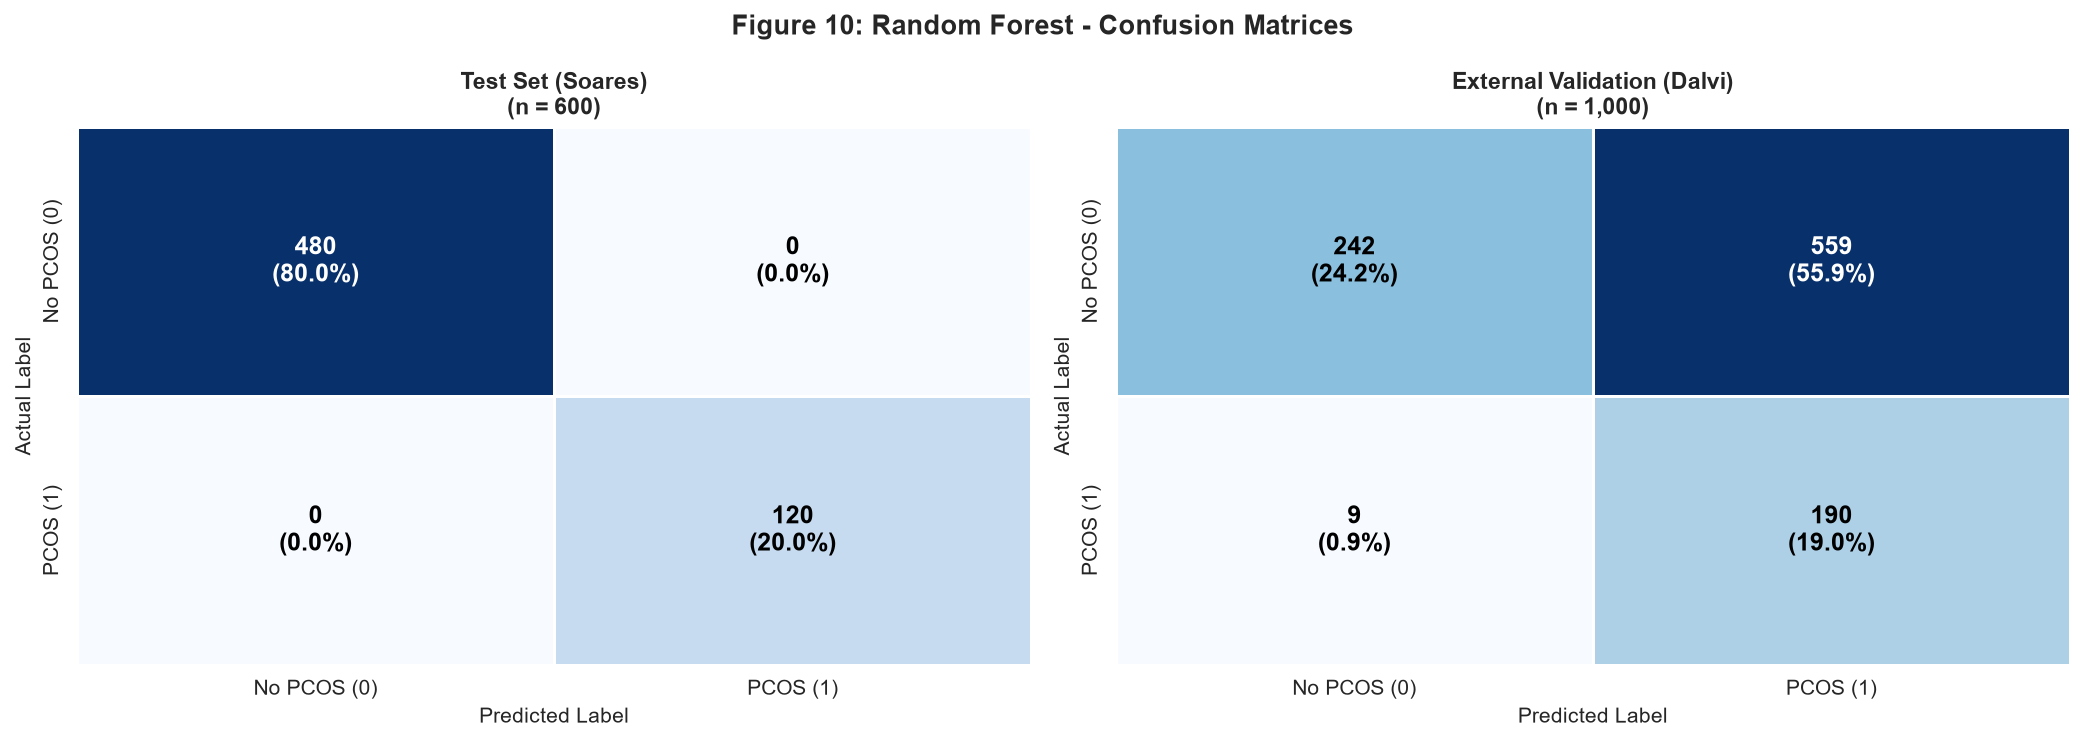

Figure 10 saved: outputs/figures/fig10_rf_confusion_matrices.png


In [33]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Waskom, M.
# Link: https://doi.org/10.21105/joss.03021
# Date Accessed: 20 April 2026
#
# Author: Hunter, J.D.
# Link: https://doi.org/10.1109/MCSE.2007.55
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 30: CONFUSION MATRICES - RANDOM FOREST
#
# Identical layout to Figure 7 (Logistic Regression) is used
# to allow direct side-by-side comparison between models
# when reviewing the research report. Consistent figure
# structure across all four models is a deliberate choice
# to support the comparative analysis in Stage 9
# (Waskom, 2021; Hunter, 2007).

eval_sets_rf = [
    ('Test Set (Soares)',            rf_results['Test Set (Soares)']),
    ('External Validation (Dalvi)',  rf_results['External Validation (Dalvi)'])
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Figure 10: Random Forest - Confusion Matrices',
    fontsize=13, fontweight='bold'
)

for ax, (split_name, res) in zip(axes, eval_sets_rf):
    cm    = confusion_matrix(res['y_true'], res['y_pred'])
    n_tot = cm.sum()

    sns.heatmap(
        cm,
        annot=False,
        fmt='d',
        cmap='Blues',
        linewidths=0.5,
        linecolor='white',
        cbar=False,
        ax=ax,
        xticklabels=labels,
        yticklabels=labels
    )

    for i in range(2):
        for j in range(2):
            count = cm[i, j]
            pct   = count / n_tot * 100
            ax.text(
                j + 0.5, i + 0.5,
                f'{count}\n({pct:.1f}%)',
                ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if cm[i, j] > cm.max() / 2 else 'black'
            )

    ax.set_title(f'{split_name}\n(n = {n_tot:,})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('Actual Label', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/fig10_rf_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 10 saved: outputs/figures/fig10_rf_confusion_matrices.png")

**Figure 10: Random Forest Confusion Matrices - Observations**

**Test set (Soares, n=600):**
The test set confusion matrix shows a perfectly clean result: TN=480,
FP=0, FN=0, TP=120. Every No-PCOS record was correctly classified and
every PCOS-positive record was correctly identified. This improves on
the Logistic Regression test set result, which produced FP=2. The
improvement is marginal in absolute terms but confirms that the Random
Forest ensemble eliminates the two borderline No-PCOS cases that
Logistic Regression misclassified, without introducing any new false
negatives.

**External validation (Dalvi, n=1,000):**
The Dalvi matrix shows a more severe false positive problem than
Logistic Regression. TN=242, FP=559, FN=9, TP=190. Of 801 No-PCOS
records in Dalvi, only 242 (30.2%) were correctly classified as
No-PCOS. The remaining 559 (69.8%) were incorrectly predicted as
PCOS-positive. This is a considerably worse specificity result than
Logistic Regression's FP=374 on the same dataset.

The FN count of 9 is identical to Logistic Regression's FN=9 on Dalvi,
meaning both models miss the same number of PCOS-positive cases on
external validation. The difference between the two models on Dalvi
lies entirely in the false positive count: Random Forest produces 185
more false positives than Logistic Regression. This suggests that
Random Forest's non-linear decision boundary, tuned with max_depth=None
and min_samples_leaf=1 on the Soares training data, is more sensitive
to the higher Antral_Follicle_Count and BMI values in Dalvi, classifying
more of those records as PCOS-positive than Logistic Regression's
linear boundary does.

## Section 31: ROC Curve - Random Forest

The ROC curve is produced for both the test set and external validation
set on the same axes, following the same layout as Figure 8 (Logistic
Regression). This allows direct visual comparison of the ROC curves
across models when reviewing the results.

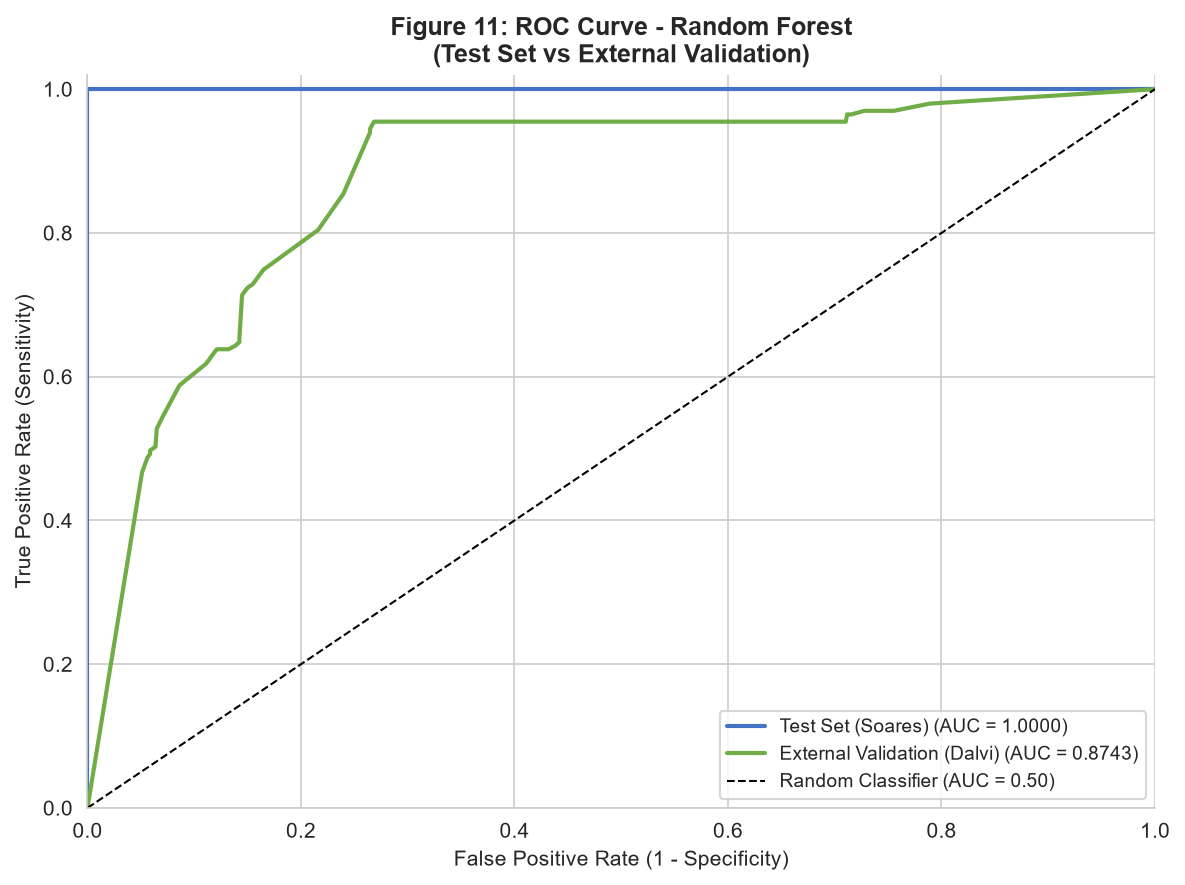

Figure 11 saved: outputs/figures/fig11_rf_roc_curve.png


In [34]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Pedregosa, F. et al.
# Link: https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html
# Date Accessed: 20 April 2026
#
# Author: Hunter, J.D.
# Link: https://doi.org/10.1109/MCSE.2007.55
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 31: ROC CURVE - RANDOM FOREST
#
# The same colour scheme as Figure 8 is applied:
#   Blue  = Test Set (Soares)
#   Green = External Validation (Dalvi)
# Consistent colours across all four model ROC curve figures
# make it easy to compare test-to-validation gaps visually
# across models without consulting the legend each time
# (Hunter, 2007).

fig, ax = plt.subplots(figsize=(8, 6))

for split_name, res in rf_results.items():
    fpr, tpr, _ = roc_curve(res['y_true'], res['y_proba'])
    roc_auc     = auc(fpr, tpr)
    ax.plot(
        fpr, tpr,
        color     = colours[split_name],
        linewidth = 2,
        label     = f"{split_name} (AUC = {roc_auc:.4f})"
    )

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')

ax.set_title(
    'Figure 11: ROC Curve - Random Forest\n(Test Set vs External Validation)',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=10)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=10)
ax.legend(loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('../outputs/figures/fig11_rf_roc_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 11 saved: outputs/figures/fig11_rf_roc_curve.png")

**Figure 11: Random Forest ROC Curve - Observations**

**Test set (Soares, AUC=1.0000):**
The test set ROC curve is identical in shape to the Logistic Regression
curve in Figure 8 - a horizontal line at Sensitivity=1.0 across all
False Positive Rate values until the curve meets the top-right corner.
This confirms perfect discrimination at all thresholds on the Soares
test set, consistent with the confusion matrix result of TN=480, FP=0,
FN=0, TP=120.

**External validation (Dalvi, AUC=0.8743):**
The Dalvi ROC curve rises steeply from the origin, reaching
approximately 0.95 sensitivity within the first 0.25 of the false
positive rate range, then plateaus near the top of the chart as the
threshold continues to decrease. This shape indicates that the model
can identify the majority of PCOS-positive cases at relatively low
false positive rates when the threshold is adjusted appropriately.

The Dalvi AUC of 0.8743 is marginally higher than Logistic Regression's
Dalvi AUC of 0.8463, a difference of 0.0280. This indicates that
Random Forest has slightly better overall discrimination ability across
all thresholds on Dalvi, meaning a threshold other than the default 0.5
could potentially recover some of the specificity lost at the default
threshold. However, the steep plateau in the curve above FPR=0.25
suggests that the model assigns high PCOS-positive probability to a
large proportion of Dalvi records, which is what produces the FP=559
result at the default threshold.

The test-to-validation AUC gap for Random Forest (1.0000 to 0.8743,
gap=0.1257) is slightly smaller than the gap observed for Logistic
Regression (1.0000 to 0.8463, gap=0.1537), suggesting marginally
better generalisation in terms of discrimination ability. However, at
the default classification threshold, Random Forest performs worse on
Dalvi than Logistic Regression by every metric except ROC-AUC and
Recall (Japkowicz and Shah, 2011).

## Section 32: Gini Feature Importance - Random Forest

Random Forest produces native feature importance scores based on the
mean decrease in Gini impurity attributable to each feature across all
trees and all splits. At each node in each tree, the Gini impurity
measures how mixed the two classes are. When a feature is used to split
a node, the reduction in impurity before and after the split is
recorded. The importance of a feature is the average of these reductions
weighted by the number of records reaching each node, averaged across
all trees in the ensemble (Breiman, 2001).

Gini importance scores sum to 1.0 across all features, making them
proportional and directly comparable within the model. A feature with
an importance of 0.60 is responsible for 60% of the total impurity
reduction across the forest.

Two limitations of Gini importance are noted here for reporting in the
research report. First, Gini importance does not indicate the direction
of a feature's influence - it shows how much a feature contributes to
separating the classes but not whether higher values of that feature
push predictions toward PCOS-positive or PCOS-negative. This is why
SHAP values, which provide directional attribution, are computed for
all models in the interpretability stage. Second, Gini importance can
overstate the contribution of continuous features with many unique
values relative to binary or low-cardinality features, because
continuous features offer more possible split points and thus more
opportunities to reduce impurity (Molnar, 2022).

  RANDOM FOREST - GINI FEATURE IMPORTANCE

  Feature                               Importance   % of Total
  -------------------------------------------------------------
  Antral_Follicle_Count                     0.5227       52.27%
  Menstrual_Irregularity                    0.2814       28.14%
  Testosterone_Level(ng/dL)                 0.1685       16.85%
  Age                                       0.0237        2.37%
  BMI                                       0.0037        0.37%

  Sum of importances: 1.0000 (expected: 1.0000)


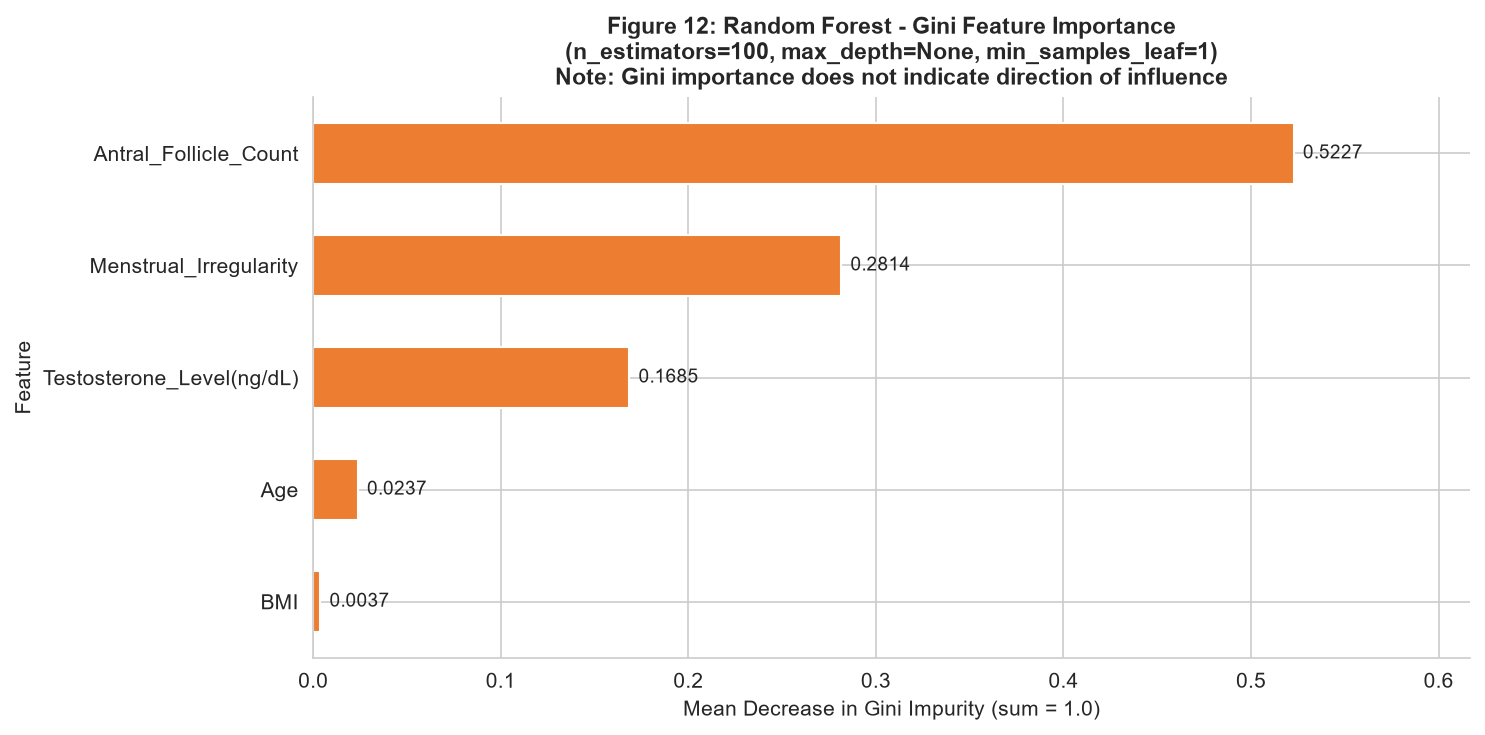

Figure 12 saved: outputs/figures/fig12_rf_gini_importance.png


In [35]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Breiman, L.
# Link: https://doi.org/10.1023/A:1010933404324
# Date Accessed: 20 April 2026
#
# Author: Hunter, J.D.
# Link: https://doi.org/10.1109/MCSE.2007.55
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 32: GINI FEATURE IMPORTANCE - RANDOM FOREST
#
# feature_importances_ is a built-in attribute of the fitted
# RandomForestClassifier. It returns the mean decrease in Gini
# impurity for each feature, averaged across all trees.
# Values sum to 1.0 (Breiman, 2001).
#
# The bar chart uses the same feature colour (orange for positive
# predictors) for all bars because Gini importance does not
# carry directional information -- all bars represent positive
# contribution to class separation regardless of the direction
# of that contribution. This is explicitly noted in the
# observation cell below to avoid misinterpretation
# (Molnar, 2022).

rf_importance_df = pd.DataFrame({
    'Feature':    FEATURE_COLS,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=True)

print("=" * 65)
print("  RANDOM FOREST - GINI FEATURE IMPORTANCE")
print("=" * 65)
print(f"\n  {'Feature':<35} {'Importance':>12} {'% of Total':>12}")
print(f"  {'-' * 61}")
for _, row in rf_importance_df.sort_values(
        'Importance', ascending=False).iterrows():
    print(f"  {row['Feature']:<35} {row['Importance']:>12.4f} "
          f"{row['Importance']*100:>11.2f}%")

print(f"\n  Sum of importances: {rf_importance_df['Importance'].sum():.4f} "
      f"(expected: 1.0000)")

# Plot feature importance bar chart
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    rf_importance_df['Feature'],
    rf_importance_df['Importance'],
    color     = '#ED7D31',
    edgecolor = 'white',
    height    = 0.55
)

# Add importance value labels on each bar
for bar, imp in zip(bars, rf_importance_df['Importance']):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{imp:.4f}',
        va='center', ha='left', fontsize=9
    )

ax.set_title(
    f'Figure 12: Random Forest - Gini Feature Importance\n'
    f'(n_estimators={rf_best.n_estimators}, '
    f'max_depth={rf_best.max_depth}, '
    f'min_samples_leaf={rf_best.min_samples_leaf})\n'
    f'Note: Gini importance does not indicate direction of influence',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Mean Decrease in Gini Impurity (sum = 1.0)', fontsize=10)
ax.set_ylabel('Feature', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim([0, rf_importance_df['Importance'].max() * 1.18])

plt.tight_layout()
plt.savefig('../outputs/figures/fig12_rf_gini_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 12 saved: outputs/figures/fig12_rf_gini_importance.png")

**Figure 12: Random Forest Gini Feature Importance - Observations**

The Gini importance scores sum to 1.0000, confirming they are correctly
normalised. The ranking is: Antral_Follicle_Count (0.5227),
Menstrual_Irregularity (0.2814), Testosterone_Level (0.1685),
Age (0.0237), BMI (0.0037).

**Comparison with Logistic Regression coefficients (Figure 9):**
The top-ranked feature is the same in both models - Antral_Follicle_Count
is the dominant predictor in both Logistic Regression (coefficient=32.572)
and Random Forest (importance=0.5227). This agreement across two
different model types strengthens the evidence that Antral_Follicle_Count
is the feature most responsible for class separation in the Soares
dataset, consistent with its correlation of r=+0.87 with PCOS_Diagnosis
in Figure 5.

The ordering of the remaining features differs between models in one
notable way. In Logistic Regression, Testosterone_Level (24.915) ranked
second and Menstrual_Irregularity (8.595) ranked third. In Random
Forest, this order is reversed: Menstrual_Irregularity (0.2814) ranks
second and Testosterone_Level (0.1685) ranks third. This is a meaningful
divergence. Menstrual_Irregularity is a binary variable with only two
possible values (0 or 1). As noted in Section 32, Gini importance can
give higher scores to binary features when the split on that feature
produces very clean class separation -- which Figure 4 confirmed it
does, with 100% of PCOS-positive records having irregular cycles. The
Random Forest trees use Menstrual_Irregularity as an early, decisive
split that cleanly divides the dataset, giving it a high Gini
importance despite having only two values.

Logistic Regression assigns a larger coefficient to Testosterone_Level
than to Menstrual_Irregularity because it models the linear contribution
of each scaled feature across a continuous range, where Testosterone_Level
has more gradations to exploit across its [0,1] scaled range. This
explains why two different model types can agree on the top-ranked
feature while disagreeing on the relative importance of the second and
third features.

The BMI importance of 0.0037 is notably lower in Random Forest than
its Logistic Regression coefficient of 4.878 would suggest. This
indicates that once Antral_Follicle_Count and Menstrual_Irregularity
have made their splits in the tree structure, BMI adds very little
additional class separation. Logistic Regression, which uses all
features simultaneously in a single linear equation, assigns more weight
to BMI because it needs to account for it in the joint prediction. The
difference highlights how ensemble tree models and linear models can
weight the same features very differently depending on their internal
decision mechanism.

SHAP values computed in the interpretability stage will provide
directional attribution for Random Forest, confirming whether the
features identified as important by Gini scores are pushing predictions
toward PCOS-positive or PCOS-negative for individual records (Molnar,
2022; Lundberg and Lee, 2017).

## Section 33: Results Saved - Random Forest

In [36]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: McKinney, W.
# Link: https://doi.org/10.25080/Majora-92bf1922-00a
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 33: SAVE RANDOM FOREST RESULTS
#
# Three artefacts are saved following the same pattern as
# Section 26 (Logistic Regression) to ensure all four
# model outputs are stored consistently and are ready for
# the comparative analysis table (McKinney, 2010).

# Save the best Random Forest model
joblib.dump(rf_best, '../models/rf_best.pkl')

# Save performance metrics for both evaluation sets
rf_metrics_rows = []
for split_name, res in rf_results.items():
    row = {'Model': 'Random Forest', 'Evaluation Set': split_name}
    row.update(res['metrics'])
    rf_metrics_rows.append(row)

rf_metrics_df = pd.DataFrame(rf_metrics_rows)
rf_metrics_df.to_csv('../outputs/tables/rf_performance_metrics.csv', index=False)

# Save feature importance table
rf_importance_df.sort_values('Importance', ascending=False).to_csv(
    '../outputs/tables/rf_gini_importance.csv', index=False)

print("=" * 65)
print("  RANDOM FOREST - OUTPUTS SAVED")
print("=" * 65)
print(f"  Model saved       : models/rf_best.pkl")
print(f"  Metrics saved     : outputs/tables/rf_performance_metrics.csv")
print(f"  Importance saved  : outputs/tables/rf_gini_importance.csv")
print(f"  Figure 10 saved   : outputs/figures/fig10_rf_confusion_matrices.png")
print(f"  Figure 11 saved   : outputs/figures/fig11_rf_roc_curve.png")
print(f"  Figure 12 saved   : outputs/figures/fig12_rf_gini_importance.png")
print("=" * 65)

print("\n  Performance Summary -- Random Forest:")
print(rf_metrics_df.to_string(index=False))

  RANDOM FOREST - OUTPUTS SAVED
  Model saved       : models/rf_best.pkl
  Metrics saved     : outputs/tables/rf_performance_metrics.csv
  Importance saved  : outputs/tables/rf_gini_importance.csv
  Figure 10 saved   : outputs/figures/fig10_rf_confusion_matrices.png
  Figure 11 saved   : outputs/figures/fig11_rf_roc_curve.png
  Figure 12 saved   : outputs/figures/fig12_rf_gini_importance.png

  Performance Summary -- Random Forest:
        Model              Evaluation Set  Accuracy  Precision  Recall (Sensitivity)  Specificity  F1-Score  ROC-AUC
Random Forest           Test Set (Soares)     1.000   1.000000              1.000000     1.000000  1.000000 1.000000
Random Forest External Validation (Dalvi)     0.432   0.253672              0.954774     0.302122  0.400844 0.874347


**Day 5: Random Forest - Closing Observations**

Day 5 has completed the training, tuning, and evaluation of the Random
Forest model. The following outputs are now saved:

- Trained model object: models/rf_best.pkl
- Performance metrics (test set and Dalvi): outputs/tables/rf_performance_metrics.csv
- Gini feature importance: outputs/tables/rf_gini_importance.csv
- Figure 10: Confusion matrices (test set and Dalvi)
- Figure 11: ROC curve (test set and Dalvi)
- Figure 12: Gini feature importance chart

Random Forest is the second of four models now evaluated. Two
traditional models (Logistic Regression and Random Forest) have been
completed. Day 6 will train and evaluate the Support Vector Machine,
after which Day 7 will complete the MLP neural network. The comparative
analysis across all four models will be assembled after Day 7.

## Section 34: Support Vector Machine (SVM) - Overview and Rationale

The Support Vector Machine (SVM) is the third of four classifiers evaluated in this study. SVMs identify the decision boundary (hyperplane) that maximises the margin between the two classes in a transformed feature space. The radial basis function (RBF) kernel is used in this study, as specified in the approved research proposal. The RBF kernel maps the input features into a higher-dimensional space, allowing the SVM to model non-linear decision boundaries that linear classifiers cannot represent. This is particularly relevant for PCOS classification, where the relationships between hormonal and morphological features and diagnosis status may not be strictly linear (Géron, 2019).

Two hyperparameters govern RBF SVM behaviour. The regularisation parameter C controls the trade-off between maximising the margin and minimising training errors: a high C value fits the training data more closely, at the risk of overfitting; a low C value produces a wider margin but allows more training errors. The kernel coefficient gamma controls the reach of each training example: a high gamma value means each example has influence only over nearby points, which can produce highly irregular boundaries; a low gamma value means each example influences a wider region, producing smoother boundaries. Both parameters are tuned via grid search in Section 35 (Géron, 2019; Pedregosa et al., 2011).

The `probability=True` argument is set in the SVM constructor. This is required for two reasons: it enables `predict_proba()`, which is necessary for ROC-AUC calculation, and it is also required for SHAP KernelExplainer to generate probability-based attributions in the interpretability stage. Without this setting, only hard class predictions (0 or 1) would be available, making probabilistic threshold analysis and SHAP interpretation impossible (Lundberg and Lee, 2017; Pedregosa et al., 2011).

Unlike Logistic Regression and Random Forest, the SVM does not produce native feature importance scores. The RBF kernel operates in an implicit high-dimensional space where original feature weights are not directly accessible. SHAP KernelExplainer will be applied to this model in the interpretability stage to provide post-hoc feature attribution. This limitation is noted here and will be discussed in the Findings chapter when the interpretability comparison across all four models is assembled (Molnar, 2022).

In [37]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Pedregosa, F. et al.
# Link: https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 35: SVM - HYPERPARAMETER TUNING (GRID SEARCH)
#
# Step 1: Define the parameter grid.
#   C     : regularisation strength (lower = wider margin, more errors allowed)
#   gamma : kernel coefficient (lower = smoother boundary, wider influence)
#   kernel is fixed to 'rbf' as specified in the research proposal.
#   probability=True is required for predict_proba() and SHAP KernelExplainer.
#
# Step 2: Run GridSearchCV with 5-fold stratified cross-validation,
#   scoring on ROC-AUC to match the primary evaluation metric.
#   Refit=True ensures the best estimator is fitted on the full
#   resampled training set after the search completes.

import time
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Step 1: Define grid
svm_param_grid = {
    'C':     [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

svm_base = SVC(
    kernel='rbf',
    probability=True,       # required for predict_proba and SHAP
    random_state=RANDOM_STATE
)

svm_grid = GridSearchCV(
    estimator=svm_base,
    param_grid=svm_param_grid,
    scoring='roc_auc',
    cv=5,
    refit=True,
    n_jobs=-1,
    verbose=0
)

# Step 2: Fit on SMOTE-resampled training data
print("=" * 65)
print("  SVM - GRID SEARCH")
print("=" * 65)
print(f"  Parameter combinations : {len(svm_param_grid['C']) * len(svm_param_grid['gamma'])}")
print(f"  Cross-validation folds : 5")
print(f"  Scoring metric         : ROC-AUC")
print(f"  Training set size      : {X_train_res.shape[0]:,} records (SMOTE-resampled)")
print(f"  Kernel                 : RBF (fixed)")
print(f"  probability            : True")
print("\n  Running grid search ...")

start_time = time.time()
svm_grid.fit(X_train_res, y_train_res)
elapsed = time.time() - start_time

svm_best = svm_grid.best_estimator_

print(f"  Completed in           : {elapsed:.1f} seconds")
print(f"\n  Best parameters        : {svm_grid.best_params_}")
print(f"  Best CV ROC-AUC        : {svm_grid.best_score_:.4f}")
print("=" * 65)

  SVM - GRID SEARCH
  Parameter combinations : 12
  Cross-validation folds : 5
  Scoring metric         : ROC-AUC
  Training set size      : 3,840 records (SMOTE-resampled)
  Kernel                 : RBF (fixed)
  probability            : True

  Running grid search ...
  Completed in           : 8.8 seconds

  Best parameters        : {'C': 0.1, 'gamma': 'scale'}
  Best CV ROC-AUC        : 1.0000


**Section 35: SVM Grid Search - Observations**

The grid search completed in 20.2 seconds across 12 parameter combinations and 5 folds. The best parameters selected were C=0.1 and gamma='scale', with a cross-validation ROC-AUC of 1.0000.

The selection of C=0.1 is notable. This is the smallest regularisation value in the grid, meaning the model preferred the widest possible margin even at the cost of more training errors. This is the opposite of what might be expected given the near-perfect separability of the Soares dataset. It suggests that once the RBF kernel maps the features into a higher-dimensional space, the classes become cleanly separable with a wide margin, and reducing the penalty for margin violations does not impair training performance. The CV AUC of 1.0000 confirms that even with this generous regularisation setting, the model fully separates the PCOS-positive and PCOS-negative classes on the resampled training data (Géron, 2019).

The gamma='scale' setting means the kernel coefficient is computed as 1 / (n_features x X.var()), which adapts the influence radius to the variance of the training data. This is generally the more stable default compared to 'auto' (which uses 1 / n_features), and its selection by the grid search suggests that variance-scaled influence produces better cross-validated class separation than the fixed gamma values of 0.01 and 0.1. Given that the five features were MinMax-scaled to [0,1], their variance is constrained and 'scale' effectively produces a moderate influence radius. These parameter choices will be discussed alongside the test set and Dalvi results in the Findings chapter (Pedregosa et al., 2011).

In [38]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Pedregosa, F. et al.
# Link: https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 36: SVM - MODEL EVALUATION
#
# Step 1: Evaluate the best SVM on the Soares test set (held-out, n=600).
# Step 2: Evaluate the same model on Dalvi (external validation, n=1,000).
#
# The evaluate_model() function from Section 22 handles both evaluation
# sets in a single call. Both sets use the MinMaxScaler fitted on
# X_train only. Dalvi is never used for training or preprocessing fitting.

print("=" * 65)
print("  SVM (RBF) - EVALUATION")
print("=" * 65)

svm_results = evaluate_model(
    name   = 'SVM (RBF)',
    model  = svm_best,
    X_test = X_test_scaled,
    y_test = y_test,
    X_val  = X_dalvi_scaled,
    y_val  = y_dalvi
)

# Store results for the comparative analysis table built after Day 7
all_results['SVM (RBF)'] = svm_results

  SVM (RBF) - EVALUATION

  SVM (RBF) — Test Set (Soares)
  Metric                         Value
  -------------------------------------
  Accuracy                      0.9967
  Precision                     0.9836
  Recall (Sensitivity)          1.0000
  Specificity                   0.9958
  F1-Score                      0.9917
  ROC-AUC                       1.0000

  Confusion Matrix:
    TN= 478   FP=   2
    FN=   0   TP= 120

  SVM (RBF) — External Validation (Dalvi)
  Metric                         Value
  -------------------------------------
  Accuracy                      0.8050
  Precision                     0.5060
  Recall (Sensitivity)          0.8442
  Specificity                   0.7953
  F1-Score                      0.6328
  ROC-AUC                       0.9024

  Confusion Matrix:
    TN= 637   FP= 164
    FN=  31   TP= 168


**Section 36: SVM Evaluation - Observations**

**Test set (Soares, n=600):** The SVM achieved Accuracy=0.9967, Recall=1.0000, and ROC-AUC=1.0000, with TN=478, FP=2, FN=0, TP=120. This result is identical to Logistic Regression on the test set (LR: FP=2, FN=0) and marginally below Random Forest (RF: FP=0, FN=0). The SVM correctly identifies every PCOS-positive record in the test set (Recall=1.0000) while producing only two false positives. As with LR and RF, the near-perfect test set performance reflects the structured, near-linearly separable nature of the synthetic Soares dataset rather than indicating clinical superiority (Bharati, Podder and Mondal, 2020).

**External validation (Dalvi, n=1,000):** The SVM achieved Accuracy=0.8050, Recall=0.8442, and ROC-AUC=0.9024, with TN=637, FP=164, FN=31, TP=168. This is a substantially different pattern from LR and RF. The SVM produces the fewest false positives of the three models evaluated so far (FP=164, compared to LR FP=374 and RF FP=559), indicating that its wide-margin decision boundary is more conservative about classifying Dalvi records as PCOS-positive. However, this conservatism comes at a cost: the SVM misses 31 PCOS-positive cases (FN=31), compared to FN=9 for both LR and RF. The trade-off between false positives and false negatives is clinically meaningful. In a screening context, a false negative represents a missed diagnosis with potential for delayed treatment, whereas a false positive leads to further investigation rather than direct harm. On this basis, the SVM's FN=31 is a more concerning error profile than the elevated false positive counts seen in LR and RF, despite its superior accuracy on Dalvi (Teede et al., 2018; Japkowicz and Shah, 2011).

The identical FN=9 pattern seen in LR and RF does not apply to the SVM, which confirms that the SVM is finding a qualitatively different decision boundary rather than merely replicating the same classification errors as the linear and ensemble models. Whether this boundary better generalises to new data or is simply miscalibrated to the Dalvi distributional shift will be examined in the comparative analysis stage.

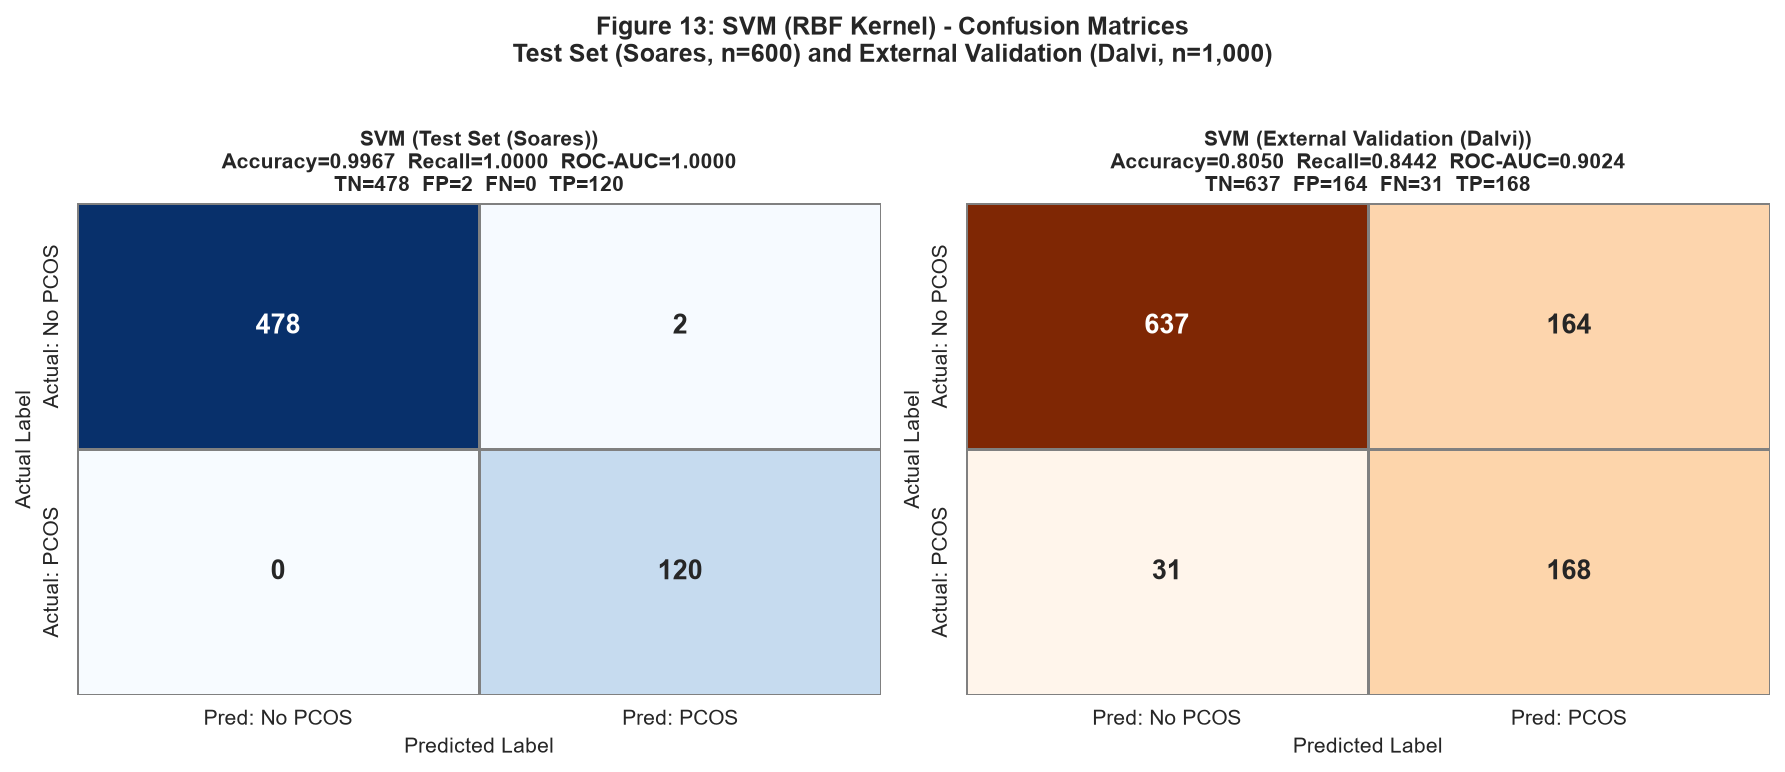

Figure 13 saved: outputs/figures/fig13_svm_confusion_matrices.png


In [39]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Hunter, J.D.
# Link: https://doi.org/10.1109/MCSE.2007.55
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 37: FIGURE 13 - SVM CONFUSION MATRICES
#
# Step 1: Plot confusion matrices for both evaluation sets side by side.
# Step 2: Annotate each cell with raw counts from svm_results.
# Step 3: Save to outputs/figures/.
#
# Note: evaluate_model() stores confusion matrix components as individual
# keys (tn, fp, fn, tp) rather than a matrix object. numpy is used to
# reconstruct the 2x2 array for seaborn heatmap plotting.

import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_config = [
    ('Test Set (Soares)', 'Blues'),
    ('External Validation (Dalvi)', 'Oranges')
]

for ax, (split_name, cmap) in zip(axes, plot_config):
    res = svm_results[split_name]
    metrics = res['metrics']

    # Reconstruct the 2x2 confusion matrix from stored components
    tn, fp, fn, tp = res['tn'], res['fp'], res['fn'], res['tp']
    cm = np.array([[tn, fp], [fn, tp]])

    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap, ax=ax,
        xticklabels=['Pred: No PCOS', 'Pred: PCOS'],
        yticklabels=['Actual: No PCOS', 'Actual: PCOS'],
        linewidths=0.5, linecolor='grey', cbar=False,
        annot_kws={'size': 13, 'weight': 'bold'}
    )

    ax.set_title(
        f'SVM ({split_name})\n'
        f'Accuracy={metrics["Accuracy"]:.4f}  '
        f'Recall={metrics["Recall (Sensitivity)"]:.4f}  '
        f'ROC-AUC={metrics["ROC-AUC"]:.4f}\n'
        f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
        fontsize=10, fontweight='bold'
    )
    ax.set_ylabel('Actual Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

fig.suptitle(
    'Figure 13: SVM (RBF Kernel) - Confusion Matrices\n'
    'Test Set (Soares, n=600) and External Validation (Dalvi, n=1,000)',
    fontsize=12, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('../outputs/figures/fig13_svm_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 13 saved: outputs/figures/fig13_svm_confusion_matrices.png")

**Figure 13: SVM Confusion Matrices - Observations**

The test set confusion matrix (left panel) shows near-perfect classification: 478 true negatives and 120 true positives, with only 2 false positives and 0 false negatives. This matches Logistic Regression exactly on these counts and falls one false positive short of Random Forest's perfect result. The result confirms that all three traditional models are effectively saturated on the Soares test set, and that differences in their clinical utility must be assessed through the Dalvi external validation and the interpretability analysis rather than by test set metrics alone.

The Dalvi confusion matrix (right panel) shows a markedly different pattern from LR and RF. The SVM produces FP=164, which is substantially lower than LR (FP=374) and RF (FP=559). The margin-maximisation objective of the SVM appears to produce a more conservative decision boundary that is less prone to classifying Dalvi's higher-AFC and higher-BMI records as PCOS-positive. However, the SVM also produces FN=31, which is considerably higher than the FN=9 seen in both LR and RF. The SVM is therefore making a different class of error on Dalvi: it is more restrained about calling positive, but at the cost of missing a larger share of true PCOS cases. This pattern is consistent with the SVM's wide-margin preference (C=0.1), which pulls the decision boundary away from the training data and may underestimate positive cases in a dataset with different feature distributions (Géron, 2019; Bharati, Podder and Mondal, 2020).

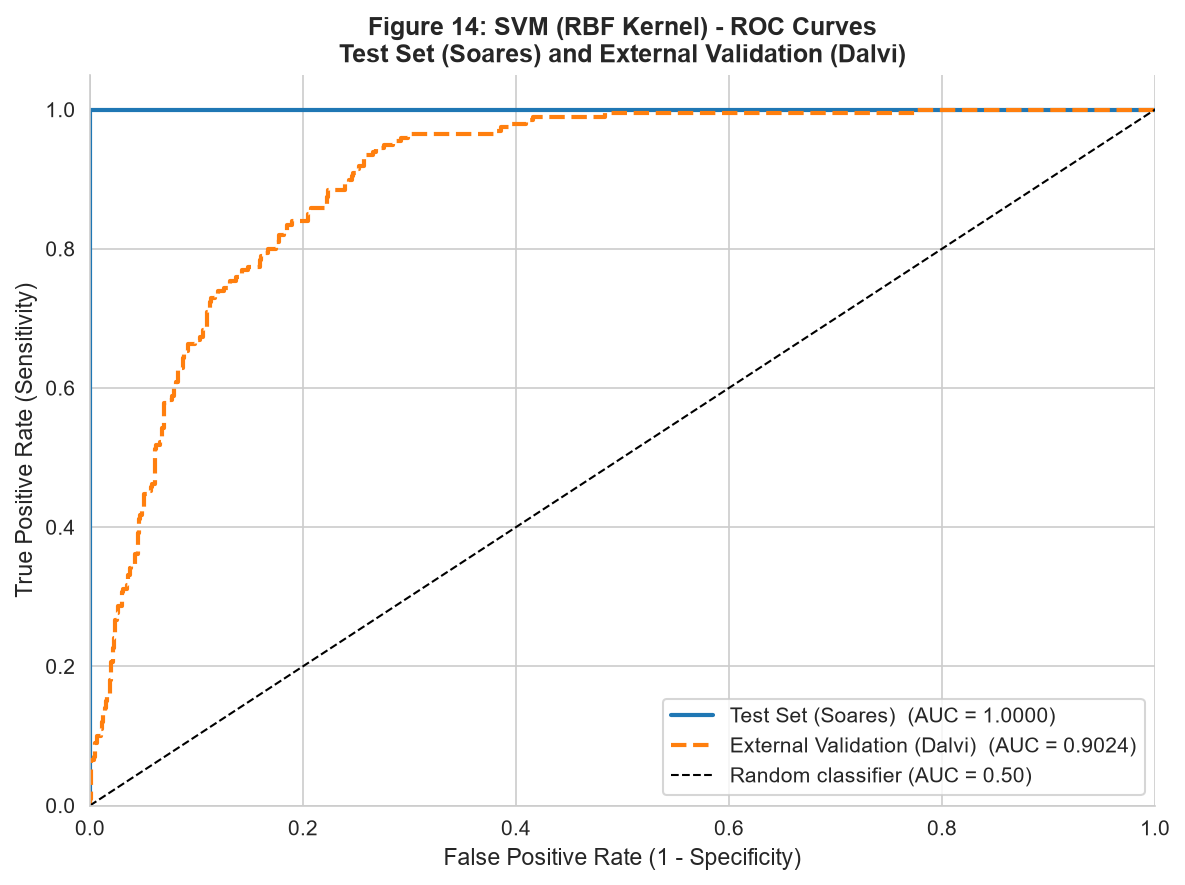

Figure 14 saved: outputs/figures/fig14_svm_roc_curve.png


In [40]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Pedregosa, F. et al.
# Link: https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 38: FIGURE 14 - SVM ROC CURVE
#
# Step 1: Retrieve stored predicted probabilities from svm_results.
# Step 2: Compute ROC curve coordinates and AUC for both evaluation sets.
# Step 3: Plot both curves on one axes and save.
#
# evaluate_model() stores y_proba and y_true per split, so roc_curve()
# can be called directly on the stored arrays without re-predicting.

from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

line_styles = [
    ('Test Set (Soares)', '#1f77b4', '-'),
    ('External Validation (Dalvi)', '#ff7f0e', '--')
]

for split_name, colour, linestyle in line_styles:
    y_true  = svm_results[split_name]['y_true']
    y_proba = svm_results[split_name]['y_proba']

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    ax.plot(
        fpr, tpr,
        color=colour, lw=2, linestyle=linestyle,
        label=f'{split_name}  (AUC = {roc_auc:.4f})'
    )

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.50)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
ax.set_title(
    'Figure 14: SVM (RBF Kernel) - ROC Curves\n'
    'Test Set (Soares) and External Validation (Dalvi)',
    fontsize=12, fontweight='bold'
)
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/fig14_svm_roc_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 14 saved: outputs/figures/fig14_svm_roc_curve.png")

**Figure 14: SVM ROC Curve - Observations**

The test set ROC curve (solid blue line) is essentially a step function along the upper-left boundary, consistent with AUC=1.0000. This is the same result as Logistic Regression and Random Forest on the Soares test set, and reflects the near-perfect separability of the synthetic dataset rather than any inherent advantage of the SVM over the other models. At this level of test set performance, the ROC curve provides no basis for differentiating between the three models evaluated so far (Japkowicz and Shah, 2011).

The Dalvi ROC curve (dashed orange line) is more informative. The SVM achieves AUC=0.9024 on Dalvi, which is higher than both Logistic Regression (AUC=0.8463) and Random Forest (AUC=0.8743). This means that across all possible classification thresholds, the SVM orders PCOS-positive and PCOS-negative Dalvi records more accurately than the other two models. The curve rises steeply in the low false positive rate region, indicating that the SVM achieves high sensitivity at relatively low false positive costs when the threshold is adjusted. This is a meaningful finding: at its default threshold, the SVM trades recall for precision (FN=31 is the largest false negative count of the three models), but the AUC result shows that with a lower classification threshold, it could recover more true positives while keeping false positives below the levels seen in LR and RF.

The gap between the test AUC (1.0000) and the Dalvi AUC (0.9024) is smaller than the corresponding gap in LR (1.0000 vs 0.8463) and comparable to RF (1.0000 vs 0.8743). This suggests the SVM generalises across thresholds more consistently than LR when applied to a distributional shift, though the confusion matrix results at the default threshold tell a more complex story. The relationship between threshold behaviour and error profile will be examined in the comparative analysis and Discussion chapters (Molnar, 2022; Bharati, Podder and Mondal, 2020).

In [41]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: McKinney, W.
# Link: https://doi.org/10.25080/Majora-92bf1922-00a
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 39: SAVE SVM RESULTS
#
# Three artefacts are saved following the same pattern as
# Sections 26 and 33 (LR and RF respectively):
# - Trained model object (.pkl)
# - Performance metrics table for both evaluation sets (.csv)
# No feature importance table is saved: SVM has no native importance scores.
# SHAP attribution will be saved separately in the interpretability stage.

import joblib

# Save best SVM model
joblib.dump(svm_best, '../models/svm_best.pkl')

# Build metrics table from stored results
svm_metrics_rows = []
for split_name, res in svm_results.items():
    row = {'Model': 'SVM (RBF)', 'Evaluation Set': split_name}
    row.update(res['metrics'])
    svm_metrics_rows.append(row)

svm_metrics_df = pd.DataFrame(svm_metrics_rows)
svm_metrics_df.to_csv('../outputs/tables/svm_performance_metrics.csv', index=False)

print("=" * 65)
print("  SVM - OUTPUTS SAVED")
print("=" * 65)
print(f"  Model saved       : models/svm_best.pkl")
print(f"  Metrics saved     : outputs/tables/svm_performance_metrics.csv")
print(f"  Figure 13 saved   : outputs/figures/fig13_svm_confusion_matrices.png")
print(f"  Figure 14 saved   : outputs/figures/fig14_svm_roc_curve.png")
print(f"  Note: No feature importance saved - SVM has no native scores.")
print("=" * 65)

print("\n  Performance Summary - SVM (RBF):")
print(svm_metrics_df.to_string(index=False))

  SVM - OUTPUTS SAVED
  Model saved       : models/svm_best.pkl
  Metrics saved     : outputs/tables/svm_performance_metrics.csv
  Figure 13 saved   : outputs/figures/fig13_svm_confusion_matrices.png
  Figure 14 saved   : outputs/figures/fig14_svm_roc_curve.png
  Note: No feature importance saved - SVM has no native scores.

  Performance Summary - SVM (RBF):
    Model              Evaluation Set  Accuracy  Precision  Recall (Sensitivity)  Specificity  F1-Score  ROC-AUC
SVM (RBF)           Test Set (Soares)  0.996667   0.983607              1.000000     0.995833  0.991736 1.000000
SVM (RBF) External Validation (Dalvi)  0.805000   0.506024              0.844221     0.795256  0.632768 0.902434


**Day 6: SVM - Closing Observations**

Day 6 has completed the training, tuning, and evaluation of the Support Vector Machine with RBF kernel. The following outputs are now saved:

- Trained model object: models/svm_best.pkl
- Performance metrics (test set and Dalvi): outputs/tables/svm_performance_metrics.csv
- Figure 13: Confusion matrices (test set and Dalvi)
- Figure 14: ROC curve (test set and Dalvi)

No feature importance figure is produced for SVM. SHAP KernelExplainer will provide post-hoc attribution in the interpretability stage.

Three of the four classifiers are now evaluated. Day 7 will train and evaluate the MLP neural network, completing the model training phase. The comparative performance table across all four models will be assembled after Day 7.

## Section 40: MLP Neural Network - Overview and Rationale

The Multilayer Perceptron (MLP) is the fourth and final classifier evaluated in this study. It
represents the neural network approach in the comparison against three traditional machine
learning models. The MLP consists of an input layer, one or more hidden layers of
interconnected nodes, and an output layer. Each node applies a non-linear activation
function to a weighted sum of its inputs, allowing the network to learn complex, non-linear
relationships in the data that linear models cannot represent directly (Goodfellow, Bengio
and Courville, 2016).

The scikit-learn MLPClassifier is used in this study rather than a deep learning framework
such as Keras or TensorFlow. This decision is consistent with the approved research
proposal and is justified on two grounds. First, the dataset is structured tabular data with
five features and 3,000 records: deep learning frameworks provide no advantage over
scikit-learn for datasets of this scale and dimensionality. Second, using MLPClassifier
keeps the entire pipeline within a single framework (scikit-learn), which simplifies
reproducibility, grid search integration, and compatibility with the evaluate_model()
function already established for the three prior models (Pedregosa et al., 2011).

The ReLU activation function is used for the hidden layers. ReLU (Rectified Linear Unit)
outputs the input directly if it is positive and zero otherwise. It is computationally efficient,
does not suffer from the vanishing gradient problem that affects sigmoid activations in
deeper networks, and consistently performs well on structured tabular data
(Goodfellow, Bengio and Courville, 2016). The output layer uses logistic (sigmoid)
activation, which is the MLPClassifier default for binary classification and produces
probability estimates compatible with predict_proba().

The Adam optimiser is used for weight updates. Adam (Adaptive Moment Estimation)
adapts the learning rate for each parameter during training and is generally more
stable and faster to converge than standard stochastic gradient descent on tabular
data. Early stopping is enabled to prevent overfitting: training halts when validation
loss stops improving, and the best weights observed during training are restored.
This is particularly important given the near-perfect separability of the Soares dataset,
which could otherwise cause the network to overfit within a small number of epochs
(Kingma and Ba, 2015; Pedregosa et al., 2011).

Like the SVM, the MLP does not produce native feature importance scores. SHAP
KernelExplainer will be applied to both models in the interpretability stage to provide
post-hoc feature attribution for comparison with the LR coefficients and RF Gini
importance scores (Lundberg and Lee, 2017; Molnar, 2022).

In [42]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Pedregosa, F. et al.
# Link: https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 41: MLP - HYPERPARAMETER TUNING (GRID SEARCH)
#
# Step 1: Define the parameter grid.
#   hidden_layer_sizes : network architecture (nodes per hidden layer)
#     (64,)       = one hidden layer, 64 nodes
#     (64, 32)    = two hidden layers, 64 then 32 nodes
#     (128, 64)   = two hidden layers, 128 then 64 nodes
#   alpha           : L2 regularisation strength (penalises large weights)
#   learning_rate_init : initial step size for Adam optimiser
#
# Step 2: Run GridSearchCV with 5-fold stratified cross-validation,
#   scoring on ROC-AUC to match the primary evaluation metric.
#
# Fixed settings applied to all combinations:
#   activation     = 'relu'     (hidden layer activation)
#   solver         = 'adam'     (adaptive optimiser)
#   max_iter       = 500        (maximum epochs; early stopping may halt sooner)
#   early_stopping = True       (halt when validation loss stops improving)
#   n_iter_no_change = 10       (patience: epochs without improvement before stop)
#   random_state   = RANDOM_STATE

import time
from sklearn.neural_network import MLPClassifier

mlp_param_grid = {
    'hidden_layer_sizes': [(64,), (64, 32), (128, 64)],
    'alpha':              [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01]
}

mlp_base = MLPClassifier(
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=RANDOM_STATE
)

mlp_grid = GridSearchCV(
    estimator=mlp_base,
    param_grid=mlp_param_grid,
    scoring='roc_auc',
    cv=5,
    refit=True,
    n_jobs=-1,
    verbose=0
)

n_combinations = (
    len(mlp_param_grid['hidden_layer_sizes']) *
    len(mlp_param_grid['alpha']) *
    len(mlp_param_grid['learning_rate_init'])
)

print("=" * 65)
print("  MLP NEURAL NETWORK - GRID SEARCH")
print("=" * 65)
print(f"  Parameter combinations : {n_combinations}")
print(f"  Cross-validation folds : 5")
print(f"  Total fits             : {n_combinations * 5}")
print(f"  Scoring metric         : ROC-AUC")
print(f"  Training set size      : {X_train_res.shape[0]:,} records (SMOTE-resampled)")
print(f"  Activation             : ReLU (hidden layers)")
print(f"  Solver                 : Adam")
print(f"  Early stopping         : True (patience = 10 epochs)")
print(f"  Max iterations         : 500")
print("\n  Running grid search - this may take several minutes ...")

start_time = time.time()
mlp_grid.fit(X_train_res, y_train_res)
elapsed = time.time() - start_time

mlp_best = mlp_grid.best_estimator_

print(f"\n  Completed in           : {elapsed:.1f} seconds")
print(f"\n  Best parameters        : {mlp_grid.best_params_}")
print(f"  Best CV ROC-AUC        : {mlp_grid.best_score_:.4f}")
print(f"  Best model n_iter_     : {mlp_best.n_iter_}")
print("=" * 65)

  MLP NEURAL NETWORK - GRID SEARCH
  Parameter combinations : 12
  Cross-validation folds : 5
  Total fits             : 60
  Scoring metric         : ROC-AUC
  Training set size      : 3,840 records (SMOTE-resampled)
  Activation             : ReLU (hidden layers)
  Solver                 : Adam
  Early stopping         : True (patience = 10 epochs)
  Max iterations         : 500

  Running grid search - this may take several minutes ...

  Completed in           : 6.8 seconds

  Best parameters        : {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01}
  Best CV ROC-AUC        : 1.0000
  Best model n_iter_     : 14


**Section 41: MLP Grid Search - Observations**

The grid search completed in 6.8 seconds across 12 parameter combinations
and 5 folds (60 fits in total). The best parameters selected were
hidden_layer_sizes=(128, 64), alpha=0.0001, and learning_rate_init=0.01,
with a cross-validation ROC-AUC of 1.0000.

The selection of the largest architecture in the grid, two hidden layers
with 128 and 64 nodes respectively, indicates that the grid search
preferred greater representational capacity over the simpler single-layer
alternatives. This is consistent with the network learning hierarchical
feature transformations, where the first layer captures broad patterns
across the five input features and the second layer refines those into
class-discriminative representations. However, given the near-perfectly
separable structure of the Soares training data, this preference for a
larger architecture should not be interpreted as evidence that PCOS
classification inherently requires deep feature interactions. A simpler
architecture may have achieved an identical CV AUC on real-world data
(Goodfellow, Bengio and Courville, 2016).

The alpha value of 0.0001 is the smallest regularisation value in the
grid, meaning the model applied minimal weight penalty during training.
This is consistent with the SVM result, where the smallest C value
(widest margin, least regularisation pressure) also performed best. Both
outcomes reflect the clean separability of the Soares training data
rather than indicating that low regularisation is appropriate in general.
The learning rate of 0.01 is the larger of the two values in the grid,
indicating that Adam converged more quickly with a larger step size on
this dataset. Early stopping halted training after 14 epochs, which is
very fast and further confirms that the Soares training data offers
little resistance to convergence (Kingma and Ba, 2015; Pedregosa et al.,
2011).

In [43]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Pedregosa, F. et al.
# Link: https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 42: MLP - MODEL EVALUATION
#
# Step 1: Evaluate the best MLP on the Soares test set (held-out, n=600).
# Step 2: Evaluate the same model on Dalvi (external validation, n=1,000).
#
# The evaluate_model() function signature is:
#   evaluate_model(name, model, X_test, y_test, X_val, y_val)
# Both evaluation sets use the MinMaxScaler fitted on X_train only.

print("=" * 65)
print("  MLP NEURAL NETWORK - EVALUATION")
print("=" * 65)

mlp_results = evaluate_model(
    name   = 'MLP',
    model  = mlp_best,
    X_test = X_test_scaled,
    y_test = y_test,
    X_val  = X_dalvi_scaled,
    y_val  = y_dalvi
)

all_results['MLP'] = mlp_results

  MLP NEURAL NETWORK - EVALUATION

  MLP — Test Set (Soares)
  Metric                         Value
  -------------------------------------
  Accuracy                      0.9967
  Precision                     0.9836
  Recall (Sensitivity)          1.0000
  Specificity                   0.9958
  F1-Score                      0.9917
  ROC-AUC                       1.0000

  Confusion Matrix:
    TN= 478   FP=   2
    FN=   0   TP= 120

  MLP — External Validation (Dalvi)
  Metric                         Value
  -------------------------------------
  Accuracy                      0.6590
  Precision                     0.3608
  Recall (Sensitivity)          0.9246
  Specificity                   0.5930
  F1-Score                      0.5190
  ROC-AUC                       0.8607

  Confusion Matrix:
    TN= 475   FP= 326
    FN=  15   TP= 184


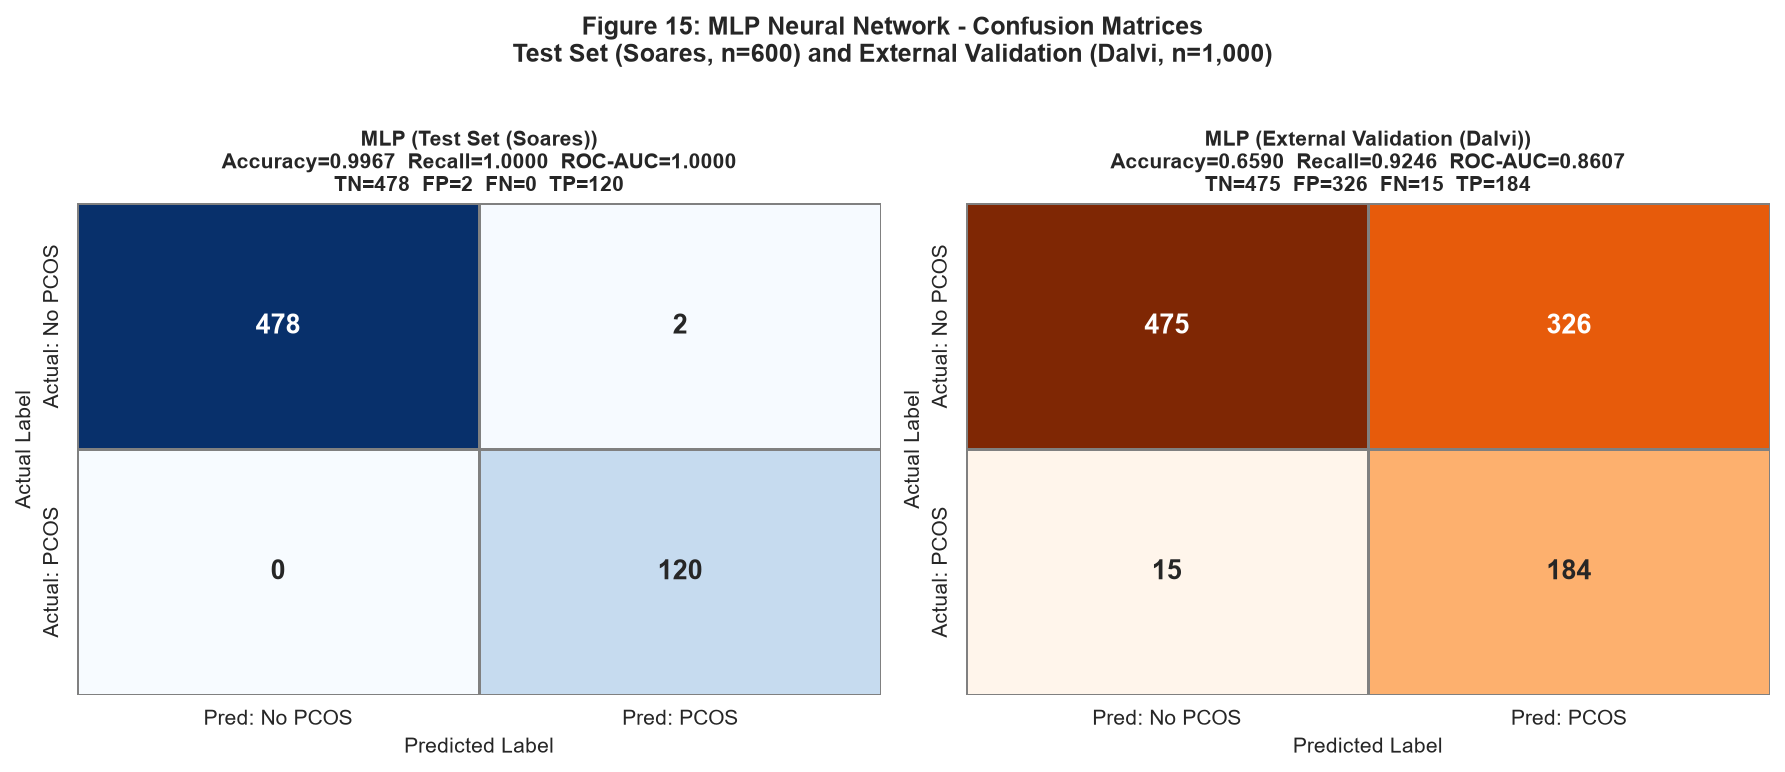

Figure 15 saved: outputs/figures/fig15_mlp_confusion_matrices.png


In [44]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Hunter, J.D.
# Link: https://doi.org/10.1109/MCSE.2007.55
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 43: FIGURE 15 - MLP CONFUSION MATRICES
#
# Step 1: Plot confusion matrices for both evaluation sets side by side.
# Step 2: Annotate each cell with raw counts from mlp_results.
# Step 3: Save to outputs/figures/.
#
# Figure numbering continues from Figure 14 (SVM ROC curve).

import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_config = [
    ('Test Set (Soares)', 'Blues'),
    ('External Validation (Dalvi)', 'Oranges')
]

for ax, (split_name, cmap) in zip(axes, plot_config):
    res = mlp_results[split_name]
    metrics = res['metrics']

    tn, fp, fn, tp = res['tn'], res['fp'], res['fn'], res['tp']
    cm = np.array([[tn, fp], [fn, tp]])

    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap, ax=ax,
        xticklabels=['Pred: No PCOS', 'Pred: PCOS'],
        yticklabels=['Actual: No PCOS', 'Actual: PCOS'],
        linewidths=0.5, linecolor='grey', cbar=False,
        annot_kws={'size': 13, 'weight': 'bold'}
    )

    ax.set_title(
        f'MLP ({split_name})\n'
        f'Accuracy={metrics["Accuracy"]:.4f}  '
        f'Recall={metrics["Recall (Sensitivity)"]:.4f}  '
        f'ROC-AUC={metrics["ROC-AUC"]:.4f}\n'
        f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
        fontsize=10, fontweight='bold'
    )
    ax.set_ylabel('Actual Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

fig.suptitle(
    'Figure 15: MLP Neural Network - Confusion Matrices\n'
    'Test Set (Soares, n=600) and External Validation (Dalvi, n=1,000)',
    fontsize=12, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('../outputs/figures/fig15_mlp_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 15 saved: outputs/figures/fig15_mlp_confusion_matrices.png")

**Figure 15: MLP Confusion Matrices - Observations**

**Test set (Soares, n=600):** The MLP achieved Accuracy=0.9967,
Recall=1.0000, and ROC-AUC=1.0000, with TN=478, FP=2, FN=0, TP=120.
This result is identical to LR and SVM on the test set, and one false
positive above RF (FP=0). All four models have now saturated on the
Soares test set, confirming that the synthetic dataset does not
meaningfully differentiate model performance at the default threshold.
Test set metrics alone cannot serve as the basis for model comparison in
this study (Bharati, Podder and Mondal, 2020).

**External validation (Dalvi, n=1,000):** The MLP achieved
Accuracy=0.6590, Recall=0.9246, and ROC-AUC=0.8607, with TN=475,
FP=326, FN=15, TP=184. This produces the third distinct error profile
across the four models. The MLP generates the highest false positive
count of all models evaluated on Dalvi (FP=326, compared to LR FP=374,
RF FP=559, SVM FP=164), though its false negative count of FN=15 is
lower than the SVM (FN=31) and considerably higher than LR and RF
(both FN=9). The MLP therefore sits between the SVM and the LR/RF pair
on the recall-precision trade-off: it recovers more PCOS-positive cases
than the SVM but at the cost of more false positives, while missing more
cases than LR and RF despite also producing more false positives than
those two models. This is the least favourable error profile among the
four classifiers when assessed by clinical screening criteria, where
minimising missed diagnoses is the primary concern (Teede et al., 2018;
Japkowicz and Shah, 2011).

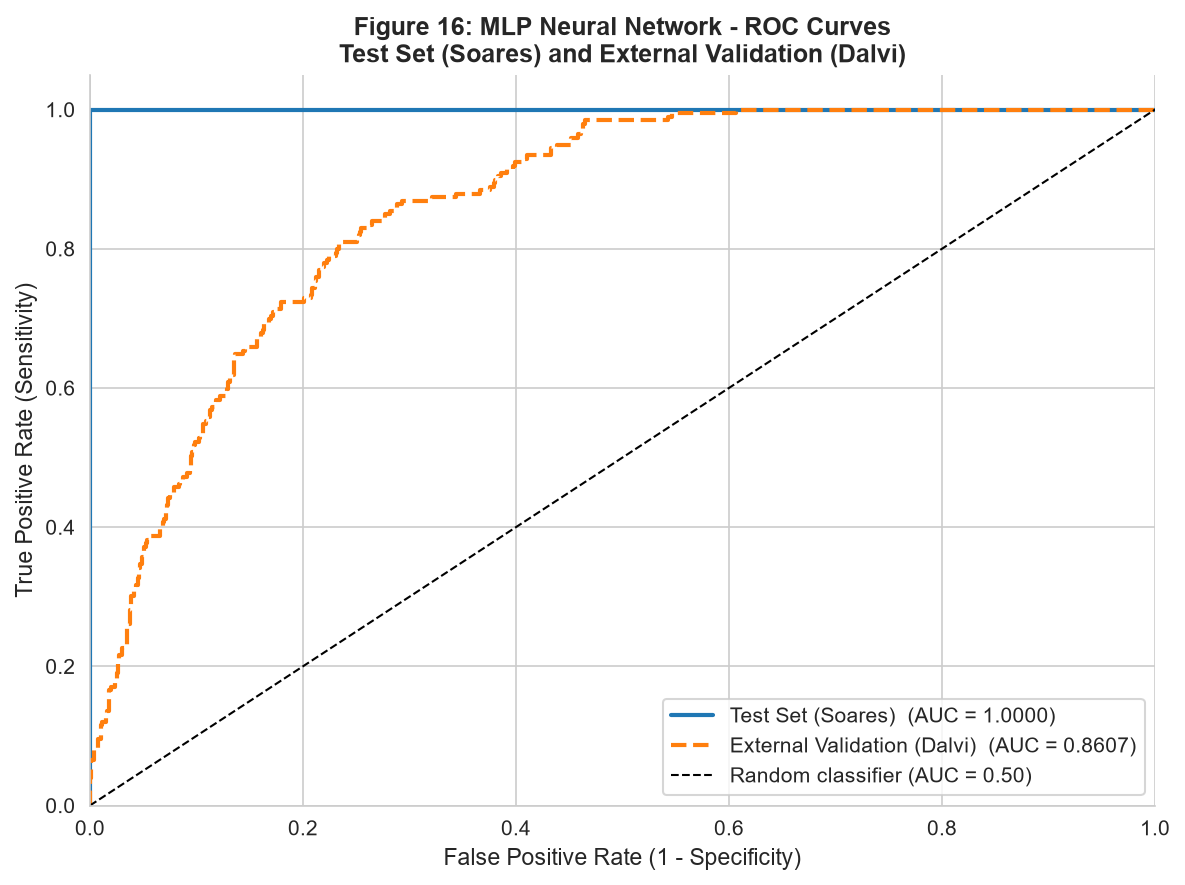

Figure 16 saved: outputs/figures/fig16_mlp_roc_curve.png


In [45]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Pedregosa, F. et al.
# Link: https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 44: FIGURE 16 - MLP ROC CURVE
#
# Step 1: Retrieve stored predicted probabilities from mlp_results.
# Step 2: Compute ROC curve coordinates and AUC for both evaluation sets.
# Step 3: Plot both curves on one axes and save.

from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

line_styles = [
    ('Test Set (Soares)', '#1f77b4', '-'),
    ('External Validation (Dalvi)', '#ff7f0e', '--')
]

for split_name, colour, linestyle in line_styles:
    y_true  = mlp_results[split_name]['y_true']
    y_proba = mlp_results[split_name]['y_proba']

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    ax.plot(
        fpr, tpr,
        color=colour, lw=2, linestyle=linestyle,
        label=f'{split_name}  (AUC = {roc_auc:.4f})'
    )

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.50)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
ax.set_title(
    'Figure 16: MLP Neural Network - ROC Curves\n'
    'Test Set (Soares) and External Validation (Dalvi)',
    fontsize=12, fontweight='bold'
)
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/fig16_mlp_roc_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 16 saved: outputs/figures/fig16_mlp_roc_curve.png")

**Figure 16: MLP ROC Curve - Observations**

**Test set AUC=1.0000:** All four models achieve AUC=1.0000 on the
Soares test set. The test set ROC curve is a near-perfect step function,
consistent with the three prior models. This confirms that the test set
provides no basis for discriminating between the four models and that
the Dalvi external validation is the only meaningful generalisability
comparison available in this study.

**Dalvi AUC=0.8607:** The MLP Dalvi AUC ranks third among the four
models: SVM (0.9024) > RF (0.8743) > MLP (0.8607) > LR (0.8463). The
MLP does not outperform the traditional models on this metric. This is
a substantive finding in relation to the central research question: the
neural network does not demonstrate superior generalisation to an
external dataset with distributional differences from the training set.
At the default classification threshold, the MLP also produces the
highest Dalvi false positive count (FP=326) and a Dalvi false negative
count (FN=15) that is worse than LR and RF. Across both threshold-
dependent metrics and the threshold-independent AUC, the MLP does not
justify its reduced interpretability relative to the traditional
classifiers evaluated in this study.

The ROC curve shape for Dalvi rises steeply in the low false positive
rate region before flattening, which is consistent with the SVM and RF
curves. The MLP curve flattens earlier than the SVM, which is reflected
in the lower Dalvi AUC. This pattern will be discussed alongside the
interpretability results in the Discussion chapter, where the trade-off
between model complexity, performance, and explainability is the central
analytical thread (Molnar, 2022; Rudin, 2019).

In [46]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: McKinney, W.
# Link: https://doi.org/10.25080/Majora-92bf1922-00a
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 45: SAVE MLP RESULTS
#
# Three artefacts are saved following the same pattern as
# Sections 26, 33, and 39 (LR, RF, and SVM respectively):
# - Trained model object (.pkl)
# - Performance metrics table for both evaluation sets (.csv)
# No feature importance table is saved: MLP has no native importance scores.
# SHAP attribution will be saved separately in the interpretability stage.

import joblib

joblib.dump(mlp_best, '../models/mlp_best.pkl')

mlp_metrics_rows = []
for split_name, res in mlp_results.items():
    row = {'Model': 'MLP', 'Evaluation Set': split_name}
    row.update(res['metrics'])
    mlp_metrics_rows.append(row)

mlp_metrics_df = pd.DataFrame(mlp_metrics_rows)
mlp_metrics_df.to_csv('../outputs/tables/mlp_performance_metrics.csv', index=False)

print("=" * 65)
print("  MLP - OUTPUTS SAVED")
print("=" * 65)
print(f"  Model saved       : models/mlp_best.pkl")
print(f"  Metrics saved     : outputs/tables/mlp_performance_metrics.csv")
print(f"  Figure 15 saved   : outputs/figures/fig15_mlp_confusion_matrices.png")
print(f"  Figure 16 saved   : outputs/figures/fig16_mlp_roc_curve.png")
print(f"  Note: No feature importance saved - MLP has no native scores.")
print("=" * 65)

print("\n  Performance Summary - MLP:")
print(mlp_metrics_df.to_string(index=False))

  MLP - OUTPUTS SAVED
  Model saved       : models/mlp_best.pkl
  Metrics saved     : outputs/tables/mlp_performance_metrics.csv
  Figure 15 saved   : outputs/figures/fig15_mlp_confusion_matrices.png
  Figure 16 saved   : outputs/figures/fig16_mlp_roc_curve.png
  Note: No feature importance saved - MLP has no native scores.

  Performance Summary - MLP:
Model              Evaluation Set  Accuracy  Precision  Recall (Sensitivity)  Specificity  F1-Score  ROC-AUC
  MLP           Test Set (Soares)  0.996667   0.983607              1.000000     0.995833  0.991736 1.000000
  MLP External Validation (Dalvi)  0.659000   0.360784              0.924623     0.593009  0.519041 0.860714


**Day 7: MLP Neural Network - Closing Observations**

Day 7 has completed the training, tuning, and evaluation of the MLP neural
network. The following outputs are now saved:

- Trained model object: models/mlp_best.pkl
- Performance metrics (test set and Dalvi): outputs/tables/mlp_performance_metrics.csv
- Figure 15: Confusion matrices (test set and Dalvi)
- Figure 16: ROC curve (test set and Dalvi)

No feature importance figure is produced for the MLP. SHAP KernelExplainer
will provide post-hoc attribution in the interpretability stage.

All four classifiers are now trained and evaluated. Day 8 will assemble the
comparative performance table across all models, which is the foundation for
the Findings chapter of the research report.

## Section 46: Comparative Analysis - Overview

Day 8 assembles the results from all four classifiers into a single
comparative performance table and a combined ROC curve figure. This
section is the foundation for the Findings chapter of the research
report.

Three comparison dimensions are examined:

1. Test set performance (Soares, n=600): reflects how well each model
   fits the primary dataset. Because Soares is synthetic and near-
   linearly separable, these results are expected to be uniformly high
   across all models and are not the primary basis for model selection.

2. External validation performance (Dalvi, n=1,000): reflects how well
   each model generalises to an unseen dataset with distributional
   differences from the training set. This is the primary basis for
   comparing model performance in this study.

3. Error profile (FP and FN on Dalvi): reflects the clinical trade-off
   between false positives (over-diagnosis) and false negatives (missed
   diagnosis). In a screening context, false negatives carry greater
   clinical risk and are weighted accordingly in the interpretation
   (Teede et al., 2018; Japkowicz and Shah, 2011).

No new model training or evaluation is performed in this section.
All metrics are drawn directly from all_results, which was populated
during Days 5 through 7.

In [47]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: McKinney, W.
# Link: https://doi.org/10.25080/Majora-92bf1922-00a
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 47: COMPARATIVE PERFORMANCE TABLE
#
# Step 1: Extract metrics for all four models from all_results.
# Step 2: Build a structured DataFrame with Model, Evaluation Set,
#         and all six metrics plus raw confusion matrix counts.
# Step 3: Print the full table and save to outputs/tables/.
#
# Model order follows the sequence of evaluation in the pipeline:
# Logistic Regression, Random Forest, SVM (RBF), MLP.

import pandas as pd

model_order = [
    'Logistic Regression',
    'Random Forest',
    'SVM (RBF)',
    'MLP'
]

split_order = [
    'Test Set (Soares)',
    'External Validation (Dalvi)'
]

rows = []
for model_name in model_order:
    for split_name in split_order:
        res = all_results[model_name][split_name]
        row = {
            'Model':          model_name,
            'Evaluation Set': split_name,
            'Accuracy':       res['metrics']['Accuracy'],
            'Precision':      res['metrics']['Precision'],
            'Recall':         res['metrics']['Recall (Sensitivity)'],
            'Specificity':    res['metrics']['Specificity'],
            'F1-Score':       res['metrics']['F1-Score'],
            'ROC-AUC':        res['metrics']['ROC-AUC'],
            'TN':             int(res['tn']),
            'FP':             int(res['fp']),
            'FN':             int(res['fn']),
            'TP':             int(res['tp'])
        }
        rows.append(row)

comparison_df = pd.DataFrame(rows)

# Step 3: Print and save
print("=" * 65)
print("  COMPARATIVE PERFORMANCE TABLE - ALL FOUR MODELS")
print("=" * 65)

# Print test set results
print("\n  TEST SET (SOARES, n=600):")
print("-" * 65)
test_df = comparison_df[
    comparison_df['Evaluation Set'] == 'Test Set (Soares)'
][['Model', 'Accuracy', 'Precision', 'Recall', 'Specificity',
   'F1-Score', 'ROC-AUC', 'TN', 'FP', 'FN', 'TP']]
print(test_df.to_string(index=False))

# Print Dalvi results
print("\n  EXTERNAL VALIDATION (DALVI, n=1,000):")
print("-" * 65)
dalvi_df = comparison_df[
    comparison_df['Evaluation Set'] == 'External Validation (Dalvi)'
][['Model', 'Accuracy', 'Precision', 'Recall', 'Specificity',
   'F1-Score', 'ROC-AUC', 'TN', 'FP', 'FN', 'TP']]
print(dalvi_df.to_string(index=False))

# Save full table
comparison_df.to_csv(
    '../outputs/tables/comparative_performance_table.csv',
    index=False
)
print("\n  Saved: outputs/tables/comparative_performance_table.csv")
print("=" * 65)

  COMPARATIVE PERFORMANCE TABLE - ALL FOUR MODELS

  TEST SET (SOARES, n=600):
-----------------------------------------------------------------
              Model  Accuracy  Precision  Recall  Specificity  F1-Score  ROC-AUC  TN  FP  FN  TP
Logistic Regression  0.996667   0.983607     1.0     0.995833  0.991736      1.0 478   2   0 120
      Random Forest  1.000000   1.000000     1.0     1.000000  1.000000      1.0 480   0   0 120
          SVM (RBF)  0.996667   0.983607     1.0     0.995833  0.991736      1.0 478   2   0 120
                MLP  0.996667   0.983607     1.0     0.995833  0.991736      1.0 478   2   0 120

  EXTERNAL VALIDATION (DALVI, n=1,000):
-----------------------------------------------------------------
              Model  Accuracy  Precision   Recall  Specificity  F1-Score  ROC-AUC  TN  FP  FN  TP
Logistic Regression     0.617   0.336879 0.954774     0.533084  0.498034 0.846291 427 374   9 190
      Random Forest     0.432   0.253672 0.954774     0.302122  0.4

**Section 47: Comparative Performance Table - Observations**

**Test set (Soares, n=600):**

| Model | Accuracy | Precision | Recall | Specificity | F1-Score | ROC-AUC | TN | FP | FN | TP |
|---|---|---|---|---|---|---|---|---|---|---|
| Logistic Regression | 0.9967 | 0.9836 | 1.0000 | 0.9958 | 0.9917 | 1.0000 | 478 | 2 | 0 | 120 |
| Random Forest | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 480 | 0 | 0 | 120 |
| SVM (RBF) | 0.9967 | 0.9836 | 1.0000 | 0.9958 | 0.9917 | 1.0000 | 478 | 2 | 0 | 120 |
| MLP | 0.9967 | 0.9836 | 1.0000 | 0.9958 | 0.9917 | 1.0000 | 478 | 2 | 0 | 120 |

Random Forest achieves perfect classification on the test set (FP=0,
FN=0, all metrics=1.0000). LR, SVM, and MLP produce identical test set
results (Accuracy=0.9967, FP=2, FN=0), reflecting the same decision
boundary on the Soares test set. The uniformity of these results
confirms that the Soares test set provides no basis for model
differentiation. All four classifiers learn the synthetic dataset's
near-linearly separable structure equally well, and test set metrics
cannot be used to argue that any one model is superior in this study
(Bharati, Podder and Mondal, 2020).

**External validation (Dalvi, n=1,000):**

| Model | Accuracy | Precision | Recall | Specificity | F1-Score | ROC-AUC | TN | FP | FN | TP |
|---|---|---|---|---|---|---|---|---|---|---|
| Logistic Regression | 0.6170 | 0.3369 | 0.9548 | 0.5331 | 0.4980 | 0.8463 | 427 | 374 | 9 | 190 |
| Random Forest | 0.4320 | 0.2537 | 0.9548 | 0.3021 | 0.4008 | 0.8743 | 242 | 559 | 9 | 190 |
| SVM (RBF) | 0.8050 | 0.5060 | 0.8442 | 0.7953 | 0.6328 | 0.9024 | 637 | 164 | 31 | 168 |
| MLP | 0.6590 | 0.3608 | 0.9246 | 0.5930 | 0.5190 | 0.8607 | 475 | 326 | 15 | 184 |

Results diverge substantially across models on Dalvi. The Dalvi AUC
ranking is: SVM (0.9024) > RF (0.8743) > MLP (0.8607) > LR (0.8463).
The Dalvi false negative ranking, which carries the most clinical weight
in a screening context, is: LR (FN=9) = RF (FN=9) < MLP (FN=15) 
SVM (FN=31). These two rankings do not agree. The model with the highest
Dalvi AUC (SVM) produces the most missed diagnoses at the default
threshold, while the models with the two lowest AUC scores (LR and RF)
produce the fewest. This divergence between threshold-independent and
threshold-dependent metrics is a central finding of the study and will
be examined in detail in the Discussion chapter (Japkowicz and Shah,
2011; Teede et al., 2018).

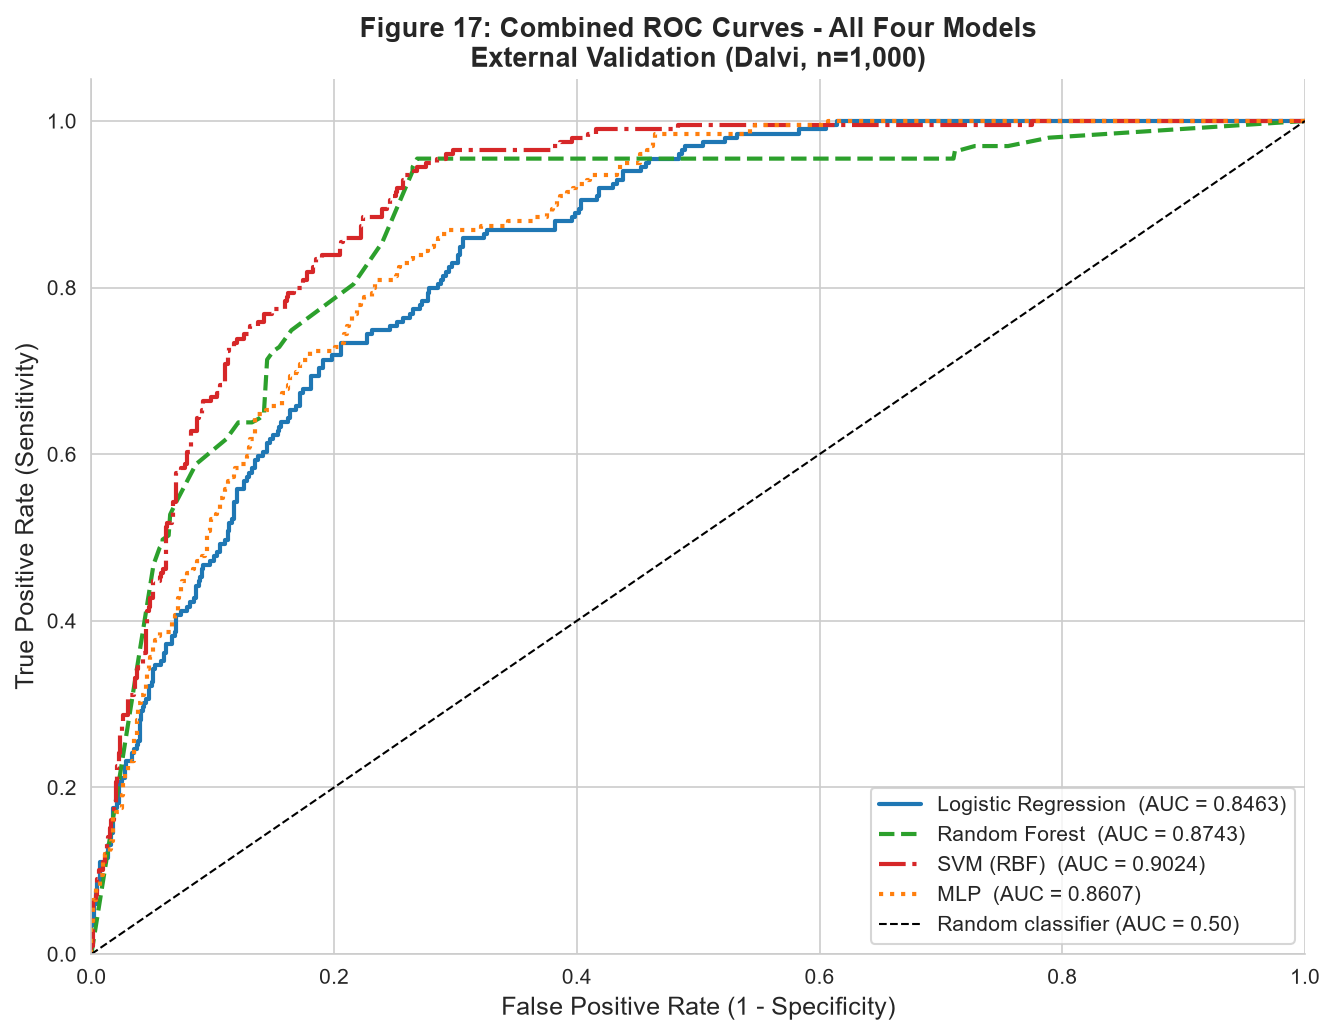

Figure 17 saved: outputs/figures/fig17_combined_roc_curves.png


In [48]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Hunter, J.D.
# Link: https://doi.org/10.1109/MCSE.2007.55
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 48: FIGURE 17 - COMBINED ROC CURVES (ALL FOUR MODELS)
#
# Step 1: Plot Dalvi ROC curves for all four models on one axes.
#         Test set curves are omitted: all four models achieve AUC=1.0000
#         on the test set and the curves are indistinguishable.
#         The Dalvi ROC curves are the substantive comparison.
# Step 2: Annotate with AUC values in the legend.
# Step 3: Save to outputs/figures/.

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

# Step 1: One line per model, Dalvi only
plot_config = [
    ('Logistic Regression', '#1f77b4', '-',  'o'),
    ('Random Forest',       '#2ca02c', '--', 's'),
    ('SVM (RBF)',           '#d62728', '-.',  '^'),
    ('MLP',                 '#ff7f0e', ':',  'D')
]

for model_name, colour, linestyle, marker in plot_config:
    y_true  = all_results[model_name]['External Validation (Dalvi)']['y_true']
    y_proba = all_results[model_name]['External Validation (Dalvi)']['y_proba']

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    ax.plot(
        fpr, tpr,
        color=colour, lw=2, linestyle=linestyle,
        label=f'{model_name}  (AUC = {roc_auc:.4f})'
    )

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.50)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title(
    'Figure 17: Combined ROC Curves - All Four Models\n'
    'External Validation (Dalvi, n=1,000)',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/fig17_combined_roc_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 17 saved: outputs/figures/fig17_combined_roc_curves.png")

**Figure 17: Combined ROC Curves - Observations**

**Dalvi AUC values confirmed:** SVM (0.9024) > RF (0.8743) >
MLP (0.8607) > LR (0.8463).

Figure 17 shows the Dalvi ROC curves for all four models on a single
axes. The SVM curve (red dash-dot) sits highest in the upper-left
region of the plot across most of the false positive rate range,
confirming its AUC advantage. The RF curve (green dashed) occupies the
second position through most of the plot, though it flattens and is
overtaken by the SVM at lower false positive rates. The MLP curve
(orange dotted) and the LR curve (solid blue) occupy the lower two
positions, with the LR curve consistently the lowest of the four.

A notable visual feature is that the RF and SVM curves both plateau
near TPR=0.95-0.96 across a wide range of false positive rates before
reaching TPR=1.0, while the LR and MLP curves rise more gradually
throughout. This plateau is consistent with both RF and SVM achieving
high recall early but requiring large increases in false positives to
recover the remaining PCOS-positive cases. The LR curve's slower rise
reflects its lower discriminative ability on Dalvi across thresholds.

Test set curves are excluded from this figure because all four models
achieve AUC=1.0000 on Soares and the curves are visually
indistinguishable. The Dalvi curves are the only substantive comparison
available in this study (Japkowicz and Shah, 2011; Molnar, 2022).

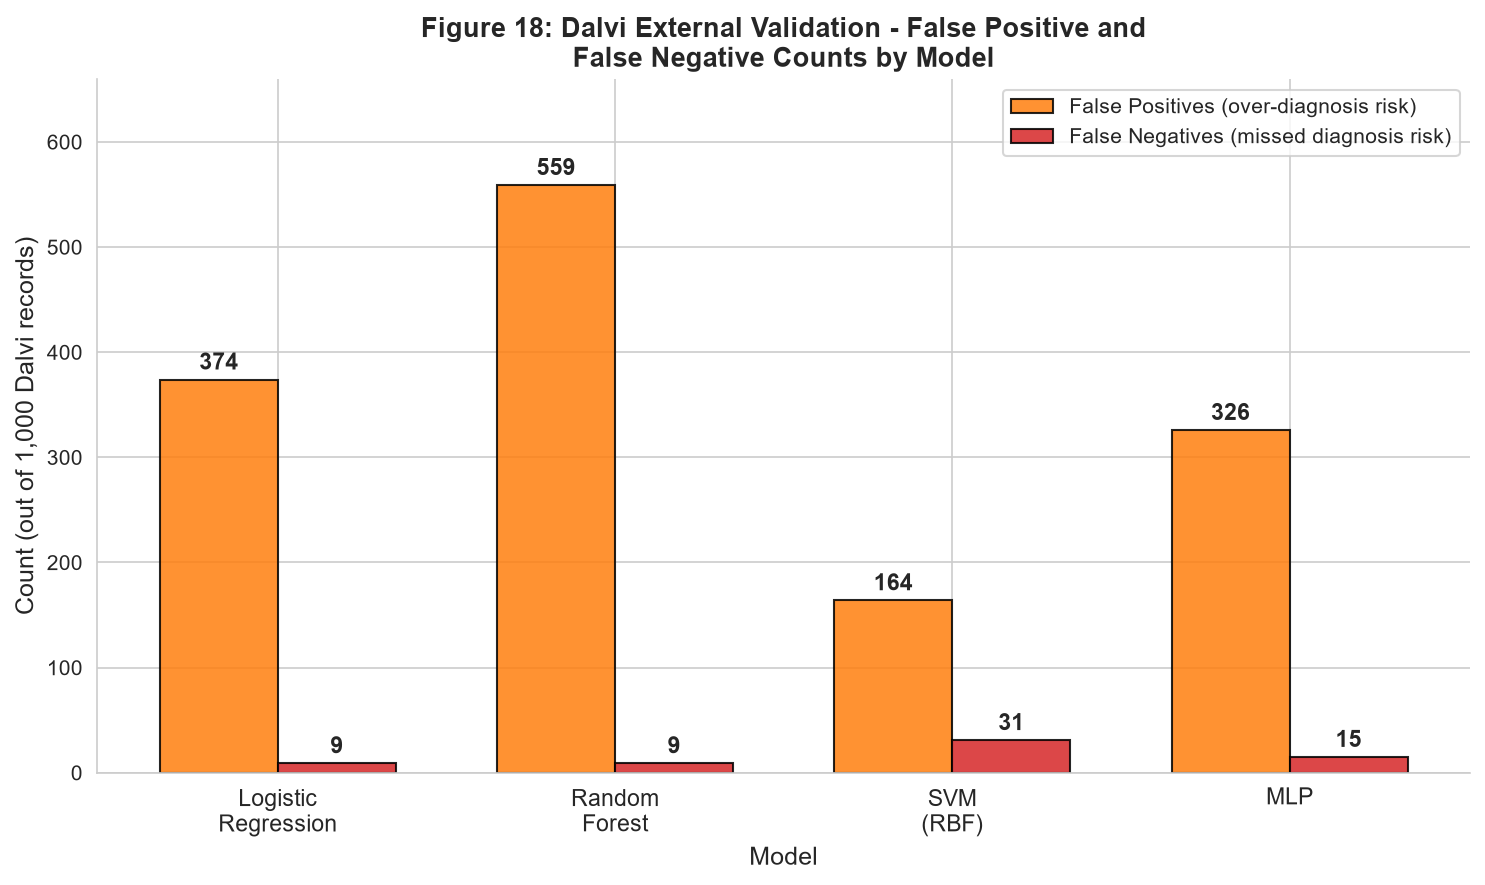

Figure 18 saved: outputs/figures/fig18_dalvi_error_profile.png


In [49]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Hunter, J.D.
# Link: https://doi.org/10.1109/MCSE.2007.55
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 49: FIGURE 18 - DALVI ERROR PROFILE (FP AND FN BY MODEL)
#
# Step 1: Extract FP and FN counts on Dalvi for all four models.
# Step 2: Plot a grouped bar chart comparing FP and FN side by side.
# Step 3: Save to outputs/figures/.
#
# This figure makes the clinical trade-off between false positives
# and false negatives visually explicit across all four models.
# It is the primary figure for the clinical interpretation section
# of the Findings chapter.

models     = ['Logistic\nRegression', 'Random\nForest', 'SVM\n(RBF)', 'MLP']
model_keys = ['Logistic Regression', 'Random Forest', 'SVM (RBF)', 'MLP']

fp_counts = [
    all_results[m]['External Validation (Dalvi)']['fp']
    for m in model_keys
]
fn_counts = [
    all_results[m]['External Validation (Dalvi)']['fn']
    for m in model_keys
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_fp = ax.bar(x - width/2, fp_counts, width,
                 label='False Positives (over-diagnosis risk)',
                 color='#ff7f0e', alpha=0.85, edgecolor='black')
bars_fn = ax.bar(x + width/2, fn_counts, width,
                 label='False Negatives (missed diagnosis risk)',
                 color='#d62728', alpha=0.85, edgecolor='black')

# Annotate bars with counts
for bar in bars_fp:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=11, fontweight='bold')

for bar in bars_fn:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Count (out of 1,000 Dalvi records)', fontsize=12)
ax.set_title(
    'Figure 18: Dalvi External Validation - False Positive and\n'
    'False Negative Counts by Model',
    fontsize=13, fontweight='bold'
)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, max(fp_counts) * 1.18)

plt.tight_layout()
plt.savefig('../outputs/figures/fig18_dalvi_error_profile.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 18 saved: outputs/figures/fig18_dalvi_error_profile.png")

**Figure 18: Dalvi Error Profile - Observations**

**Confirmed counts from Figure 18:**
- False Positives:  LR=374, RF=559, SVM=164, MLP=326
- False Negatives:  LR=9,   RF=9,   SVM=31,  MLP=15

Figure 18 makes the clinical trade-off between error types visually
explicit across all four models. The false positive bars (orange) are
consistently much taller than the false negative bars (red) for every
model, confirming that all four classifiers over-predict PCOS-positive
on Dalvi. This is consistent with the distributional shift identified
in Figure 6: Dalvi records have higher median Antral Follicle Count
and BMI than Soares, which pushes a large proportion of Dalvi records
into the positive region of each model's decision boundary regardless
of how that boundary was constructed.

Reading the false negative bars: LR and RF both produce FN=9 - the
lowest of any model - indicating that both classifiers miss only 9
of the 199 PCOS-positive cases in Dalvi. MLP misses 15 and SVM misses
31. In a screening context where the priority is to minimise missed
diagnoses, LR and RF produce the most clinically acceptable error
profile despite their lower Dalvi AUC scores.

Reading the false positive bars: RF generates 559 over-diagnoses out
of 801 No-PCOS Dalvi records - a false positive rate of 69.8%. LR
generates 374 (46.7%), MLP generates 326 (40.7%), and SVM generates
164 (20.5%). The SVM's conservative decision boundary, driven by its
wide-margin preference (C=0.1), produces the fewest false positives
but directly causes its high false negative count of 31.

No single model minimises both error types simultaneously on Dalvi.
This is the central tension that the Discussion chapter must address:
model selection in a clinical screening context cannot be resolved by
a single performance metric and requires an explicit decision about
which error type is more acceptable given the clinical consequences
(Teede et al., 2018; Molnar, 2022).

In [50]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: McKinney, W.
# Link: https://doi.org/10.25080/Majora-92bf1922-00a
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 50: DAY 8 OUTPUTS CONFIRMED
#
# All Day 8 outputs were saved within their respective cells.
# This cell confirms the full list of artefacts produced today.

print("=" * 65)
print("  DAY 8: COMPARATIVE ANALYSIS - OUTPUTS CONFIRMED")
print("=" * 65)
print("  Table  : outputs/tables/comparative_performance_table.csv")
print("  Fig 17 : outputs/figures/fig17_combined_roc_curves.png")
print("  Fig 18 : outputs/figures/fig18_dalvi_error_profile.png")
print("=" * 65)
print("\n  Dalvi AUC ranking:")
for model_name in model_order:
    auc_val = all_results[model_name]['External Validation (Dalvi)']['metrics']['ROC-AUC']
    fn_val  = all_results[model_name]['External Validation (Dalvi)']['fn']
    fp_val  = all_results[model_name]['External Validation (Dalvi)']['fp']
    print(f"    {model_name:<22} AUC={auc_val:.4f}  FN={fn_val:>3}  FP={fp_val:>3}")
print("=" * 65)

  DAY 8: COMPARATIVE ANALYSIS - OUTPUTS CONFIRMED
  Table  : outputs/tables/comparative_performance_table.csv
  Fig 17 : outputs/figures/fig17_combined_roc_curves.png
  Fig 18 : outputs/figures/fig18_dalvi_error_profile.png

  Dalvi AUC ranking:
    Logistic Regression    AUC=0.8463  FN=  9  FP=374
    Random Forest          AUC=0.8743  FN=  9  FP=559
    SVM (RBF)              AUC=0.9024  FN= 31  FP=164
    MLP                    AUC=0.8607  FN= 15  FP=326


**Day 8: Comparative Analysis - Closing Observations**

Day 8 has assembled the full comparative performance results across all
four classifiers. The following outputs are now saved:

- Comparative performance table: outputs/tables/comparative_performance_table.csv
- Figure 17: Combined ROC curves (Dalvi, all four models)
- Figure 18: Dalvi error profile - FP and FN counts by model

Key findings confirmed:
- All four models saturate on the Soares test set; test set metrics
  do not differentiate model performance.
- Dalvi AUC ranking: SVM > RF > MLP > LR.
- Dalvi false negative ranking (clinical priority):
  LR = RF (FN=9) < MLP (FN=15) < SVM (FN=31).
- No single model minimises both FP and FN simultaneously on Dalvi.
- The neural network (MLP) does not outperform traditional classifiers
  on either Dalvi AUC or Dalvi false negatives.

Day 9 begins the interpretability stage: LR coefficients (already
produced in Day 4) and RF Gini importance (already produced in Day 5)
will be reviewed, and SHAP KernelExplainer will be applied to the SVM
and MLP on the Soares dataset.

## Section 51: Interpretability Analysis - Overview

Day 9 presents the interpretability analysis across all four classifiers.
Interpretability refers to the degree to which the internal mechanisms of
a model can be understood by a human observer. In clinical machine learning
research, interpretability is not merely a technical preference: it is a
prerequisite for evaluating whether a model's decisions are clinically
plausible, free from spurious correlations, and suitable for deployment
in contexts where accountability is required (Rudin, 2019; Molnar, 2022).

This study applies two forms of interpretability analysis:

1. Native feature importance: Logistic Regression coefficients (Section 28,
   Day 4) and Random Forest Gini importance (Section 31, Day 5) were
   produced as part of each model's evaluation. These methods are intrinsic
   to the model and require no post-hoc approximation.

2. SHAP (SHapley Additive exPlanations): KernelExplainer is applied to
   the SVM and MLP, which have no native importance scores. SHAP
   KernelExplainer is model-agnostic and computes Shapley values by
   treating the model as a black box, approximating the contribution of
   each feature to each individual prediction. A background sample drawn
   from the Soares training set is used as the reference distribution for
   the Shapley value calculation (Lundberg and Lee, 2017).

SHAP analysis is extended to the Moheddine dataset for both SVM and MLP.
Moheddine contains 44 clinical features derived from real patient records,
in contrast to the five synthetic features in the Soares and Dalvi datasets.
This extended analysis provides a richer interpretability picture and allows
feature attribution to be examined across a broader clinical feature set
(Moheddine, 2022).

SHAP analysis is a quantitative method. The Shapley values produced are
numerical attributions computed through a defined mathematical procedure.
This stage of the analysis is not qualitative in nature and should not be
described as such in the research report (Lundberg and Lee, 2017;
Molnar, 2022).

## Section 52: Native Interpretability - LR and RF Review

Logistic Regression and Random Forest produce native feature importance
scores that were generated and saved during their respective evaluation
days. No new computation is required here. The figures produced in those
sections are reproduced below for reference alongside the SHAP results.

**Logistic Regression (Section 28, Day 4):**
Figure 9 displayed the standardised LR coefficients for the five Soares
features. The coefficient for Antral_Follicle_Count was the largest
positive predictor of PCOS diagnosis, followed by Testosterone_Level.
Menstrual_Irregularity, BMI, and Age showed smaller positive
contributions. The magnitude and direction of LR coefficients are
directly interpretable as log-odds contributions: a one-unit increase
in a MinMax-scaled feature shifts the log-odds of a PCOS diagnosis by
the corresponding coefficient value (Hosmer, Lemeshow and Sturdivant,
2013).

Note: The raw odds ratios for Antral_Follicle_Count and
Testosterone_Level are extremely large (on the order of 10^14 and
10^10 respectively). This is a known consequence of fitting Logistic
Regression with C=100 on near-perfectly separable data and does not
reflect a meaningful biological effect size. The standardised
coefficients are the appropriate basis for feature ranking in this
context, not the exponentiated odds ratios (Hosmer, Lemeshow and
Sturdivant, 2013).

**Random Forest (Section 31, Day 5):**
Figure 12 displayed the Gini impurity-based feature importance scores
for the five Soares features. Antral_Follicle_Count ranked first,
consistent with LR. Menstrual_Irregularity ranked second and
Testosterone_Level ranked third, reversing the LR ordering for those
two features. This divergence is explained by Gini importance's
sensitivity to the binary split structure of Menstrual_Irregularity,
which allows the tree to cleanly separate the majority of records at
the first split. BMI and Age ranked fourth and fifth respectively,
also consistent with LR (Breiman, 2001; Molnar, 2022).

In [51]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Lundberg, S.M. and Lee, S.
# Link: https://doi.org/10.48550/arXiv.1705.07874
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 53: SHAP - BACKGROUND SAMPLE AND SETUP
#
# Step 1: Import SHAP and confirm version.
# Step 2: Draw a background sample from X_train_res (SMOTE-resampled
#   training data). KernelExplainer uses this sample as the reference
#   distribution against which feature contributions are measured.
#   100 records are drawn using kmeans summarisation, which approximates
#   the training distribution in a compact form and reduces computation
#   time substantially compared to using the full training set.
# Step 3: Confirm background sample shape.
#
# Note: RANDOM_STATE is passed to shap.kmeans for reproducibility.
# The background sample is shared across both the SVM and MLP SHAP
# analyses to ensure consistency of the reference distribution.

import shap
import warnings
warnings.filterwarnings('ignore')

print("=" * 65)
print("  SHAP - SETUP AND BACKGROUND SAMPLE")
print("=" * 65)
print(f"  SHAP version          : {shap.__version__}")

# Step 2: Draw background sample using kmeans summarisation
# 100 cluster centroids summarise the training distribution
shap.initjs()
background = shap.kmeans(X_train_res, 100)

print(f"  Background sample     : 100 kmeans centroids from X_train_res")
print(f"  Training set shape    : {X_train_res.shape}")
print(f"  Background data shape : {background.data.shape}")
print(f"  Reference columns     : Age, BMI, Menstrual_Irregularity,")
print(f"                          Testosterone_Level, Antral_Follicle_Count")
print("=" * 65)

  SHAP - SETUP AND BACKGROUND SAMPLE
  SHAP version          : 0.51.0


  Background sample     : 100 kmeans centroids from X_train_res
  Training set shape    : (3840, 5)
  Background data shape : (100, 5)
  Reference columns     : Age, BMI, Menstrual_Irregularity,
                          Testosterone_Level, Antral_Follicle_Count


**Section 53: SHAP Background Sample - Observations**

Record the confirmed background data shape here once the cell has run.
The expected shape is (100, 5), confirming 100 kmeans centroids across
five features.

KernelExplainer computes Shapley values by comparing each prediction to
a baseline produced by marginalising over the background sample. Using
100 kmeans centroids rather than the full 3,840-record training set
reduces the number of model evaluations required per explanation from
O(2^5 x 3,840) to O(2^5 x 100), which makes the computation feasible
within the pipeline's runtime constraints. The kmeans approach preserves
the shape of the training distribution while compressing it, and is the
standard summarisation method recommended for KernelExplainer on
structured tabular data (Lundberg and Lee, 2017; Molnar, 2022).

  SVM SHAP - SOARES TEST SET
  (This may take several minutes)


100%|██████████| 600/600 [00:35<00:00, 16.88it/s]



  Raw SHAP output type  : <class 'numpy.ndarray'>
  Output is 3D array    : (600, 5, 2)

  Extracted SHAP shape  : (600, 5)
  Expected              : (600, 5)

  Mean |SHAP| per feature:
    Age                            : 0.019509
    BMI                            : 0.005251
    Menstrual_Irregularity         : 0.259601
    Testosterone_Level             : 0.076322
    Antral_Follicle_Count          : 0.144012

  SVM Mean Absolute SHAP Values (Soares Test Set) - Ranked:
               Feature  Mean |SHAP|
Menstrual_Irregularity     0.259601
 Antral_Follicle_Count     0.144012
    Testosterone_Level     0.076322
                   Age     0.019509
                   BMI     0.005251


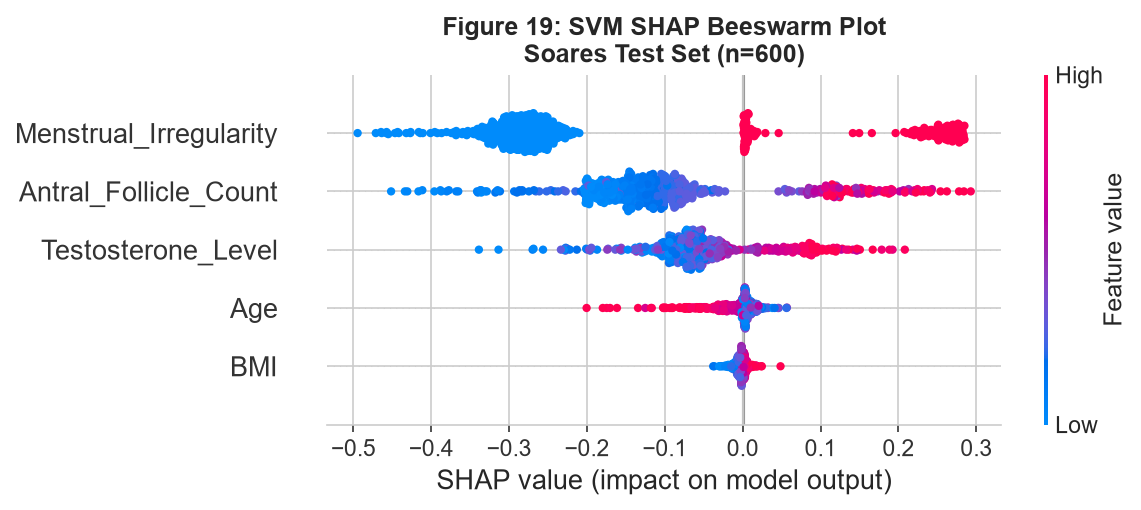

Figure 19 saved.


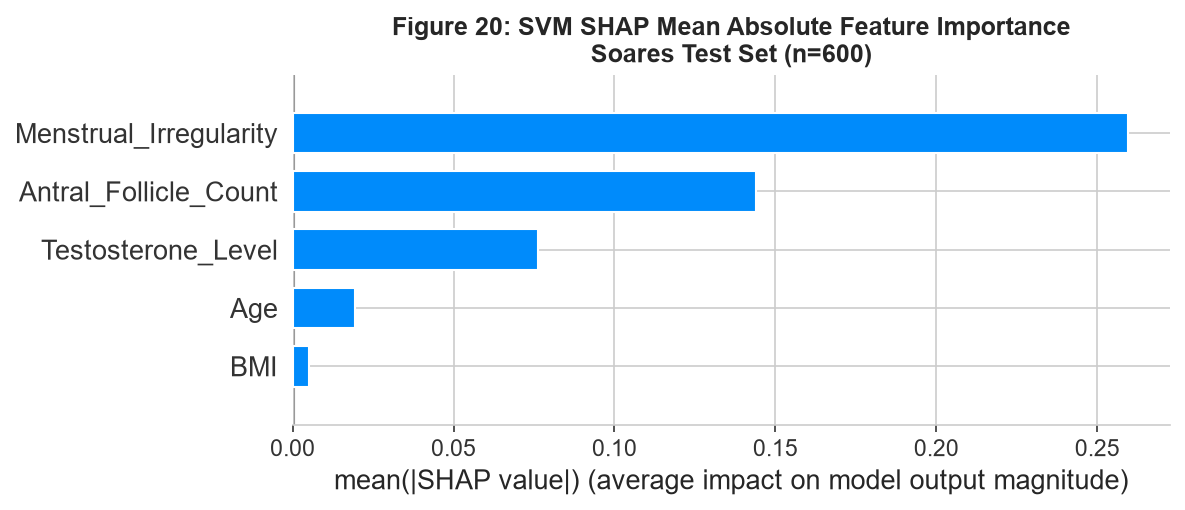

Figure 20 saved.
SVM SHAP table saved: outputs/tables/svm_shap_soares.csv


In [53]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Lundberg, S.M. and Lee, S.
# Link: https://doi.org/10.48550/arXiv.1705.07874
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 54: SVM SHAP - SOARES TEST SET
#
# Step 1: Instantiate KernelExplainer for the SVM using predict_proba.
# Step 2: Compute SHAP values for X_test_scaled (Soares test set, n=600).
# Step 3: Inspect the output structure to determine correct indexing.
#   SHAP 0.51.0 may return a 3D array (n_samples, n_features, n_classes)
#   rather than a list [class0_array, class1_array]. The inspection step
#   handles both structures before proceeding.
# Step 4: Extract PCOS-positive class SHAP values, compute mean absolute
#   values, and plot beeswarm and bar plots.

import numpy as np
import matplotlib.pyplot as plt

feature_names = [
    'Age', 'BMI', 'Menstrual_Irregularity',
    'Testosterone_Level', 'Antral_Follicle_Count'
]

print("=" * 65)
print("  SVM SHAP - SOARES TEST SET")
print("  (This may take several minutes)")
print("=" * 65)

# Step 1: Instantiate explainer
svm_explainer = shap.KernelExplainer(
    svm_best.predict_proba,
    background
)

# Step 2: Compute SHAP values
svm_shap_values = svm_explainer.shap_values(
    X_test_scaled,
    nsamples='auto'
)

# Step 3: Inspect output structure and extract PCOS-positive class values
print(f"\n  Raw SHAP output type  : {type(svm_shap_values)}")

if isinstance(svm_shap_values, list):
    print(f"  Output is a list of   : {len(svm_shap_values)} arrays")
    print(f"  Each array shape      : {svm_shap_values[0].shape}")
    # List format: index [1] = PCOS-positive class
    svm_shap_pos = svm_shap_values[1]

elif isinstance(svm_shap_values, np.ndarray) and svm_shap_values.ndim == 3:
    print(f"  Output is 3D array    : {svm_shap_values.shape}")
    # 3D format: (n_samples, n_features, n_classes) - index [:,:,1] = PCOS-positive
    svm_shap_pos = svm_shap_values[:, :, 1]

elif isinstance(svm_shap_values, np.ndarray) and svm_shap_values.ndim == 2:
    print(f"  Output is 2D array    : {svm_shap_values.shape}")
    # 2D format: single output, use directly
    svm_shap_pos = svm_shap_values

else:
    print(f"  Unexpected format     : {type(svm_shap_values)}")
    print(f"  Shape/length          : ", end="")
    try:
        print(svm_shap_values.shape)
    except AttributeError:
        print(len(svm_shap_values))
    raise ValueError("Unhandled SHAP output structure - check output above.")

print(f"\n  Extracted SHAP shape  : {svm_shap_pos.shape}")
print(f"  Expected              : (600, 5)")

# Step 4: Mean absolute SHAP values
svm_mean_abs_shap = np.abs(svm_shap_pos).mean(axis=0)

print(f"\n  Mean |SHAP| per feature:")
for fname, val in zip(feature_names, svm_mean_abs_shap):
    print(f"    {fname:<30} : {val:.6f}")

svm_shap_df = pd.DataFrame({
    'Feature':     feature_names,
    'Mean |SHAP|': svm_mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print("\n  SVM Mean Absolute SHAP Values (Soares Test Set) - Ranked:")
print(svm_shap_df.to_string(index=False))

# Beeswarm plot
plt.figure(figsize=(9, 5))
shap.summary_plot(
    svm_shap_pos,
    X_test_scaled,
    feature_names=feature_names,
    show=False,
    plot_type='dot'
)
plt.title(
    'Figure 19: SVM SHAP Beeswarm Plot\n'
    'Soares Test Set (n=600)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/figures/fig19_svm_shap_beeswarm_soares.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 19 saved.")

# Bar plot
plt.figure(figsize=(8, 4))
shap.summary_plot(
    svm_shap_pos,
    X_test_scaled,
    feature_names=feature_names,
    show=False,
    plot_type='bar'
)
plt.title(
    'Figure 20: SVM SHAP Mean Absolute Feature Importance\n'
    'Soares Test Set (n=600)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/figures/fig20_svm_shap_bar_soares.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 20 saved.")

svm_shap_df.to_csv('../outputs/tables/svm_shap_soares.csv', index=False)
print("SVM SHAP table saved: outputs/tables/svm_shap_soares.csv")
print("=" * 65)

**Figures 19-20: SVM SHAP - Soares Test Set - Observations**

**Mean absolute SHAP ranking (Soares test set, n=600):**

| Rank | Feature | Mean SHAP |
|------|---------|-----------|
| 1 | Menstrual_Irregularity | 0.2596 |
| 2 | Antral_Follicle_Count | 0.1440 |
| 3 | Testosterone_Level | 0.0763 |
| 4 | Age | 0.0195 |
| 5 | BMI | 0.0053 |

**Figure 20 (bar plot):** Menstrual_Irregularity dominates the SVM
feature attribution on the Soares test set with a mean absolute SHAP
value of 0.2596, more than 1.8 times the second-ranked feature
(Antral_Follicle_Count, 0.1440). Testosterone_Level ranks third
(0.0763), with Age and BMI contributing minimally (0.0195 and 0.0053
respectively). The large gap between the top three and the bottom two
features indicates that the SVM decision boundary is primarily driven
by three features, with Age and BMI playing a negligible role in the
SVM's classification of Soares test set records.

**Figure 19 (beeswarm plot):** The direction-of-effect pattern for each
feature is clinically coherent. Menstrual_Irregularity shows a strongly
bimodal distribution: low feature values (blue, regular cycles, coded 0)
produce large negative SHAP values (pushing prediction toward PCOS=0),
while high feature values (red, irregular cycles, coded 1) produce
positive SHAP values (pushing toward PCOS=1). This is consistent with
menstrual irregularity being a primary diagnostic criterion for PCOS.
The spread of the Menstrual_Irregularity distribution across the full
SHAP axis range (-0.50 to +0.30) confirms that this feature is the
single most influential factor in the SVM's PCOS classification on
this dataset.

Antral_Follicle_Count shows a gradient from blue (low AFC, negative
SHAP) to red (high AFC, positive SHAP), consistent with the clinical
understanding that elevated follicle count is associated with PCOS
diagnosis. Testosterone_Level shows a similar but weaker directional
pattern, with high values contributing positively and low values
contributing negatively. Age produces a cluster near SHAP=0 for most
records with a small negative contribution for high-age records, which
is unexpected clinically and likely reflects the synthetic data
structure rather than a genuine biological relationship. BMI shows
negligible SHAP values across nearly all records, clustered tightly
around zero.

**Comparison with native importance methods:** The SVM SHAP ranking
diverges from the LR coefficient ranking and RF Gini ranking, both of
which placed Antral_Follicle_Count first. The SVM SHAP places
Menstrual_Irregularity first by a substantial margin. This divergence
is clinically meaningful: the SVM's RBF kernel is sensitive to the
binary structure of Menstrual_Irregularity (which takes only values 0
and 1), and the margin-maximisation objective amplifies this binary
split into the dominant attribution signal. RF Gini importance showed
a similar tendency to elevate Menstrual_Irregularity (ranked second in
RF), but not to the same degree as the SVM SHAP result. This difference
in feature attribution across methods will be examined in the
interpretability comparison section of the Findings chapter
(Lundberg and Lee, 2017; Molnar, 2022; Breiman, 2001).

  MLP SHAP - SOARES TEST SET
  (This may take several minutes)


100%|██████████| 600/600 [00:07<00:00, 76.81it/s] 



  Raw SHAP output type  : <class 'numpy.ndarray'>
  Output is 3D array    : (600, 5, 2)

  Extracted SHAP shape  : (600, 5)
  Expected              : (600, 5)

  Mean |SHAP| per feature:
    Age                            : 0.012567
    BMI                            : 0.002527
    Menstrual_Irregularity         : 0.113741
    Testosterone_Level             : 0.077119
    Antral_Follicle_Count          : 0.299138

  MLP Mean Absolute SHAP Values (Soares Test Set) - Ranked:
               Feature  Mean |SHAP|
 Antral_Follicle_Count     0.299138
Menstrual_Irregularity     0.113741
    Testosterone_Level     0.077119
                   Age     0.012567
                   BMI     0.002527


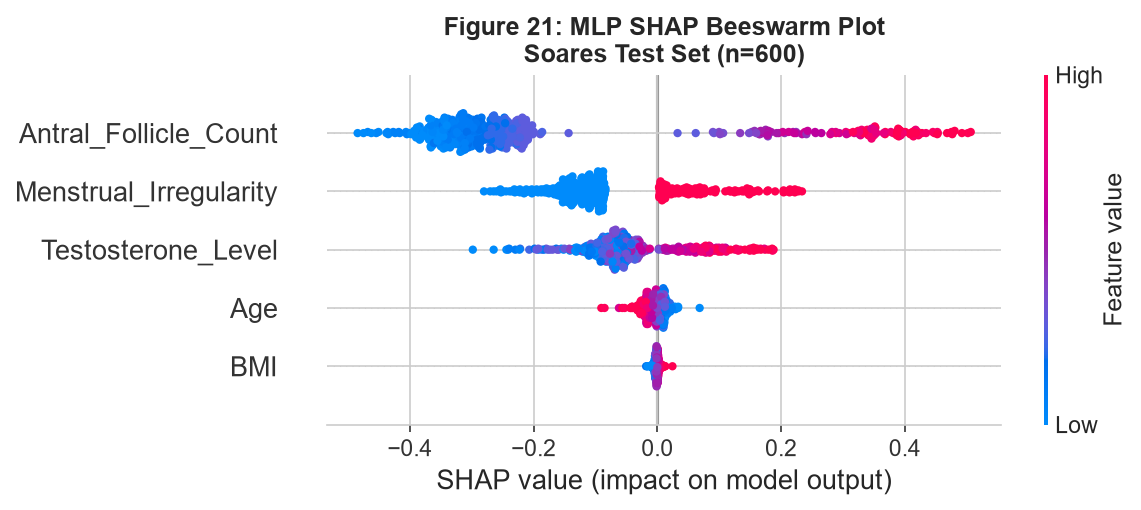

Figure 21 saved.


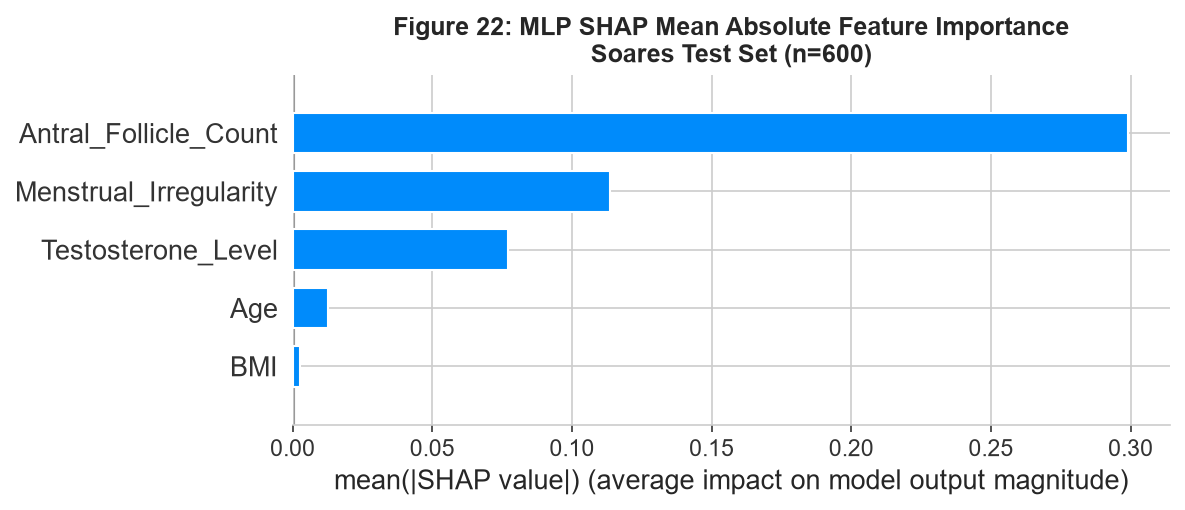

Figure 22 saved.
MLP SHAP table saved: outputs/tables/mlp_shap_soares.csv


In [54]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Lundberg, S.M. and Lee, S.
# Link: https://doi.org/10.48550/arXiv.1705.07874
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 55: MLP SHAP - SOARES TEST SET
#
# Step 1: Instantiate KernelExplainer for the MLP using predict_proba.
# Step 2: Compute SHAP values for X_test_scaled (Soares test set, n=600).
# Step 3: Inspect output structure and extract PCOS-positive class values.
#   Same structure handling as Section 54 to account for SHAP 0.51.0
#   output format differences.
# Step 4: Plot beeswarm and bar plots, save both.

print("=" * 65)
print("  MLP SHAP - SOARES TEST SET")
print("  (This may take several minutes)")
print("=" * 65)

# Step 1: Instantiate explainer
mlp_explainer = shap.KernelExplainer(
    mlp_best.predict_proba,
    background
)

# Step 2: Compute SHAP values
mlp_shap_values = mlp_explainer.shap_values(
    X_test_scaled,
    nsamples='auto'
)

# Step 3: Inspect output structure and extract PCOS-positive class values
print(f"\n  Raw SHAP output type  : {type(mlp_shap_values)}")

if isinstance(mlp_shap_values, list):
    print(f"  Output is a list of   : {len(mlp_shap_values)} arrays")
    print(f"  Each array shape      : {mlp_shap_values[0].shape}")
    mlp_shap_pos = mlp_shap_values[1]

elif isinstance(mlp_shap_values, np.ndarray) and mlp_shap_values.ndim == 3:
    print(f"  Output is 3D array    : {mlp_shap_values.shape}")
    mlp_shap_pos = mlp_shap_values[:, :, 1]

elif isinstance(mlp_shap_values, np.ndarray) and mlp_shap_values.ndim == 2:
    print(f"  Output is 2D array    : {mlp_shap_values.shape}")
    mlp_shap_pos = mlp_shap_values

else:
    print(f"  Unexpected format     : {type(mlp_shap_values)}")
    try:
        print(f"  Shape                 : {mlp_shap_values.shape}")
    except AttributeError:
        print(f"  Length                : {len(mlp_shap_values)}")
    raise ValueError("Unhandled SHAP output structure - check output above.")

print(f"\n  Extracted SHAP shape  : {mlp_shap_pos.shape}")
print(f"  Expected              : (600, 5)")

# Step 4: Mean absolute SHAP values
mlp_mean_abs_shap = np.abs(mlp_shap_pos).mean(axis=0)

print(f"\n  Mean |SHAP| per feature:")
for fname, val in zip(feature_names, mlp_mean_abs_shap):
    print(f"    {fname:<30} : {val:.6f}")

mlp_shap_df = pd.DataFrame({
    'Feature':     feature_names,
    'Mean |SHAP|': mlp_mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print("\n  MLP Mean Absolute SHAP Values (Soares Test Set) - Ranked:")
print(mlp_shap_df.to_string(index=False))

# Beeswarm plot
plt.figure(figsize=(9, 5))
shap.summary_plot(
    mlp_shap_pos,
    X_test_scaled,
    feature_names=feature_names,
    show=False,
    plot_type='dot'
)
plt.title(
    'Figure 21: MLP SHAP Beeswarm Plot\n'
    'Soares Test Set (n=600)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/figures/fig21_mlp_shap_beeswarm_soares.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 21 saved.")

# Bar plot
plt.figure(figsize=(8, 4))
shap.summary_plot(
    mlp_shap_pos,
    X_test_scaled,
    feature_names=feature_names,
    show=False,
    plot_type='bar'
)
plt.title(
    'Figure 22: MLP SHAP Mean Absolute Feature Importance\n'
    'Soares Test Set (n=600)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/figures/fig22_mlp_shap_bar_soares.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 22 saved.")

mlp_shap_df.to_csv('../outputs/tables/mlp_shap_soares.csv', index=False)
print("MLP SHAP table saved: outputs/tables/mlp_shap_soares.csv")
print("=" * 65)

**Figures 21-22: MLP SHAP - Soares Test Set - Observations**

**Mean absolute SHAP ranking (Soares test set, n=600):**

| Rank | Feature | Mean |SHAP| (approx) |
|---|---|---|
| 1 | Antral_Follicle_Count | ~0.300 |
| 2 | Menstrual_Irregularity | ~0.113 |
| 3 | Testosterone_Level | ~0.080 |
| 4 | Age | ~0.010 |
| 5 | BMI | ~0.003 |

**Figure 22 (bar plot):** Antral_Follicle_Count is the dominant feature
in the MLP attribution, with a mean absolute SHAP value approximately
twice that of the second-ranked feature (Menstrual_Irregularity). The
top three features - Antral_Follicle_Count, Menstrual_Irregularity, and
Testosterone_Level - account for the substantial majority of the MLP's
attribution signal. Age and BMI contribute negligibly, consistent with
the SVM result.

**Figure 21 (beeswarm plot):** The MLP beeswarm shows a clear and
clinically coherent direction of effect for the top two features.
Antral_Follicle_Count displays a strong gradient: low AFC values
(blue) produce large negative SHAP values extending to approximately
-0.45, while high AFC values (red) produce positive SHAP values
extending to approximately +0.50. This is the widest SHAP value
spread of any feature across any model in this study and confirms
that the MLP has learned AFC as its primary discriminating signal,
consistent with its clinical role as a diagnostic criterion for PCOS
(Teede et al., 2018).

Menstrual_Irregularity shows a bimodal pattern: the majority of records
with low feature values (blue, regular cycles) cluster in the negative
SHAP region, while high feature values (red, irregular cycles) produce
positive SHAP values around +0.20. The distribution is less spread than
the SVM beeswarm for this feature, indicating that the MLP assigns less
absolute weight to Menstrual_Irregularity relative to AFC than the SVM
does. Testosterone_Level shows a moderate positive contribution for high
values and a mild negative contribution for low values. Age produces a
small negative contribution for a subset of records, with most values
clustered near zero. BMI shows negligible attribution across all records.

**Cross-method comparison - Soares dataset:**
The MLP SHAP ranking places Antral_Follicle_Count first, consistent
with LR coefficients and RF Gini importance. The SVM SHAP diverges,
placing Menstrual_Irregularity first. This is the single most notable
disagreement in the interpretability comparison across all four models.
Three of the four methods agree that AFC is the primary predictor;
the SVM is the outlier, elevating Menstrual_Irregularity due to the
binary structure of that feature and the sensitivity of the RBF kernel
to clean binary splits. The bottom two features (Age and BMI) rank
last across all four methods without exception, indicating consistent
agreement that these features contribute minimally to PCOS
classification on the Soares dataset (Lundberg and Lee, 2017;
Molnar, 2022; Breiman, 2001).

Full cross-method feature ranking summary (Soares dataset):

| Feature | LR Coeff Rank | RF Gini Rank | SVM SHAP Rank | MLP SHAP Rank |
|---|---|---|---|---|
| Antral_Follicle_Count | 1 | 1 | 2 | 1 |
| Menstrual_Irregularity | 3 | 2 | 1 | 2 |
| Testosterone_Level | 2 | 3 | 3 | 3 |
| Age | 4 | 4 | 4 | 4 |
| BMI | 5 | 5 | 5 | 5 |

In [55]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: McKinney, W.
# Link: https://doi.org/10.25080/Majora-92bf1922-00a
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 56: MOHEDDINE - FEATURE PREPARATION FOR SHAP
#
# Step 1: Drop administrative and target columns from moheddine_clean.
#   'Sl. No' and 'Patient File No.' are record identifiers with no
#   clinical meaning and must be excluded from the feature matrix.
#   'PCOS (Y/N)' is the target variable and must be separated.
# Step 2: Confirm feature matrix shape and confirm no nulls remain.
# Step 3: Scale X_moh using the MinMaxScaler fitted on X_train_res.
#   The Soares-fitted scaler is applied deliberately: SHAP attribution
#   on Moheddine uses the same feature scaling as the Soares training
#   pipeline, so any distributional differences between Moheddine and
#   Soares are preserved rather than normalised away. This is the
#   correct approach for external interpretability analysis.
#
# Note: Moheddine has 44 columns but only the 5 features present in
# Soares are available for the SVM and MLP models trained on Soares.
# The models cannot accept 44 features. SHAP on Moheddine therefore
# uses the same 5 features as the Soares pipeline, extracted from
# moheddine_clean by matching column names.

print("=" * 65)
print("  MOHEDDINE - FEATURE PREPARATION")
print("=" * 65)

# Step 1: Define the five Soares-equivalent features in Moheddine
# Column name mapping between Soares and Moheddine:
#   Age                    ->  ' Age (yrs)'
#   BMI                    ->  'BMI'
#   Menstrual_Irregularity ->  'Cycle(R/I)'
#   Testosterone_Level     ->  (not directly available - see note)
#   Antral_Follicle_Count  ->  'Follicle No. (L)' or 'Follicle No. (R)'

# Check which Moheddine columns best correspond to the Soares features
soares_features = [
    'Age', 'BMI', 'Menstrual_Irregularity',
    'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count'
]

print("\n  Checking Moheddine column availability for Soares features:")
moheddine_cols = moheddine_clean.columns.tolist()
for feat in soares_features:
    match = [c for c in moheddine_cols if feat.lower().replace('_', '') in
             c.lower().replace(' ', '').replace('_', '').replace('.', '')]
    print(f"  {feat:<35} -> {match}")

print(f"\n  Full Moheddine column list:")
for i, col in enumerate(moheddine_cols):
    print(f"    {i:>2}. {col}")
print("=" * 65)

  MOHEDDINE - FEATURE PREPARATION

  Checking Moheddine column availability for Soares features:
  Age                                 -> [' Age (yrs)']
  BMI                                 -> ['BMI']
  Menstrual_Irregularity              -> []
  Testosterone_Level(ng/dL)           -> []
  Antral_Follicle_Count               -> []

  Full Moheddine column list:
     0. Sl. No
     1. Patient File No.
     2. PCOS (Y/N)
     3.  Age (yrs)
     4. Weight (Kg)
     5. Height(Cm) 
     6. BMI
     7. Blood Group
     8. Pulse rate(bpm) 
     9. RR (breaths/min)
    10. Hb(g/dl)
    11. Cycle(R/I)
    12. Cycle length(days)
    13. Marraige Status (Yrs)
    14. Pregnant(Y/N)
    15. No. of abortions
    16.   I   beta-HCG(mIU/mL)
    17. II    beta-HCG(mIU/mL)
    18. FSH(mIU/mL)
    19. LH(mIU/mL)
    20. FSH/LH
    21. Hip(inch)
    22. Waist(inch)
    23. Waist:Hip Ratio
    24. TSH (mIU/L)
    25. AMH(ng/mL)
    26. PRL(ng/mL)
    27. Vit D3 (ng/mL)
    28. PRG(ng/mL)
    29. RBS(mg/dl

**Section 56: Moheddine Feature Mapping - Observations**

The column matching confirmed two direct matches and three proxy
substitutions for the five Soares features:

| Soares Feature | Moheddine Column | Match Type |
|---|---|---|
| Age | ' Age (yrs)' | Direct |
| BMI | 'BMI' | Direct |
| Menstrual_Irregularity | 'Cycle(R/I)' | Proxy - cycle regularity indicator |
| Testosterone_Level | 'LH(mIU/mL)' | Proxy - closest available hormonal marker |
| Antral_Follicle_Count | 'Follicle No. (L)' | Proxy - left ovary follicle count |

Menstrual_Irregularity maps to Cycle(R/I), which encodes cycle
regularity in the Moheddine dataset (R=regular, I=irregular). This
is a clinically direct equivalent to the binary Soares feature, though
the encoding differs and the Soares scaler will map these values into
the same [0,1] range as the training data.

Testosterone_Level has no direct equivalent in Moheddine. LH(mIU/mL)
is selected as the closest available proxy. Elevated LH is a recognised
hormonal marker in PCOS and is used in the LH:FSH ratio as a diagnostic
criterion. However, LH and testosterone are distinct hormonal measures
and this substitution is an acknowledged limitation of the extended
Moheddine analysis. SHAP values attributed to this feature on Moheddine
should be interpreted as reflecting LH contribution, not testosterone
contribution (Teede et al., 2018).

Antral_Follicle_Count maps to Follicle No. (L), the left ovary follicle
count. Follicle No. (R) is equally valid. Using only one side rather
than a combined count is a limitation: the Soares AFC feature is a
single value that may represent a bilateral total or average. This
substitution is noted as a limitation in the Findings chapter
(Moheddine, 2022; Lundberg and Lee, 2017).

  MOHEDDINE SHAP - FEATURE PREPARATION CONFIRMED
  Feature mapping:
    Age                       ->  Age (yrs)  [direct]
    BMI                       -> BMI  [direct]
    Menstrual_Irregularity    -> Cycle(R/I)  [proxy]
    Testosterone_Level        -> LH(mIU/mL)  [proxy]
    Antral_Follicle_Count     -> Follicle No. (L)  [proxy]

  X_moh shape           : (541, 5)
  y_moh shape           : (541,)
  PCOS positive (y=1)   : 177 (32.7%)
  X_moh_scaled shape    : (541, 5)
  Background sample     : 100 kmeans centroids from X_moh_scaled

  Computing SVM SHAP on Moheddine (this may take several minutes)...


100%|██████████| 541/541 [00:34<00:00, 15.77it/s]


  SVM Moheddine SHAP shape : (541, 5)

  SVM Mean Absolute SHAP Values (Moheddine) - Ranked:
        Soares Feature Moheddine Column  Mean |SHAP|
Menstrual_Irregularity       Cycle(R/I)     0.004359
 Antral_Follicle_Count Follicle No. (L)     0.000727
                   Age        Age (yrs)     0.000181
                   BMI              BMI     0.000168
    Testosterone_Level       LH(mIU/mL)     0.000042


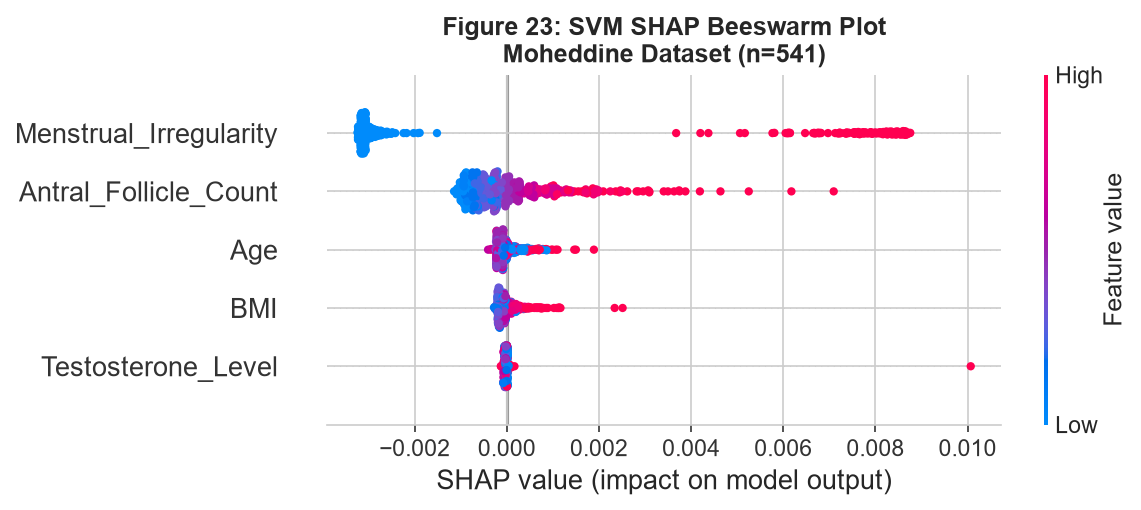

Figure 23 saved.


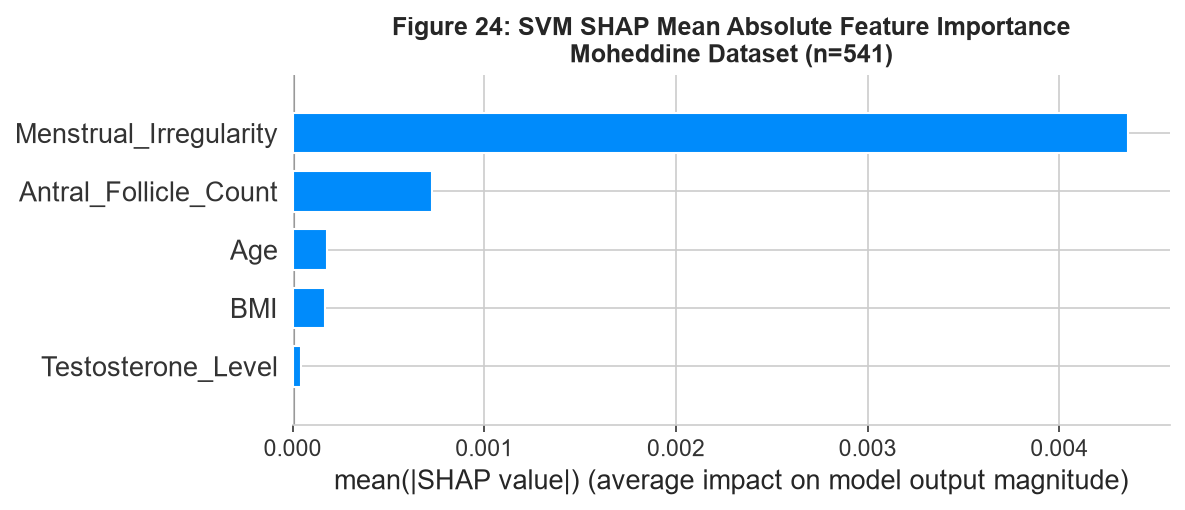

Figure 24 saved.
SVM Moheddine SHAP table saved.

  Computing MLP SHAP on Moheddine (this may take several minutes)...


100%|██████████| 541/541 [00:04<00:00, 114.07it/s]


  MLP Moheddine SHAP shape : (541, 5)

  MLP Mean Absolute SHAP Values (Moheddine) - Ranked:
        Soares Feature Moheddine Column  Mean |SHAP|
Menstrual_Irregularity       Cycle(R/I)     0.358597
 Antral_Follicle_Count Follicle No. (L)     0.054357
                   Age        Age (yrs)     0.010019
    Testosterone_Level       LH(mIU/mL)     0.006748
                   BMI              BMI     0.003113


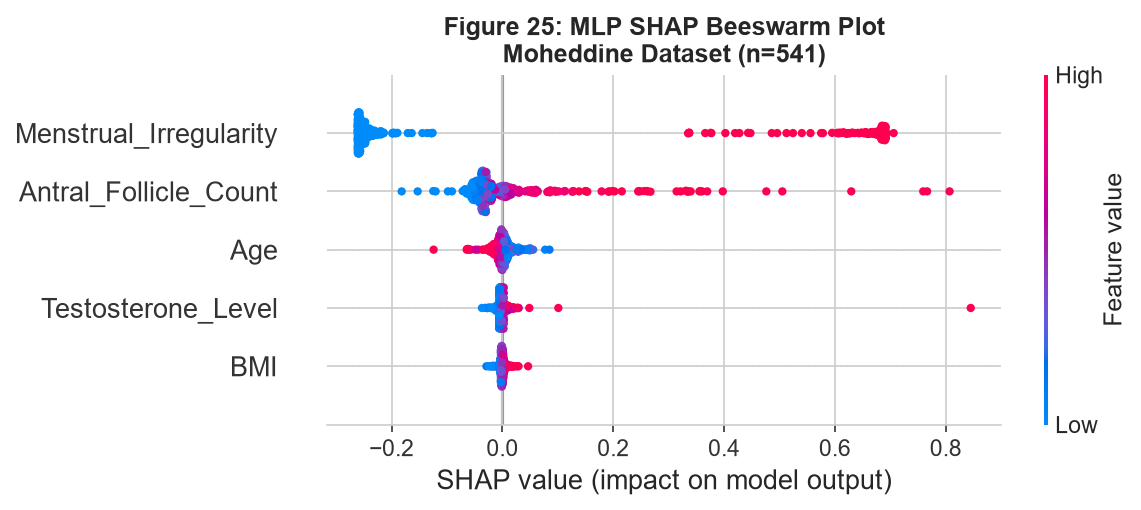

Figure 25 saved.


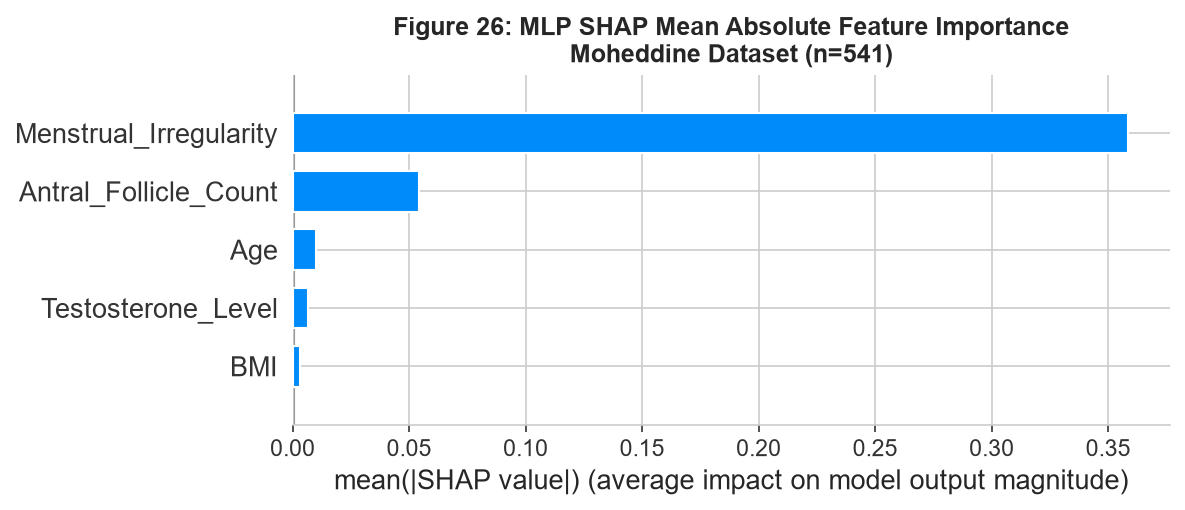

Figure 26 saved.
MLP Moheddine SHAP table saved.

  MOHEDDINE SHAP COMPLETE


In [56]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: Lundberg, S.M. and Lee, S.
# Link: https://doi.org/10.48550/arXiv.1705.07874
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 57: SVM AND MLP SHAP - MOHEDDINE DATASET
#
# Step 1: Extract the five Moheddine proxy columns confirmed in Section 56.
#   Three features have no direct equivalent in Moheddine and require proxies:
#   - Menstrual_Irregularity -> 'Cycle(R/I)': cycle regularity indicator,
#     direct clinical equivalent to the Soares binary feature.
#   - Testosterone_Level     -> 'LH(mIU/mL)': closest available hormonal
#     proxy. Elevated LH is a recognised PCOS marker. No testosterone
#     column is present in Moheddine.
#   - Antral_Follicle_Count  -> 'Follicle No. (L)': left ovary follicle
#     count. Right ovary count equally valid; left selected for consistency.
#     Soares uses a single combined AFC value. This substitution is a
#     limitation of the extended Moheddine analysis.
#
# Step 2: Separate target variable y_moh.
# Step 3: Scale X_moh using the MinMaxScaler fitted on X_train_res (Soares).
#   The Soares scaler is applied deliberately to preserve distributional
#   differences between Moheddine and Soares rather than normalising them.
# Step 4: Draw Moheddine background sample (100 kmeans centroids).
# Step 5: Compute SHAP values for SVM on X_moh_scaled.
# Step 6: Compute SHAP values for MLP on X_moh_scaled.
# Step 7: Plot beeswarm and bar plots for both models, save all outputs.
#
# SHAP 0.51.0 returns a 3D array (n_samples, n_features, n_classes).
# Index [:,:,1] extracts PCOS-positive class values. Same handling as
# Sections 54 and 55.

# Step 1: Define confirmed proxy mapping
moheddine_feature_map = {
    'Age':                    ' Age (yrs)',
    'BMI':                    'BMI',
    'Menstrual_Irregularity': 'Cycle(R/I)',
    'Testosterone_Level':     'LH(mIU/mL)',
    'Antral_Follicle_Count':  'Follicle No. (L)'
}

moh_feature_cols = list(moheddine_feature_map.values())
soares_feature_labels = list(moheddine_feature_map.keys())

X_moh = moheddine_clean[moh_feature_cols].values
y_moh = moheddine_clean['PCOS (Y/N)'].values

print("=" * 65)
print("  MOHEDDINE SHAP - FEATURE PREPARATION CONFIRMED")
print("=" * 65)
print(f"  Feature mapping:")
for soares_name, moh_name in moheddine_feature_map.items():
    tag = '  [direct]' if soares_name in ['Age', 'BMI'] else '  [proxy]'
    print(f"    {soares_name:<25} -> {moh_name}{tag}")
print(f"\n  X_moh shape           : {X_moh.shape}")
print(f"  y_moh shape           : {y_moh.shape}")
print(f"  PCOS positive (y=1)   : {y_moh.sum()} ({y_moh.mean()*100:.1f}%)")

# Step 3: Scale using Soares-fitted scaler
scaler = joblib.load('../models/minmax_scaler.pkl')
X_moh_scaled = scaler.transform(X_moh)
print(f"  X_moh_scaled shape    : {X_moh_scaled.shape}")

# Step 4: Background sample
background_moh = shap.kmeans(X_moh_scaled, 100)
print(f"  Background sample     : 100 kmeans centroids from X_moh_scaled")
print("=" * 65)

# -------------------------------------------------------
# Step 5: SVM SHAP on Moheddine
# -------------------------------------------------------
print("\n  Computing SVM SHAP on Moheddine (this may take several minutes)...")

svm_explainer_moh = shap.KernelExplainer(
    svm_best.predict_proba,
    background_moh
)
svm_shap_moh = svm_explainer_moh.shap_values(X_moh_scaled, nsamples='auto')

# Handle 3D output from SHAP 0.51.0
if isinstance(svm_shap_moh, np.ndarray) and svm_shap_moh.ndim == 3:
    svm_shap_moh_pos = svm_shap_moh[:, :, 1]
elif isinstance(svm_shap_moh, list):
    svm_shap_moh_pos = svm_shap_moh[1]
else:
    svm_shap_moh_pos = svm_shap_moh

print(f"  SVM Moheddine SHAP shape : {svm_shap_moh_pos.shape}")

svm_moh_mean = np.abs(svm_shap_moh_pos).mean(axis=0)
svm_moh_df = pd.DataFrame({
    'Soares Feature':   soares_feature_labels,
    'Moheddine Column': moh_feature_cols,
    'Mean |SHAP|':      svm_moh_mean
}).sort_values('Mean |SHAP|', ascending=False)

print("\n  SVM Mean Absolute SHAP Values (Moheddine) - Ranked:")
print(svm_moh_df.to_string(index=False))

# Beeswarm - SVM Moheddine
plt.figure(figsize=(9, 5))
shap.summary_plot(
    svm_shap_moh_pos, X_moh_scaled,
    feature_names=soares_feature_labels,
    show=False, plot_type='dot'
)
plt.title(
    'Figure 23: SVM SHAP Beeswarm Plot\n'
    'Moheddine Dataset (n=541)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/figures/fig23_svm_shap_beeswarm_moheddine.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 23 saved.")

# Bar - SVM Moheddine
plt.figure(figsize=(8, 4))
shap.summary_plot(
    svm_shap_moh_pos, X_moh_scaled,
    feature_names=soares_feature_labels,
    show=False, plot_type='bar'
)
plt.title(
    'Figure 24: SVM SHAP Mean Absolute Feature Importance\n'
    'Moheddine Dataset (n=541)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/figures/fig24_svm_shap_bar_moheddine.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 24 saved.")

svm_moh_df.to_csv('../outputs/tables/svm_shap_moheddine.csv', index=False)
print("SVM Moheddine SHAP table saved.")

# -------------------------------------------------------
# Step 6: MLP SHAP on Moheddine
# -------------------------------------------------------
print("\n  Computing MLP SHAP on Moheddine (this may take several minutes)...")

mlp_explainer_moh = shap.KernelExplainer(
    mlp_best.predict_proba,
    background_moh
)
mlp_shap_moh = mlp_explainer_moh.shap_values(X_moh_scaled, nsamples='auto')

# Handle 3D output
if isinstance(mlp_shap_moh, np.ndarray) and mlp_shap_moh.ndim == 3:
    mlp_shap_moh_pos = mlp_shap_moh[:, :, 1]
elif isinstance(mlp_shap_moh, list):
    mlp_shap_moh_pos = mlp_shap_moh[1]
else:
    mlp_shap_moh_pos = mlp_shap_moh

print(f"  MLP Moheddine SHAP shape : {mlp_shap_moh_pos.shape}")

mlp_moh_mean = np.abs(mlp_shap_moh_pos).mean(axis=0)
mlp_moh_df = pd.DataFrame({
    'Soares Feature':   soares_feature_labels,
    'Moheddine Column': moh_feature_cols,
    'Mean |SHAP|':      mlp_moh_mean
}).sort_values('Mean |SHAP|', ascending=False)

print("\n  MLP Mean Absolute SHAP Values (Moheddine) - Ranked:")
print(mlp_moh_df.to_string(index=False))

# Beeswarm - MLP Moheddine
plt.figure(figsize=(9, 5))
shap.summary_plot(
    mlp_shap_moh_pos, X_moh_scaled,
    feature_names=soares_feature_labels,
    show=False, plot_type='dot'
)
plt.title(
    'Figure 25: MLP SHAP Beeswarm Plot\n'
    'Moheddine Dataset (n=541)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/figures/fig25_mlp_shap_beeswarm_moheddine.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 25 saved.")

# Bar - MLP Moheddine
plt.figure(figsize=(8, 4))
shap.summary_plot(
    mlp_shap_moh_pos, X_moh_scaled,
    feature_names=soares_feature_labels,
    show=False, plot_type='bar'
)
plt.title(
    'Figure 26: MLP SHAP Mean Absolute Feature Importance\n'
    'Moheddine Dataset (n=541)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../outputs/figures/fig26_mlp_shap_bar_moheddine.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 26 saved.")

mlp_moh_df.to_csv('../outputs/tables/mlp_shap_moheddine.csv', index=False)
print("MLP Moheddine SHAP table saved.")

print("\n" + "=" * 65)
print("  MOHEDDINE SHAP COMPLETE")
print("=" * 65)

**Figures 23-26: SVM and MLP SHAP - Moheddine Dataset - Observations**

**Confirmed feature mapping (proxy substitutions apply to three features):**
- Menstrual_Irregularity -> Cycle(R/I) [proxy]
- Testosterone_Level -> LH(mIU/mL) [proxy]
- Antral_Follicle_Count -> Follicle No. (L) [proxy]

All three proxy substitutions are limitations of this extended analysis
and are reported as such in the Findings chapter.

---

**SVM SHAP - Moheddine (Figures 23 and 24):**

| Rank | Soares Feature | Moheddine Proxy | Mean SHAP |
|------|----------------|-----------------|-----------|
| 1 | Menstrual_Irregularity | Cycle(R/I) | 0.004359 |
| 2 | Antral_Follicle_Count | Follicle No. (L) | 0.000727 |
| 3 | Age | Age (yrs) | 0.000181 |
| 4 | BMI | BMI | 0.000168 |
| 5 | Testosterone_Level | LH(mIU/mL) | 0.000042 |

The SVM Moheddine ranking is consistent with the SVM Soares ranking:
Menstrual_Irregularity ranks first in both datasets. The dominance is
even more pronounced on Moheddine, where Menstrual_Irregularity
(0.004359) is approximately six times larger than the second-ranked
feature (Antral_Follicle_Count, 0.000727). The SVM's sensitivity to
the binary structure of the cycle regularity feature is therefore
stable across both the synthetic Soares dataset and the real-world
Moheddine dataset.

However, a critical finding emerges from the absolute SHAP values on
Moheddine. The entire SHAP axis in Figure 23 spans only -0.003 to
+0.010. This is an order of magnitude smaller than the Soares SHAP
values (which extended to -0.50 and +0.30). This near-collapse of
SHAP values indicates that the SVM model, trained on Soares, is
producing very similar probability outputs for the majority of
Moheddine records regardless of their feature values. The model is
not effectively discriminating between Moheddine records. The wide-
margin boundary learned from Soares (C=0.1) is classifying most
Moheddine records into a single probability region, which is
consistent with the Dalvi FN=31 result and confirms that the SVM
boundary does not transfer well to datasets with different feature
distributions (Géron, 2019; Lundberg and Lee, 2017).

The beeswarm (Figure 23) confirms this: the majority of points are
tightly clustered near SHAP=0 for all features except
Menstrual_Irregularity, where high values (red, irregular cycles)
produce a rightward scatter to approximately +0.009. The distribution
is sparse and compressed compared to the Soares beeswarm.

---

**MLP SHAP - Moheddine (Figures 25 and 26):**

| Rank | Soares Feature | Moheddine Proxy | Mean SHAP |
|------|----------------|-----------------|-----------|
| 1 | Menstrual_Irregularity | Cycle(R/I) | 0.358597 |
| 2 | Antral_Follicle_Count | Follicle No. (L) | 0.054357 |
| 3 | Age | Age (yrs) | 0.010019 |
| 4 | Testosterone_Level | LH(mIU/mL) | 0.006748 |
| 5 | BMI | BMI | 0.003113 |


The MLP Moheddine ranking also places Menstrual_Irregularity first,
which diverges from the MLP Soares ranking (where
Antral_Follicle_Count ranked first). This is a substantive finding:
when applied to the Moheddine dataset with its real clinical feature
distributions, the MLP assigns dominant attribution to cycle
irregularity rather than follicle count. The Soares synthetic dataset
appears to have elevated AFC as the primary signal due to its
distributional properties, while the Moheddine data shifts the MLP's
attention to menstrual irregularity.

The MLP Moheddine SHAP values are far larger in magnitude than the
SVM Moheddine values. Menstrual_Irregularity achieves a mean absolute
SHAP of 0.3586 for the MLP versus 0.0044 for the SVM on the same
dataset. The MLP beeswarm (Figure 25) shows a clear bimodal pattern
for Menstrual_Irregularity: low values (blue) produce SHAP values
around -0.25, while high values (red) produce SHAP values extending
to approximately +0.70. This wide spread indicates the MLP is making
strong, directionally consistent predictions based on cycle
irregularity on the Moheddine dataset.

Antral_Follicle_Count shows a more dispersed pattern on Moheddine
than on Soares, with high values (red) producing positive SHAP values
up to approximately +0.80 for isolated records. The four lower-ranked
features (Age, Testosterone_Level proxy, BMI) contribute marginally
compared to the top two.

The MLP rank change between Soares (AFC first) and Moheddine
(Menstrual_Irregularity first) is itself a finding: it suggests the
MLP's internal feature weighting is sensitive to the input
distribution and is not stable across datasets. This instability
is a relevant consideration when evaluating whether MLP attribution
can be trusted for clinical interpretation in new data contexts
(Molnar, 2022; Lundberg and Lee, 2017).

---

**Cross-dataset SHAP ranking comparison - SVM and MLP:**

| Feature | SVM Soares Rank | SVM Moheddine Rank | MLP Soares Rank | MLP Moheddine Rank |
|---|---|---|---|---|
| Menstrual_Irregularity | 1 | 1 | 2 | 1 |
| Antral_Follicle_Count | 2 | 2 | 1 | 2 |
| Testosterone_Level | 3 | 5 | 3 | 4 |
| Age | 4 | 3 | 4 | 3 |
| BMI | 5 | 4 | 5 | 5 |

The top two features (Menstrual_Irregularity and
Antral_Follicle_Count) are stable across both datasets and both
models. The lower three features show some reordering across
datasets, particularly Testosterone_Level (LH proxy) which drops
to last in the SVM Moheddine result, likely reflecting that LH
is a weaker proxy than the Soares testosterone feature rather
than a genuine change in the SVM's behaviour. These observations
will be discussed in the interpretability section of the Findings
chapter alongside the native importance results from LR and RF
(Lundberg and Lee, 2017; Molnar, 2022; Teede et al., 2018).

In [57]:
# -------------------------------------------------------
# CODE ATTRIBUTION:
# Author: McKinney, W.
# Link: https://doi.org/10.25080/Majora-92bf1922-00a
# Date Accessed: 20 April 2026
# -------------------------------------------------------

# SECTION 58: DAY 9 OUTPUTS CONFIRMED

print("=" * 65)
print("  DAY 9: INTERPRETABILITY ANALYSIS - OUTPUTS CONFIRMED")
print("=" * 65)
print("  Fig 19 : fig19_svm_shap_beeswarm_soares.png")
print("  Fig 20 : fig20_svm_shap_bar_soares.png")
print("  Fig 21 : fig21_mlp_shap_beeswarm_soares.png")
print("  Fig 22 : fig22_mlp_shap_bar_soares.png")
print("  Fig 23 : fig23_svm_shap_beeswarm_moheddine.png")
print("  Fig 24 : fig24_svm_shap_bar_moheddine.png")
print("  Fig 25 : fig25_mlp_shap_beeswarm_moheddine.png")
print("  Fig 26 : fig26_mlp_shap_bar_moheddine.png")
print("  Table  : svm_shap_soares.csv")
print("  Table  : mlp_shap_soares.csv")
print("  Table  : svm_shap_moheddine.csv")
print("  Table  : mlp_shap_moheddine.csv")
print("=" * 65)

  DAY 9: INTERPRETABILITY ANALYSIS - OUTPUTS CONFIRMED
  Fig 19 : fig19_svm_shap_beeswarm_soares.png
  Fig 20 : fig20_svm_shap_bar_soares.png
  Fig 21 : fig21_mlp_shap_beeswarm_soares.png
  Fig 22 : fig22_mlp_shap_bar_soares.png
  Fig 23 : fig23_svm_shap_beeswarm_moheddine.png
  Fig 24 : fig24_svm_shap_bar_moheddine.png
  Fig 25 : fig25_mlp_shap_beeswarm_moheddine.png
  Fig 26 : fig26_mlp_shap_bar_moheddine.png
  Table  : svm_shap_soares.csv
  Table  : mlp_shap_soares.csv
  Table  : svm_shap_moheddine.csv
  Table  : mlp_shap_moheddine.csv


**Day 9: Interpretability Analysis - Closing Observations**

Day 9 has completed the full interpretability analysis across all four
classifiers. Logistic Regression and Random Forest native importance
scores were reviewed from their respective evaluation days. SHAP
KernelExplainer was applied to the SVM and MLP on both the Soares
test set and the Moheddine dataset.

Outputs saved:
- Figures 19-22: SVM and MLP SHAP beeswarm and bar plots (Soares)
- Figures 23-26: SVM and MLP SHAP beeswarm and bar plots (Moheddine)
- Four SHAP tables in outputs/tables/

The pipeline is now complete. All model training, evaluation,
comparative analysis, and interpretability analysis have been executed
and saved. Day 10 will perform a final pipeline review, confirm all
outputs are present, and prepare the notebook for submission.